# 02 - Cleaning (decisao assistida)

Notebook de **decisao assistida**: prepara e mostra evidencia. Nenhuma coluna ou linha e
removida permanentemente, nenhum outlier e tratado, nenhum nulo e imputado. Nenhum arquivo
e escrito em `data/processed`.

**Contexto fixo (ja decidido):**
- Populacao: `loan_status` em {Fully Paid=0, Charged Off=1}; term 36m com issue_d ate dez/2015;
  term 60m ate dez/2013. N esperado = 673.553.
- Alvo: Charged Off = 1, Fully Paid = 0.
- Toda a analise abaixo e DENTRO dessa populacao.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

RAW_PATH = Path('..') / 'data' / 'raw' / 'accepted_2007_to_2018Q4.csv'
CHUNK_SIZE = 50000
CUTOFF_36 = pd.Timestamp('2015-12-01')
CUTOFF_60 = pd.Timestamp('2013-12-01')

FAMILY_COLOR = {'A': '#0072B2', 'B': '#D55E00', 'C': '#009E73', 'D': '#CC79A7', 'E': '#E69F00', 'REVISAR': '#888888'}


## Construcao da populacao aprovada (em memoria)

In [2]:
pop_chunks = []
n_total_file = 0
for chunk in pd.read_csv(RAW_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    n_total_file += len(chunk)
    status_ok = chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])
    issue_dt = pd.to_datetime(chunk['issue_d'], format='%b-%Y', errors='coerce')
    term_clean = chunk['term'].str.strip()
    is_36 = term_clean == '36 months'
    is_60 = term_clean == '60 months'
    mature = (is_36 & issue_dt.notna() & (issue_dt <= CUTOFF_36)) | (is_60 & issue_dt.notna() & (issue_dt <= CUTOFF_60))
    pop_mask = status_ok & mature
    if pop_mask.any():
        pop_chunks.append(chunk.loc[pop_mask].copy())

pop_df = pd.concat(pop_chunks, ignore_index=True)
del pop_chunks

columns = pop_df.columns.tolist()

print(f'Linhas lidas do arquivo inteiro: {n_total_file:,}')
print(f'N da populacao aprovada: {len(pop_df):,}')
assert len(pop_df) == 673553, f'N inesperado: {len(pop_df)} (esperado 673553)'
print('N confere com o esperado (673.553).')

pop_df['target'] = pop_df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
pop_df['ano_emissao'] = pd.to_datetime(pop_df['issue_d'], format='%b-%Y').dt.year
print(f'% de default na populacao: {pop_df["target"].mean() * 100:.4f}%')


Linhas lidas do arquivo inteiro: 2,260,701
N da populacao aprovada: 673,553
N confere com o esperado (673.553).
% de default na populacao: 14.8147%


## Dicionario de dados: carga e merge por nome de coluna

In [3]:
dict_df = pd.read_csv('../docs/Lending Club Data Dictionary Approved.csv', encoding='cp1252')
dict_df = dict_df[['LoanStatNew', 'Description']].dropna(subset=['LoanStatNew'])
dict_df['LoanStatNew'] = dict_df['LoanStatNew'].str.strip()
dict_df['Description'] = dict_df['Description'].str.strip()
dict_df = dict_df.drop_duplicates(subset=['LoanStatNew'])

dict_lookup = dict(zip(dict_df['LoanStatNew'], dict_df['Description']))

found = [c for c in columns if c in dict_lookup]
not_found = [c for c in columns if c not in dict_lookup]

print(f'Colunas do dataset: {len(columns)}')
print(f'Encontraram definicao no dicionario: {len(found)}')
print(f'NAO encontraram definicao: {len(not_found)} -> {not_found}')


Colunas do dataset: 151
Encontraram definicao no dicionario: 150
NAO encontraram definicao: 1 -> ['verification_status_joint']


## Secao 1 - Classificacao de colunas por criterio

**Pergunta-criterio:** esta informacao existe e e conhecida no momento em que o emprestimo
e aprovado/originado, ou ela nasce/se atualiza depois?

- **A - IDENTIFICADOR**: identifica a linha, nao descreve o tomador.
- **B - POS-ORIGINACAO**: a definicao indica que nasce ou se atualiza apos a originacao.
- **C - DISPONIVEL NA ORIGINACAO**: candidata a feature.
- **D - TEXTO LIVRE**: alta cardinalidade, nao estruturada.
- **E - ALVO E METADADO DE AVALIACAO**: `loan_status` e as colunas necessarias para calcular
  o resultado financeiro de cada emprestimo (`installment`, `term`, `loan_amnt`, `total_rec_prncp`).

**REGRA DURA: colunas da familia E sao de avaliacao, nunca de treino. Nao entram em nenhum
conjunto de features em nenhuma fase.**

Onde a definicao for ambigua ou ausente, a coluna e classificada como REVISAR, sem chute.

In [4]:
family_A = ['id', 'member_id', 'url']

family_D = ['emp_title', 'desc', 'title', 'zip_code']

family_E = ['loan_status', 'installment', 'term', 'loan_amnt', 'total_rec_prncp']

family_REVISAR = ['funded_amnt', 'funded_amnt_inv', 'verification_status_joint']

family_B = [
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'pymnt_plan',
]

assigned = set(family_A + family_D + family_E + family_REVISAR + family_B)
family_C = [c for c in columns if c not in assigned]

family_map = {}
for c in family_A: family_map[c] = 'A'
for c in family_B: family_map[c] = 'B'
for c in family_C: family_map[c] = 'C'
for c in family_D: family_map[c] = 'D'
for c in family_E: family_map[c] = 'E'
for c in family_REVISAR: family_map[c] = 'REVISAR'

print(f'Total classificado: {len(family_map)} / {len(columns)}')
print(f'A={len(family_A)}  B={len(family_B)}  C={len(family_C)}  D={len(family_D)}  E={len(family_E)}  REVISAR={len(family_REVISAR)}')


Total classificado: 151 / 151
A=3  B=37  C=99  D=4  E=5  REVISAR=3


In [5]:
revisar_notes = {
    'funded_amnt': 'Definicao ("The total amount committed to that loan at that point in time.") usa "at that point in time", que nao deixa claro se o valor e fixado na originacao ou atualizado enquanto o emprestimo e financiado por investidores.',
    'funded_amnt_inv': 'Definicao ("The total amount committed by investors for that loan at that point in time.") tem a mesma ambiguidade temporal de funded_amnt.',
    'verification_status_joint': 'Definicao ausente no dicionario para o nome exato "verification_status_joint". O dicionario tem "verified_status_joint" (provavel erro de digitacao), mas sem confirmacao nao presumo que seja a mesma coluna.',
}

def build_motivo(col, fam, definicao):
    if fam == 'REVISAR':
        return revisar_notes.get(col, 'Definicao ausente ou ambigua no dicionario; classificacao pendente de revisao humana.')
    if fam == 'A':
        return f'Identifica a linha/registro (nao descreve o tomador). Definicao: "{definicao}"'
    if fam == 'D':
        return f'Alta cardinalidade / texto nao estruturado, nao e feature direta. Definicao: "{definicao}"'
    if fam == 'E':
        return 'Alvo (loan_status) ou necessaria para calcular o resultado financeiro do emprestimo (installment, term, loan_amnt, total_rec_prncp) - regra dura: nunca usada como feature de treino.'
    if fam == 'B':
        return f'Definicao indica valor que nasce ou se atualiza apos a originacao (pagamento, saldo remanescente, cobranca, hardship ou settlement). Definicao: "{definicao}"'
    if fam == 'C':
        return f'Definicao indica atributo do tomador/credito conhecido no momento da originacao (dados da aplicacao ou pull de bureau anterior ao emprestimo). Definicao: "{definicao}"'
    return ''

rows1 = []
for col in columns:
    fam = family_map[col]
    dtype = str(pop_df[col].dtype)
    pct_null = round(pop_df[col].isnull().mean() * 100, 4)
    card = pop_df[col].nunique(dropna=True)
    definicao = dict_lookup.get(col, 'nao consta')
    motivo = build_motivo(col, fam, definicao)
    rows1.append({'nome': col, 'familia': fam, 'dtype': dtype, '%nulos': pct_null,
                  'cardinalidade': card, 'definicao': definicao, 'motivo': motivo})

classification_df = pd.DataFrame(rows1)
classification_df


,nome,familia,dtype,%nulos,cardinalidade,definicao,motivo
0,id,A,object,0.0000,673553,A unique LC assigned ID for the loan listing.,"Identifica a linha/registro (nao descreve o tomador). Definicao: ""A unique LC assigned ID for the loan listing."""
1,member_id,A,float64,100.0000,0,A unique LC assigned Id for the borrower member.,"Identifica a linha/registro (nao descreve o tomador). Definicao: ""A unique LC assigned Id for the borrower member."""
2,loan_amnt,E,float64,0.0000,1368,"The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.","Alvo (loan_status) ou necessaria para calcular o resultado financeiro do emprestimo (installment, term, loan_amnt, total_rec_prncp) - regra dura: nunca usada como feature de treino."
3,funded_amnt,REVISAR,float64,0.0000,1368,The total amount committed to that loan at that point in time.,"Definicao (""The total amount committed to that loan at that point in time."") usa ""at that point in time"", que nao deixa claro se o valor e fixado na originacao ou atualizado enquanto o emprestimo e financiado por investidores."
4,funded_amnt_inv,REVISAR,float64,0.0000,8821,The total amount committed by investors for that loan at that point in time.,"Definicao (""The total amount committed by investors for that loan at that point in time."") tem a mesma ambiguidade temporal de funded_amnt."
5,term,E,str,0.0000,2,The number of payments on the loan. Values are in months and can be either 36 or 60.,"Alvo (loan_status) ou necessaria para calcular o resultado financeiro do emprestimo (installment, term, loan_amnt, total_rec_prncp) - regra dura: nunca usada como feature de treino."
6,int_rate,C,float64,0.0000,521,Interest Rate on the loan,"Definicao indica atributo do tomador/credito conhecido no momento da originacao (dados da aplicacao ou pull de bureau anterior ao emprestimo). Definicao: ""Interest Rate on the loan"""
7,installment,E,float64,0.0000,59522,The monthly payment owed by the borrower if the loan originates.,"Alvo (loan_status) ou necessaria para calcular o resultado financeiro do emprestimo (installment, term, loan_amnt, total_rec_prncp) - regra dura: nunca usada como feature de treino."
8,grade,C,str,0.0000,7,LC assigned loan grade,"Definicao indica atributo do tomador/credito conhecido no momento da originacao (dados da aplicacao ou pull de bureau anterior ao emprestimo). Definicao: ""LC assigned loan grade"""
9,sub_grade,C,str,0.0000,35,LC assigned loan subgrade,"Definicao indica atributo do tomador/credito conhecido no momento da originacao (dados da aplicacao ou pull de bureau anterior ao emprestimo). Definicao: ""LC assigned loan subgrade"""


### Verificacao cruzada (teste da classificacao, nao entrada dela)

In [6]:
prefix_patterns = ['total_pymnt', 'total_rec_', 'out_prncp', 'last_pymnt_', 'last_fico_range_', 'hardship_', 'settlement_']
exact_patterns = ['recoveries', 'collection_recovery_fee', 'next_pymnt_d', 'last_credit_pull_d', 'debt_settlement_flag', 'pymnt_plan']

crosscheck_cols = [c for c in columns if any(c.startswith(p) for p in prefix_patterns) or c in exact_patterns]
crosscheck_df = pd.DataFrame({'coluna': crosscheck_cols, 'familia': [family_map[c] for c in crosscheck_cols]})
nao_b = crosscheck_df.loc[crosscheck_df['familia'] != 'B']

print(f'Colunas verificadas pelos padroes de nome: {len(crosscheck_cols)}')
print(f'Todas cairam em B? {len(nao_b) == 0}')
if len(nao_b) > 0:
    print()
    print('ATENCAO - colunas que NAO cairam em B:')
    print(nao_b.to_string(index=False))
    print()
    print('Explicacao: total_rec_prncp bate no padrao "total_rec_*" mas pertence a familia E por REGRA DURA')
    print('do enunciado (uma das 4 colunas explicitamente listadas como necessarias para calcular o resultado')
    print('financeiro do emprestimo). Isso NAO e falha do criterio - e uma excecao deliberada e esperada.')
crosscheck_df


Colunas verificadas pelos padroes de nome: 34
Todas cairam em B? False

ATENCAO - colunas que NAO cairam em B:
         coluna familia
total_rec_prncp       E

Explicacao: total_rec_prncp bate no padrao "total_rec_*" mas pertence a familia E por REGRA DURA
do enunciado (uma das 4 colunas explicitamente listadas como necessarias para calcular o resultado
financeiro do emprestimo). Isso NAO e falha do criterio - e uma excecao deliberada e esperada.


,coluna,familia
0,pymnt_plan,B
1,out_prncp,B
2,out_prncp_inv,B
3,total_pymnt,B
4,total_pymnt_inv,B
5,total_rec_prncp,E
6,total_rec_int,B
7,total_rec_late_fee,B
8,recoveries,B
9,collection_recovery_fee,B


## Secao 2 - Poder preditivo univariado (ranking completo, sem corte)

AUC univariada de TODAS as colunas numericas (qualquer familia, inclusive B e E) contra o
alvo. Ranking unico, sem limiar de corte. Espera-se que colunas B e E dominem o topo - isso
e o teste funcionando, nao um problema.

Nota: `term` e `emp_length` ainda nao foram convertidas para numerico neste ponto (isso so
acontece na Secao 4, que vem depois) - por isso ficam de fora deste ranking.

In [7]:
numeric_cols_s2 = [c for c in pop_df.select_dtypes(include=['float64', 'int64']).columns if c not in ('target',)]

auc_records = []
for col in numeric_cols_s2:
    s = pop_df[[col, 'target']].dropna()
    if s[col].nunique() < 2 or s['target'].nunique() < 2 or len(s) < 10:
        auc_records.append({'coluna': col, 'familia': family_map.get(col, '?'), 'n_validos': len(s),
                             'auc': np.nan, 'auc_max_dir': np.nan})
        continue
    auc = roc_auc_score(s['target'], s[col])
    auc_records.append({'coluna': col, 'familia': family_map.get(col, '?'), 'n_validos': len(s),
                         'auc': round(auc, 4), 'auc_max_dir': round(max(auc, 1 - auc), 4)})

auc_df = pd.DataFrame(auc_records).sort_values('auc_max_dir', ascending=False, na_position='last').reset_index(drop=True)
print(f'Colunas numericas avaliadas: {len(auc_df)}')
auc_df


Colunas numericas avaliadas: 113


,coluna,familia,n_validos,auc,auc_max_dir
0,last_fico_range_low,B,673553,0.0873,0.9127
1,last_fico_range_high,B,673553,0.0873,0.9127
2,recoveries,B,673553,0.9031,0.9031
3,collection_recovery_fee,B,673553,0.8629,0.8629
4,total_rec_prncp,E,673553,0.1724,0.8276
5,last_pymnt_amnt,B,673553,0.2377,0.7623
6,total_pymnt,B,673553,0.2633,0.7367
7,total_pymnt_inv,B,673553,0.2638,0.7362
8,settlement_amount,B,10547,0.7284,0.7284
9,int_rate,C,673553,0.6626,0.6626


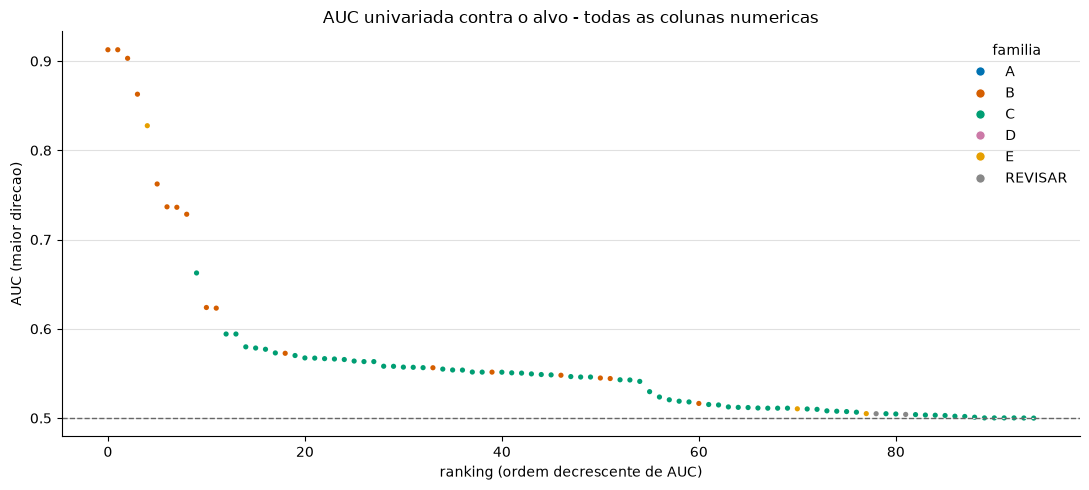

In [8]:
auc_plot_df = auc_df.dropna(subset=['auc_max_dir']).reset_index(drop=True)
colors = [FAMILY_COLOR.get(f, '#888888') for f in auc_plot_df['familia']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(range(len(auc_plot_df)), auc_plot_df['auc_max_dir'], c=colors, s=14, linewidths=0)
ax.axhline(0.5, color='#666666', linewidth=1, linestyle='--')
ax.set_xlabel('ranking (ordem decrescente de AUC)')
ax.set_ylabel('AUC (maior direcao)')
ax.set_title('AUC univariada contra o alvo - todas as colunas numericas')
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=7, label=f)
           for f, c in FAMILY_COLOR.items()]
ax.legend(handles=handles, title='familia', loc='upper right', frameon=False)
plt.tight_layout()
plt.show()


## Secao 3 - Nulos: diagnostico, sem corte arbitrario

Para toda coluna com pelo menos um nulo: %nulo, taxa de default entre linhas nulas vs.
preenchidas, e uma hipotese de mecanismo (uma frase). Nenhuma sugestao de tratamento.

In [9]:
def null_hypothesis(col):
    if col.startswith('hardship_') or col in ('deferral_term', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date'):
        return 'So existe para quem entrou em plano de hardship (evento raro, pos-originacao); nulo para os demais tomadores.'
    if col.startswith('settlement_') or col == 'debt_settlement_flag_date':
        return 'So existe para quem fez acordo de settlement apos charge-off; nulo para quem nao entrou em settlement.'
    if col.startswith('sec_app_') or col == 'revol_bal_joint':
        return 'So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.'
    if col in ('annual_inc_joint', 'dti_joint', 'verification_status_joint'):
        return 'So preenchido quando application_type = Joint App.'
    if col.startswith('mths_since_'):
        return 'Nulo quando o evento correspondente nunca ocorreu para o tomador (ex: nunca atrasou, nunca teve inquiry) ou o campo nao era coletado nas safras mais antigas.'
    if col in ('emp_title', 'emp_length', 'title', 'desc'):
        return 'Campo de preenchimento opcional pelo tomador na aplicacao; nulo quando ele nao informou.'
    if col == 'next_pymnt_d':
        return 'So existe enquanto o emprestimo esta ativo com parcela futura agendada; nao se aplica a emprestimos ja quitados ou baixados (populacao aqui e so Fully Paid / Charged Off).'
    if col in ('last_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low'):
        return 'Pequena fracao nula, provavelmente falha pontual de atualizacao do registro mais recente.'
    return 'LendingClub provavelmente passou a coletar/disponibilizar este atributo de bureau apenas a partir de determinado ano do dataset; nulo nas safras mais antigas (ver evidencia por ano abaixo).'

null_pct_all = pop_df.isnull().mean() * 100
null_cols = null_pct_all[null_pct_all > 0].sort_values(ascending=False)

rows3 = []
for col in null_cols.index:
    fam = family_map[col]
    pct_null = round(null_cols[col], 4)
    is_null_mask = pop_df[col].isnull()
    taxa_null = pop_df.loc[is_null_mask, 'target'].mean() * 100
    taxa_preenchido = pop_df.loc[~is_null_mask, 'target'].mean() * 100
    diff = taxa_null - taxa_preenchido
    hip = null_hypothesis(col)
    rows3.append({'nome': col, 'familia': fam, '%nulo': pct_null,
                  'default_nulo_%': round(taxa_null, 2), 'default_preenchido_%': round(taxa_preenchido, 2),
                  'diferenca_pp': round(diff, 2), 'hipotese_mecanismo': hip})

null_diag_df = pd.DataFrame(rows3)
print(f'Colunas com pelo menos um nulo: {len(null_diag_df)}')
null_diag_df


Colunas com pelo menos um nulo: 103


,nome,familia,%nulo,default_nulo_%,default_preenchido_%,diferenca_pp,hipotese_mecanismo
0,member_id,A,100.0000,14.81,NaN,NaN,LendingClub provavelmente passou a coletar/disponibilizar este atributo de bureau apenas a partir de determinado ano do dataset; nulo nas safras mais antigas (ver evidencia por ano abaixo).
1,next_pymnt_d,B,100.0000,14.81,NaN,NaN,So existe enquanto o emprestimo esta ativo com parcela futura agendada; nao se aplica a emprestimos ja quitados ou baixados (populacao aqui e so Fully Paid / Charged Off).
2,sec_app_mths_since_last_major_derog,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.
3,sec_app_mort_acc,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.
4,sec_app_open_acc,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.
5,sec_app_revol_util,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.
6,revol_bal_joint,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.
7,sec_app_num_rev_accts,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.
8,sec_app_chargeoff_within_12_mths,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.
9,sec_app_collections_12_mths_ex_med,C,100.0000,14.81,NaN,NaN,So se aplica a aplicacoes conjuntas (application_type = Joint App) com coborrower; nulo nas aplicacoes individuais.


### Evidencia: %nulo por ano de issue_d, para colunas com hipotese de 'passou a ser coletado em certo ano'

In [10]:
temporal_hyp_cols = [c for c in null_cols.index if null_hypothesis(c).startswith('LendingClub')]
print(f'Colunas com essa hipotese: {len(temporal_hyp_cols)}')

evidence_rows = []
for c in temporal_hyp_cols:
    by_year = pop_df.groupby('ano_emissao')[c].apply(lambda s: s.isnull().mean() * 100)
    evidence_rows.append(by_year.rename(c))

evidence_df = pd.concat(evidence_rows, axis=1).round(2) if evidence_rows else pd.DataFrame()
evidence_df


Colunas com essa hipotese: 52


,member_id,il_util,open_acc_6m,total_bal_il,open_rv_12m,open_il_12m,open_il_24m,all_util,inq_fi,open_act_il,max_bal_bc,total_cu_tl,inq_last_12m,open_rv_24m,mo_sin_old_il_acct,num_tl_120dpd_2m,pct_tl_nvr_dlq,avg_cur_bal,mo_sin_old_rev_tl_op,num_rev_accts,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,total_rev_hi_lim,tot_coll_amt,tot_cur_bal,num_accts_ever_120_pd,num_op_rev_tl,num_rev_tl_bal_gt_0,num_tl_30dpd,num_tl_90g_dpd_24m,tot_hi_cred_lim,num_tl_op_past_12m,total_il_high_credit_limit,num_bc_tl,num_actv_rev_tl,num_actv_bc_tl,num_il_tl,num_bc_sats,num_sats,bc_util,percent_bc_gt_75,bc_open_to_buy,acc_open_past_24mths,total_bal_ex_mort,mort_acc,total_bc_limit,pub_rec_bankruptcies,revol_util,chargeoff_within_12_mths,collections_12_mths_ex_med,tax_liens,dti
ano_emissao,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,97.21,0.00,22.31,22.31,15.54,0.0
2008,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,28.81,0.51,0.00,0.00,0.00,0.0
2009,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.06,0.30,0.00,0.00,0.00,0.0
2010,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.00,0.16,0.00,0.00,0.00,0.0
2011,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.00,0.04,0.00,0.00,0.00,0.0
2012,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,54.19,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,51.98,30.08,30.08,15.08,15.03,15.03,14.04,14.04,14.04,14.04,0.00,0.09,0.00,0.00,0.00,0.0
2013,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,3.68,0.19,0.11,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.79,0.75,0.75,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.0
2014,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,3.65,3.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.16,1.14,1.08,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.0
2015,100.0,95.47,94.74,94.74,94.74,94.74,94.74,94.74,94.74,94.74,94.74,94.74,94.74,94.74,3.52,5.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.07,1.09,1.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.0


## Secao 4 - Limpezas mecanicas (inequivocas, aplicadas e reportadas)

Estas transformacoes SAO aplicadas em `pop_df` (em memoria, para permitir as secoes 5 e 6),
mas nada e escrito em disco e nenhuma linha/coluna e removida.

### Datas para datetime real

In [11]:
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
             'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
             'debt_settlement_flag_date', 'settlement_date', 'sec_app_earliest_cr_line']

for c in date_cols:
    before_dtype = str(pop_df[c].dtype)
    pop_df[c] = pd.to_datetime(pop_df[c], format='%b-%Y', errors='coerce')
    print(f'{c}: {before_dtype} -> {pop_df[c].dtype}  (nulos: {pop_df[c].isnull().sum():,})')


issue_d: str -> datetime64[us]  (nulos: 0)
earliest_cr_line: str -> datetime64[us]  (nulos: 0)
last_pymnt_d: str -> datetime64[us]  (nulos: 514)


next_pymnt_d: object -> datetime64[s]  (nulos: 673,553)
last_credit_pull_d: str -> datetime64[us]  (nulos: 36)
hardship_start_date: str -> datetime64[us]  (nulos: 672,167)
hardship_end_date: str -> datetime64[us]  (nulos: 672,167)
payment_plan_start_date: str -> datetime64[us]  (nulos: 672,167)


debt_settlement_flag_date: str -> datetime64[us]  (nulos: 663,006)
settlement_date: str -> datetime64[us]  (nulos: 663,006)
sec_app_earliest_cr_line: object -> datetime64[s]  (nulos: 673,553)


### Percentuais e monetarias garantidas como float

In [12]:
percent_cols = ['int_rate', 'revol_util', 'dti', 'dti_joint', 'all_util', 'il_util', 'bc_util',
                'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'sec_app_revol_util']

monetary_cols = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'installment', 'annual_inc',
                  'annual_inc_joint', 'revol_bal', 'revol_bal_joint', 'out_prncp', 'out_prncp_inv',
                  'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
                  'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt',
                  'tot_coll_amt', 'tot_cur_bal', 'total_bal_il', 'max_bal_bc', 'total_rev_hi_lim',
                  'avg_cur_bal', 'bc_open_to_buy', 'delinq_amnt', 'tot_hi_cred_lim',
                  'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit',
                  'hardship_amount', 'orig_projected_additional_accrued_interest',
                  'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
                  'settlement_amount']

for c in percent_cols + monetary_cols:
    before_dtype = str(pop_df[c].dtype)
    before_nulls = int(pop_df[c].isnull().sum())
    pop_df[c] = pd.to_numeric(pop_df[c], errors='coerce')
    after_nulls = int(pop_df[c].isnull().sum())
    flag = '' if after_nulls == before_nulls else f'  <-- NOVOS NULOS: {after_nulls - before_nulls} (havia texto nao numerico)'
    print(f'{c}: {before_dtype} -> {pop_df[c].dtype} | nulos antes={before_nulls} depois={after_nulls}{flag}')


int_rate: float64 -> float64 | nulos antes=0 depois=0
revol_util: float64 -> float64 | nulos antes=378 depois=378
dti: float64 -> float64 | nulos antes=2 depois=2
dti_joint: float64 -> float64 | nulos antes=673315 depois=673315
all_util: float64 -> float64 | nulos antes=658669 depois=658669
il_util: float64 -> float64 | nulos antes=660736 depois=660736
bc_util: float64 -> float64 | nulos antes=53814 depois=53814
pct_tl_nvr_dlq: float64 -> float64 | nulos antes=67680 depois=67680
percent_bc_gt_75: float64 -> float64 | nulos antes=53758 depois=53758
sec_app_revol_util: float64 -> float64 | nulos antes=673553 depois=673553
loan_amnt: float64 -> float64 | nulos antes=0 depois=0
funded_amnt: float64 -> float64 | nulos antes=0 depois=0
funded_amnt_inv: float64 -> float64 | nulos antes=0 depois=0
installment: float64 -> float64 | nulos antes=0 depois=0
annual_inc: float64 -> float64 | nulos antes=0 depois=0
annual_inc_joint: float64 -> float64 | nulos antes=673314 depois=673314
revol_bal: flo

hardship_last_payment_amount: float64 -> float64 | nulos antes=672167 depois=672167
settlement_amount: float64 -> float64 | nulos antes=663006 depois=663006


### term e emp_length para numerico

In [13]:
print('term - valores originais unicos:', sorted(pop_df['term'].dropna().unique()))
pop_df['term_meses'] = pop_df['term'].str.strip().str.extract(r'(\d+)').astype(float)
print('term_meses - valores unicos apos conversao:', sorted(pop_df['term_meses'].dropna().unique()))

print()
print('emp_length - valores originais unicos:', sorted(pop_df['emp_length'].dropna().unique().tolist()))

def parse_emp_length(v):
    if pd.isna(v):
        return np.nan
    v = v.strip()
    if v == '< 1 year':
        return 0.0
    if v == '10+ years':
        return 10.0
    digits = ''.join(ch for ch in v if ch.isdigit())
    return float(digits) if digits else np.nan

pop_df['emp_length_anos'] = pop_df['emp_length'].apply(parse_emp_length)
print('emp_length_anos - valores unicos apos conversao:', sorted(pop_df['emp_length_anos'].dropna().unique()))
print()
print('Convencao aplicada: "< 1 year" -> 0; "n years"/"n year" -> n; "10+ years" -> 10; NaN mantido NaN.')


term - valores originais unicos: [' 36 months', ' 60 months']


term_meses - valores unicos apos conversao: [np.float64(36.0), np.float64(60.0)]

emp_length - valores originais unicos: ['1 year', '10+ years', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '< 1 year']


emp_length_anos - valores unicos apos conversao: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]

Convencao aplicada: "< 1 year" -> 0; "n years"/"n year" -> n; "10+ years" -> 10; NaN mantido NaN.


### Categoricas de baixa cardinalidade: strip + lower (com guarda de fusao de cardinalidade)

In [14]:
low_card_cols = ['grade', 'sub_grade', 'home_ownership', 'purpose', 'verification_status',
                  'addr_state', 'initial_list_status', 'application_type']

for c in low_card_cols:
    before_card = pop_df[c].nunique(dropna=True)
    candidate = pop_df[c].str.strip().str.lower()
    after_card = candidate.nunique(dropna=True)
    if after_card < before_card:
        before_vals = set(pop_df[c].dropna().unique())
        merged = {}
        for v in before_vals:
            key = v.strip().lower()
            merged.setdefault(key, []).append(v)
        merged_groups = {k: v for k, v in merged.items() if len(v) > 1}
        print(f'{c}: cardinalidade caiu de {before_card} para {after_card} -- APLICACAO CANCELADA PARA ESTA COLUNA.')
        print(f'  Valores que se fundiriam: {merged_groups}')
    else:
        pop_df[c] = candidate
        print(f'{c}: cardinalidade antes={before_card}, depois={after_card} (sem mudanca) -- strip/lower aplicado.')


grade: cardinalidade antes=7, depois=7 (sem mudanca) -- strip/lower aplicado.


sub_grade: cardinalidade antes=35, depois=35 (sem mudanca) -- strip/lower aplicado.


home_ownership: cardinalidade antes=6, depois=6 (sem mudanca) -- strip/lower aplicado.


purpose: cardinalidade antes=14, depois=14 (sem mudanca) -- strip/lower aplicado.
verification_status: cardinalidade antes=3, depois=3 (sem mudanca) -- strip/lower aplicado.


addr_state: cardinalidade antes=51, depois=51 (sem mudanca) -- strip/lower aplicado.
initial_list_status: cardinalidade antes=2, depois=2 (sem mudanca) -- strip/lower aplicado.


application_type: cardinalidade antes=2, depois=2 (sem mudanca) -- strip/lower aplicado.


### Duplicatas

In [15]:
dup_by_id = int(pop_df['id'].duplicated().sum())
print(f'Duplicatas por id: {dup_by_id} (esperado 0)')

proxy_cols = ['loan_amnt', 'issue_d', 'annual_inc', 'addr_state', 'purpose', 'emp_title']
dup_mask = pop_df.duplicated(subset=proxy_cols, keep=False)
n_dup_rows = int(dup_mask.sum())
n_extra_dup_rows = int(pop_df.duplicated(subset=proxy_cols, keep='first').sum())
print(f'Linhas envolvidas em duplicata por proxy (loan_amnt, issue_d, annual_inc, addr_state, purpose, emp_title): {n_dup_rows}')
print(f'Linhas "extras" alem da primeira ocorrencia de cada grupo: {n_extra_dup_rows}')


Duplicatas por id: 0 (esperado 0)


Linhas envolvidas em duplicata por proxy (loan_amnt, issue_d, annual_inc, addr_state, purpose, emp_title): 501
Linhas "extras" alem da primeira ocorrencia de cada grupo: 253


In [16]:
if n_dup_rows > 0:
    example_groups = pop_df.loc[dup_mask, proxy_cols].drop_duplicates().head(5)
    example_rows = pop_df.merge(example_groups, on=proxy_cols, how='inner')[['id'] + proxy_cols + ['loan_status']].sort_values(proxy_cols)
    display(example_rows)
else:
    print('Nenhuma duplicata por proxy encontrada.')


,id,loan_amnt,issue_d,annual_inc,addr_state,purpose,emp_title,loan_status
3,67829901,6000.0,2015-12-01,40000.0,ca,debt_consolidation,NaN,Fully Paid
9,65784792,6000.0,2015-12-01,40000.0,ca,debt_consolidation,NaN,Charged Off
1,68424247,10000.0,2015-12-01,25000.0,fl,debt_consolidation,NaN,Fully Paid
5,67318490,10000.0,2015-12-01,25000.0,fl,debt_consolidation,NaN,Fully Paid
2,68433830,10000.0,2015-12-01,35000.0,fl,credit_card,NaN,Charged Off
8,66260567,10000.0,2015-12-01,35000.0,fl,credit_card,NaN,Fully Paid
0,68525134,15000.0,2015-12-01,70000.0,ny,debt_consolidation,NaN,Fully Paid
7,66583689,15000.0,2015-12-01,70000.0,ny,debt_consolidation,NaN,Fully Paid
4,68292348,15000.0,2015-12-01,120000.0,ca,credit_card,Owner,Fully Paid
6,66623588,15000.0,2015-12-01,120000.0,ca,credit_card,Owner,Charged Off


## Secao 5 - Bancada de outliers (evidencia para decisao)

Colunas numericas continuas da familia C selecionadas por razao (maximo / percentil 99) > 3,
mais `annual_inc`, `dti` e `revol_util` (forcadas). "Continua" aqui = dtype numerico com mais
de 20 valores unicos (heuristica para excluir contadores/flags de baixa cardinalidade).

In [17]:
family_C_numeric = [c for c in family_C if pop_df[c].dtype in ['float64', 'int64']]
family_C_continuous = [c for c in family_C_numeric if pop_df[c].nunique(dropna=True) > 20]

print(f'Colunas numericas na familia C: {len(family_C_numeric)}')
print(f'Consideradas continuas (>20 valores unicos): {len(family_C_continuous)}')

ratio_rows = []
for c in family_C_continuous:
    s = pop_df[c].dropna()
    if len(s) == 0:
        continue
    p99 = s.quantile(0.99)
    mx = s.max()
    ratio = (mx / p99) if p99 not in (0, np.nan) else np.nan
    ratio_rows.append({'coluna': c, 'max': mx, 'p99': p99, 'razao_max_p99': ratio})

ratio_df = pd.DataFrame(ratio_rows).sort_values('razao_max_p99', ascending=False, na_position='last').reset_index(drop=True)
selected_by_criterion = ratio_df.loc[ratio_df['razao_max_p99'] > 3, 'coluna'].tolist()

forced = ['annual_inc', 'dti', 'revol_util']
outlier_bench_cols = list(dict.fromkeys(selected_by_criterion + [f for f in forced if f not in selected_by_criterion]))

print(f'Selecionadas pelo criterio (razao > 3): {len(selected_by_criterion)}')
print(f'Total na bancada (incluindo annual_inc/dti/revol_util forcadas): {len(outlier_bench_cols)}')
print(outlier_bench_cols)
ratio_df


Colunas numericas na familia C: 86
Consideradas continuas (>20 valores unicos): 61


Selecionadas pelo criterio (razao > 3): 33
Total na bancada (incluindo annual_inc/dti/revol_util forcadas): 33
['tot_coll_amt', 'tax_liens', 'total_rev_hi_lim', 'pub_rec', 'annual_inc', 'revol_bal', 'dti', 'num_tl_90g_dpd_24m', 'tot_hi_cred_lim', 'avg_cur_bal', 'total_bal_ex_mort', 'tot_cur_bal', 'total_il_high_credit_limit', 'revol_util', 'total_bc_limit', 'delinq_2yrs', 'bc_open_to_buy', 'mort_acc', 'num_accts_ever_120_pd', 'mo_sin_rcnt_tl', 'max_bal_bc', 'acc_open_past_24mths', 'mo_sin_rcnt_rev_tl_op', 'num_il_tl', 'total_bal_il', 'mths_since_recent_bc', 'num_bc_sats', 'open_rv_24m', 'num_tl_op_past_12m', 'bc_util', 'num_actv_rev_tl', 'open_acc', 'num_op_rev_tl']


,coluna,max,p99,razao_max_p99
0,tot_coll_amt,9152545.00,4655.5000,1965.963914
1,tax_liens,85.00,1.0000,85.000000
2,total_rev_hi_lim,9999999.00,149187.5000,67.029738
3,pub_rec,86.00,2.0000,43.000000
4,annual_inc,9000000.00,250000.0000,36.000000
5,revol_bal,2904836.00,88595.0000,32.787810
6,dti,999.00,36.8700,27.095199
7,num_tl_90g_dpd_24m,30.00,2.0000,15.000000
8,tot_hi_cred_lim,9999999.00,742973.5000,13.459429
9,avg_cur_bal,958084.00,71502.7200,13.399266


===== tot_coll_amt =====
count    6.060260e+05
mean     2.306804e+02
std      1.190795e+04
min      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      1.660000e+02
95%      6.490000e+02
99%      4.655500e+03
99.9%    2.356362e+04
max      9.152545e+06
Name: tot_coll_amt, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 23549.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


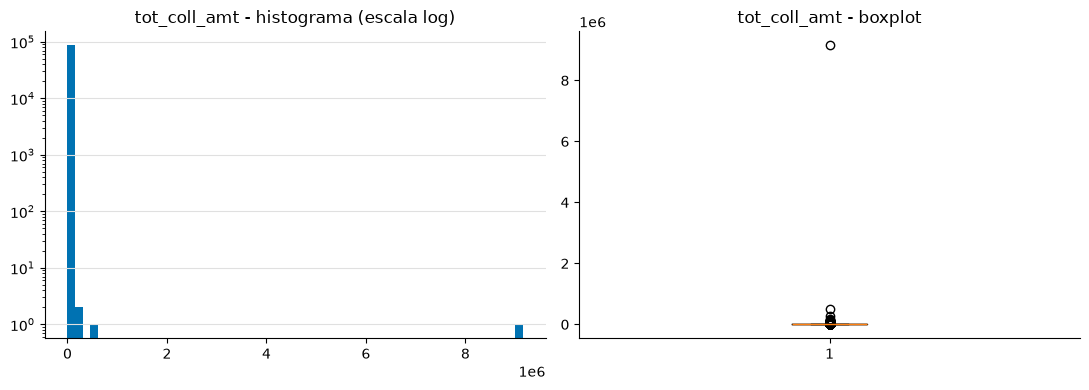

30 maiores valores:


,tot_coll_amt,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
410231,9152545.0,Attorney,1 year,mortgage,c,10800.0,122000.0,9.10,verified,2014-04-01,Fully Paid
252919,496651.0,Office clerk,3 years,rent,c,10000.0,43000.0,15.80,source verified,2015-02-01,Fully Paid
87042,262740.0,Data Analyst,7 years,rent,c,7000.0,59200.0,17.01,source verified,2015-10-01,Fully Paid
28277,169257.0,Sr. Test Engineering Tech,3 years,mortgage,d,6600.0,54000.0,5.24,not verified,2015-11-01,Fully Paid
211396,143558.0,Professor,4 years,rent,c,10000.0,65000.0,19.83,source verified,2015-04-01,Fully Paid
9515,140842.0,Sr Recruiter,5 years,rent,b,2400.0,180000.0,5.49,verified,2015-12-01,Fully Paid
288850,124825.0,Budget Analysts,10+ years,mortgage,c,7000.0,118040.0,10.58,source verified,2014-11-01,Fully Paid
48258,119942.0,NaN,NaN,rent,b,3000.0,27276.0,23.85,verified,2015-11-01,Charged Off
190619,119428.0,Crew,3 years,rent,b,4000.0,80000.0,7.22,not verified,2015-05-01,Fully Paid
301051,119428.0,Crew,2 years,rent,b,5925.0,80000.0,6.02,not verified,2014-11-01,Fully Paid


Zeros exatos: 518,956
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
tot_coll_amt
50.0     1320
100.0    1037
75.0      796
150.0     528
200.0     518
60.0      516
Name: count, dtype: int64

===== tax_liens =====
count    673514.000000
mean          0.047209
std           0.397709
min           0.000000
50%           0.000000
75%           0.000000
90%           0.000000
95%           0.000000
99%           1.000000
99.9%         5.000000
max          85.000000
Name: tax_liens, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 4.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


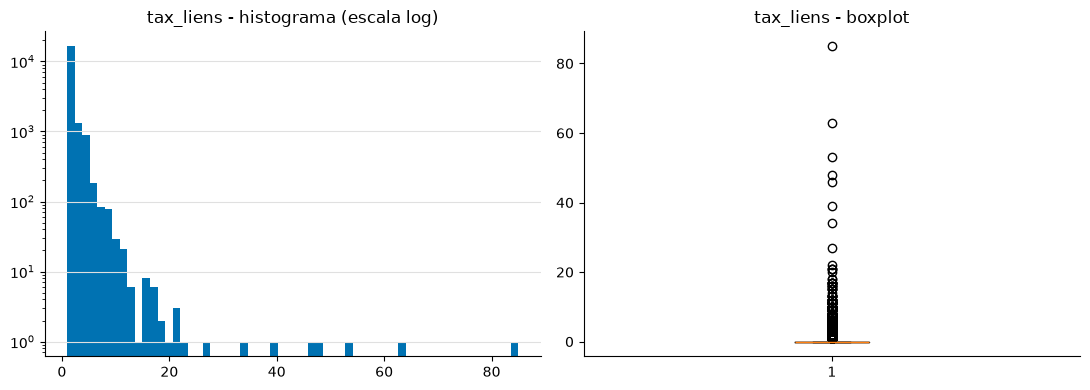

30 maiores valores:


,tax_liens,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
46502,85.0,Teacher,1 year,mortgage,c,6400.0,38000.0,32.41,verified,2015-11-01,Charged Off
423743,63.0,Warranty MGR,9 years,own,b,8000.0,37000.0,3.57,source verified,2014-02-01,Fully Paid
575684,53.0,RE/MAX Preferred,3 years,rent,c,10000.0,38750.0,21.99,source verified,2013-06-01,Fully Paid
514637,48.0,senior manager,2 years,own,b,7125.0,40000.0,14.19,verified,2013-10-01,Fully Paid
212625,46.0,Director-Commercial Segments-NTL Accts,1 year,rent,c,4450.0,126000.0,8.57,not verified,2015-04-01,Fully Paid
411519,39.0,Realtor,4 years,rent,f,5950.0,31000.0,33.60,verified,2014-04-01,Charged Off
439434,34.0,Asst. Superintendent,10+ years,rent,c,10000.0,50000.0,28.25,verified,2014-01-01,Fully Paid
39505,27.0,general manager,< 1 year,own,b,7000.0,45000.0,34.37,not verified,2015-11-01,Fully Paid
6392,22.0,Sales,4 years,rent,c,12000.0,60000.0,14.12,source verified,2015-12-01,Fully Paid
66423,21.0,Agent,10+ years,mortgage,c,32325.0,500000.0,7.34,source verified,2015-10-01,Fully Paid


Zeros exatos: 654,295
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
tax_liens
1.0    12959
2.0     3595
3.0     1329
4.0      591
5.0      312
6.0      186
Name: count, dtype: int64

===== total_rev_hi_lim =====
count    6.060260e+05
mean     3.068339e+04
std      3.871140e+04
min      0.000000e+00
50%      2.230000e+04
75%      3.780000e+04
90%      6.030000e+04
95%      8.080000e+04
99%      1.491875e+05
99.9%    3.305000e+05
max      9.999999e+06
Name: total_rev_hi_lim, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 330400.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


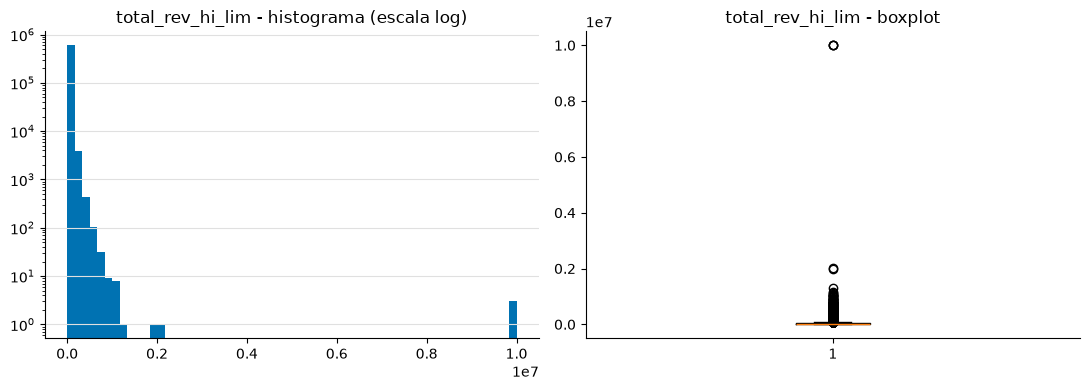

30 maiores valores:


,total_rev_hi_lim,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
194923,9999999.0,CEO,10+ years,own,d,35000.0,400000.0,24.83,verified,2015-06-01,Fully Paid
330829,9999999.0,Executive,3 years,mortgage,a,26200.0,999999.0,13.30,verified,2014-10-01,Fully Paid
572853,9999999.0,Jennison Associates,1 year,mortgage,a,28000.0,1000000.0,12.54,verified,2013-06-01,Fully Paid
621157,2013133.0,plastic surgery,10+ years,mortgage,b,35000.0,400000.0,33.48,verified,2013-01-01,Fully Paid
503422,1998700.0,NaN,10+ years,mortgage,c,35000.0,400000.0,32.80,verified,2013-11-01,Charged Off
395190,1314900.0,President,10+ years,mortgage,c,31500.0,275000.0,9.84,verified,2014-05-01,Fully Paid
105795,1165700.0,Chairman,10+ years,mortgage,a,30000.0,650000.0,15.05,source verified,2015-09-01,Fully Paid
384046,1127900.0,Partner,10+ years,mortgage,a,28000.0,250000.0,18.45,source verified,2014-06-01,Fully Paid
149468,1094550.0,VP Marketing,< 1 year,own,c,35000.0,265000.0,16.29,source verified,2015-07-01,Charged Off
441418,1060800.0,NaN,10+ years,own,e,35000.0,920000.0,8.65,verified,2014-01-01,Charged Off


Zeros exatos: 224
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
total_rev_hi_lim
10000.0    2128
12000.0    2083
13500.0    2046
11000.0    2041
15000.0    2028
13000.0    2021
Name: count, dtype: int64

===== pub_rec =====
count    673553.000000
mean          0.195619
std           0.589954
min           0.000000
50%           0.000000
75%           0.000000
90%           1.000000
95%           1.000000
99%           2.000000
99.9%         5.000000
max          86.000000
Name: pub_rec, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 4.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


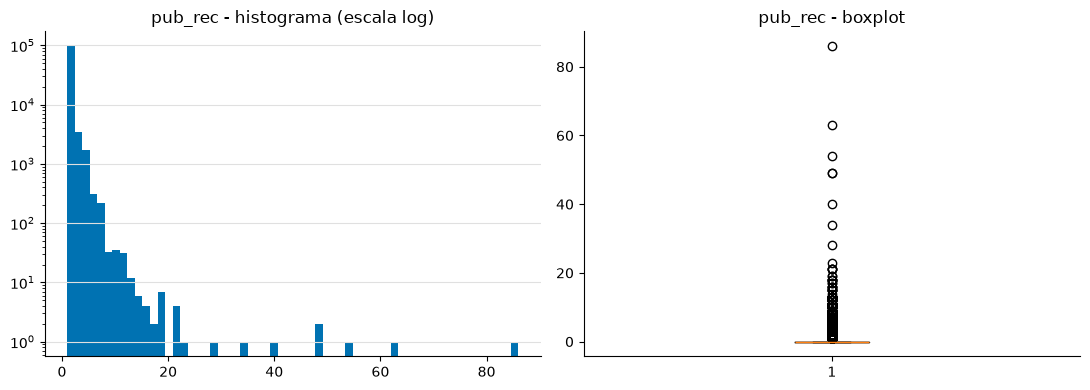

30 maiores valores:


,pub_rec,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
46502,86.0,Teacher,1 year,mortgage,c,6400.0,38000.0,32.41,verified,2015-11-01,Charged Off
423743,63.0,Warranty MGR,9 years,own,b,8000.0,37000.0,3.57,source verified,2014-02-01,Fully Paid
575684,54.0,RE/MAX Preferred,3 years,rent,c,10000.0,38750.0,21.99,source verified,2013-06-01,Fully Paid
212625,49.0,Director-Commercial Segments-NTL Accts,1 year,rent,c,4450.0,126000.0,8.57,not verified,2015-04-01,Fully Paid
514637,49.0,senior manager,2 years,own,b,7125.0,40000.0,14.19,verified,2013-10-01,Fully Paid
411519,40.0,Realtor,4 years,rent,f,5950.0,31000.0,33.60,verified,2014-04-01,Charged Off
439434,34.0,Asst. Superintendent,10+ years,rent,c,10000.0,50000.0,28.25,verified,2014-01-01,Fully Paid
39505,28.0,general manager,< 1 year,own,b,7000.0,45000.0,34.37,not verified,2015-11-01,Fully Paid
6392,23.0,Sales,4 years,rent,c,12000.0,60000.0,14.12,source verified,2015-12-01,Fully Paid
66423,21.0,Agent,10+ years,mortgage,c,32325.0,500000.0,7.34,source verified,2015-10-01,Fully Paid


Zeros exatos: 570,351
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
pub_rec
1.0    86247
2.0    11121
3.0     3414
4.0     1172
5.0      577
6.0      305
Name: count, dtype: int64

===== annual_inc =====
count    6.735530e+05
mean     7.306678e+04
std      6.508767e+04
min      0.000000e+00
50%      6.100000e+04
75%      8.800000e+04
90%      1.200000e+05
95%      1.500000e+05
99%      2.500000e+05
99.9%    5.500000e+05
max      9.000000e+06
Name: annual_inc, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 547000.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


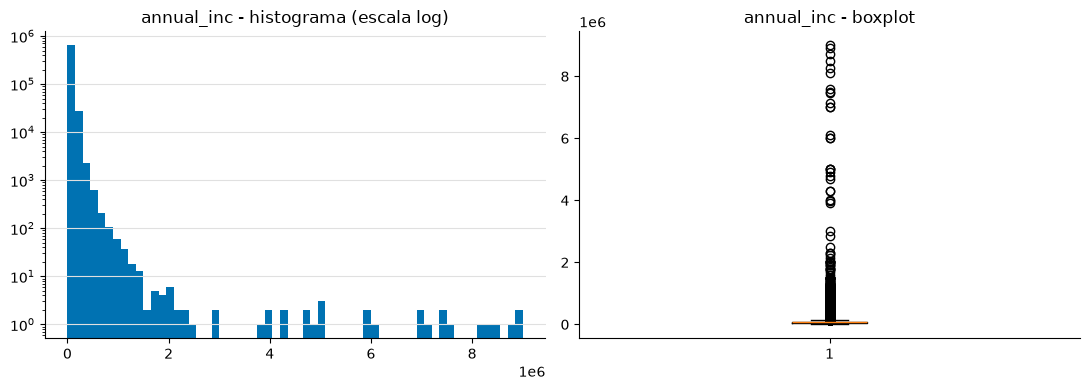

30 maiores valores:


,annual_inc,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
27579,9000000.0,registered nurse,10+ years,mortgage,a,11000.0,9000000.0,0.08,source verified,2015-12-01,Fully Paid
146455,8900060.0,commercial driver,10+ years,rent,d,10550.0,8900060.0,0.09,source verified,2015-07-01,Charged Off
269167,8706582.0,Correctional Sgt.,10+ years,mortgage,c,8000.0,8706582.0,0.11,source verified,2015-01-01,Charged Off
32738,8500021.0,Senior Field Operator,10+ years,mortgage,b,12000.0,8500021.0,0.22,source verified,2015-11-01,Fully Paid
58131,8253000.0,Sr Mgr,10+ years,own,c,30000.0,8253000.0,0.14,source verified,2015-11-01,Fully Paid
87240,8121180.0,Facilities Operations Manager,10+ years,mortgage,b,5000.0,8121180.0,0.48,source verified,2015-10-01,Fully Paid
90133,7600000.0,Interim Director of Case Management,3 years,mortgage,a,10000.0,7600000.0,0.09,source verified,2015-09-01,Fully Paid
347412,7500000.0,Sales & service rep,10+ years,mortgage,e,15000.0,7500000.0,0.20,verified,2014-08-01,Charged Off
435114,7446395.0,Registered Nurse,5 years,rent,a,20000.0,7446395.0,0.13,source verified,2014-02-01,Fully Paid
620078,7141778.0,Us postal service,10+ years,mortgage,b,14825.0,7141778.0,0.25,source verified,2012-12-01,Fully Paid


Zeros exatos: 2
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
annual_inc
60000.0    25695
50000.0    23520
40000.0    19437
65000.0    18802
45000.0    17940
70000.0    17641
Name: count, dtype: int64

===== revol_bal =====
count    6.735530e+05
mean     1.580951e+04
std      2.156215e+04
min      0.000000e+00
50%      1.096500e+04
75%      1.932100e+04
90%      3.146700e+04
95%      4.150180e+04
99%      8.859500e+04
99.9%    2.535243e+05
max      2.904836e+06
Name: revol_bal, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 253458.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


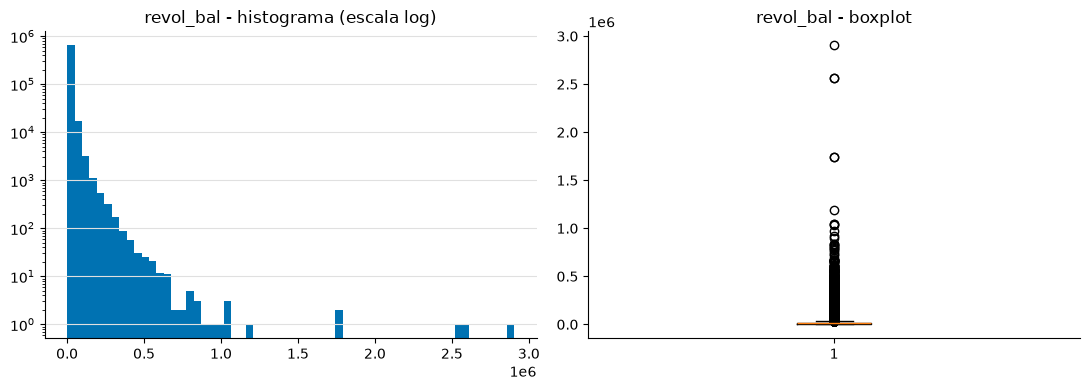

30 maiores valores:


,revol_bal,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
194923,2904836.0,CEO,10+ years,own,d,35000.0,400000.0,24.83,verified,2015-06-01,Fully Paid
572853,2568995.0,Jennison Associates,1 year,mortgage,a,28000.0,1000000.0,12.54,verified,2013-06-01,Fully Paid
330829,2560703.0,Executive,3 years,mortgage,a,26200.0,999999.0,13.30,verified,2014-10-01,Fully Paid
503422,1746716.0,NaN,10+ years,mortgage,c,35000.0,400000.0,32.80,verified,2013-11-01,Charged Off
621157,1743266.0,plastic surgery,10+ years,mortgage,b,35000.0,400000.0,33.48,verified,2013-01-01,Fully Paid
395190,1190046.0,President,10+ years,mortgage,c,31500.0,275000.0,9.84,verified,2014-05-01,Fully Paid
246783,1043860.0,President,10+ years,mortgage,a,28000.0,350000.0,18.25,source verified,2015-02-01,Fully Paid
149468,1039903.0,VP Marketing,< 1 year,own,c,35000.0,265000.0,16.29,source verified,2015-07-01,Charged Off
441418,1030826.0,NaN,10+ years,own,e,35000.0,920000.0,8.65,verified,2014-01-01,Charged Off
622976,975800.0,VISIUM asset management,10+ years,mortgage,c,35000.0,5000000.0,2.36,verified,2012-12-01,Fully Paid


Zeros exatos: 2,807
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
revol_bal
5235.0    59
5886.0    58
5849.0    58
6969.0    58
6223.0    57
4578.0    56
Name: count, dtype: int64

===== dti =====
count    673551.000000
mean         17.552341
std           8.309173
min           0.000000
50%          17.060000
75%          23.260000
90%          28.810000
95%          31.920000
99%          36.870000
99.9%        39.630000
max         999.000000
Name: dti, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 39.62


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


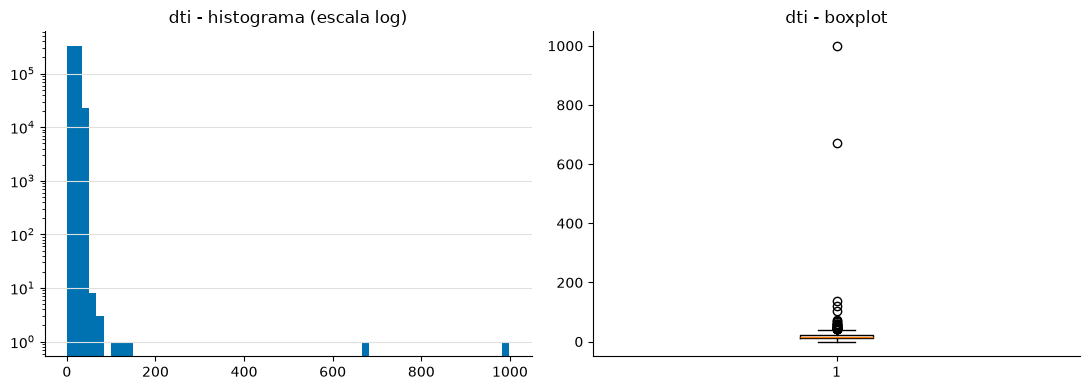

30 maiores valores:


,dti,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
6094,999.00,NaN,NaN,mortgage,d,6550.0,1770.00,999.00,not verified,2015-12-01,Fully Paid
50008,672.52,NaN,NaN,rent,e,12000.0,1200.00,672.52,verified,2015-11-01,Fully Paid
7408,137.40,NaN,NaN,mortgage,d,15000.0,20000.00,137.40,source verified,2015-12-01,Fully Paid
37878,120.66,NaN,NaN,mortgage,d,15000.0,8700.00,120.66,source verified,2015-12-01,Fully Paid
66098,104.00,Instructional Aide,5 years,mortgage,c,5000.0,12000.00,104.00,verified,2015-10-01,Fully Paid
60412,71.40,NaN,NaN,mortgage,c,17000.0,16404.00,71.40,verified,2015-10-01,Fully Paid
36070,69.35,Hair stylist,6 years,rent,c,8000.0,28000.00,69.35,verified,2015-11-01,Fully Paid
38899,67.50,NaN,NaN,rent,e,7000.0,12000.00,67.50,not verified,2015-11-01,Charged Off
38824,61.21,photo tech,8 years,mortgage,c,5000.0,25000.00,61.21,verified,2015-11-01,Charged Off
58173,60.08,NaN,NaN,mortgage,d,24000.0,20000.00,60.08,verified,2015-10-01,Fully Paid


Zeros exatos: 387
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
dti
14.4    551
19.2    543
18.0    513
16.8    504
13.2    502
15.6    493
Name: count, dtype: int64

===== num_tl_90g_dpd_24m =====
count    606026.000000
mean          0.090298
std           0.494370
min           0.000000
50%           0.000000
75%           0.000000
90%           0.000000
95%           1.000000
99%           2.000000
99.9%         6.000000
max          30.000000
Name: num_tl_90g_dpd_24m, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 5.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


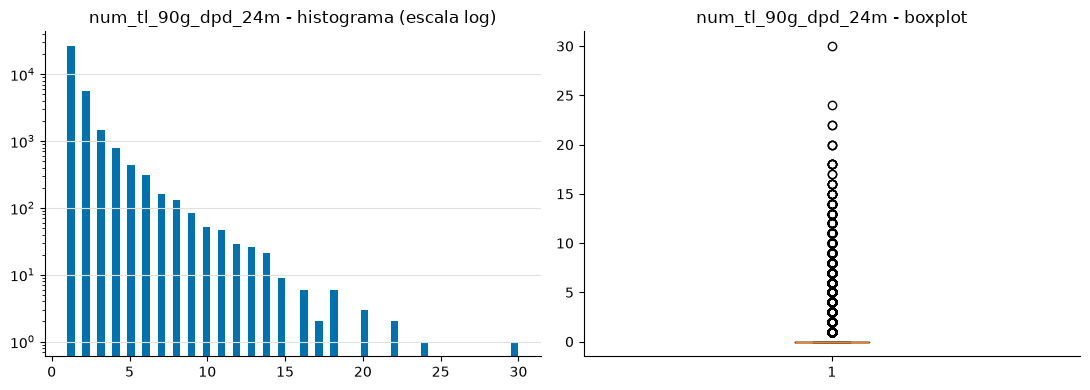

30 maiores valores:


,num_tl_90g_dpd_24m,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
39471,30.0,physician,< 1 year,rent,c,15000.0,140000.0,10.23,source verified,2015-11-01,Fully Paid
601716,24.0,Sparrow Hospital,5 years,rent,b,24000.0,98000.0,18.16,source verified,2013-03-01,Fully Paid
300436,22.0,Research Analyst,2 years,rent,c,4000.0,50155.0,12.28,not verified,2014-11-01,Fully Paid
437411,22.0,service manager,10+ years,mortgage,c,10000.0,85000.0,18.52,not verified,2014-01-01,Fully Paid
242433,20.0,Service Technician,< 1 year,rent,b,12000.0,65000.0,12.89,source verified,2015-03-01,Charged Off
290528,20.0,Patient Financial Counselor II,2 years,rent,c,3500.0,32646.0,26.36,not verified,2014-11-01,Fully Paid
579057,20.0,Zimmer Gunsul Frasca,1 year,rent,c,2500.0,51500.0,10.16,not verified,2013-05-01,Fully Paid
197989,18.0,Customer Service Representative,10+ years,rent,b,10000.0,35000.0,19.89,not verified,2015-05-01,Fully Paid
224981,18.0,CUSTOMER SERVICE,3 years,rent,d,2875.0,30000.0,16.72,verified,2015-04-01,Fully Paid
268799,18.0,Federal Law Enforcement Officer,2 years,own,c,12500.0,72500.0,12.40,not verified,2015-01-01,Fully Paid


Zeros exatos: 570,413
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
num_tl_90g_dpd_24m
1.0    26413
2.0     5611
3.0     1470
4.0      794
5.0      432
6.0      314
Name: count, dtype: int64

===== tot_hi_cred_lim =====
count    6.060260e+05
mean     1.613309e+05
std      1.725867e+05
min      0.000000e+00
50%      9.692150e+04
75%      2.332088e+05
90%      3.735225e+05
95%      4.760192e+05
99%      7.429735e+05
99.9%    1.358158e+06
max      9.999999e+06
Name: tot_hi_cred_lim, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 1356684.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


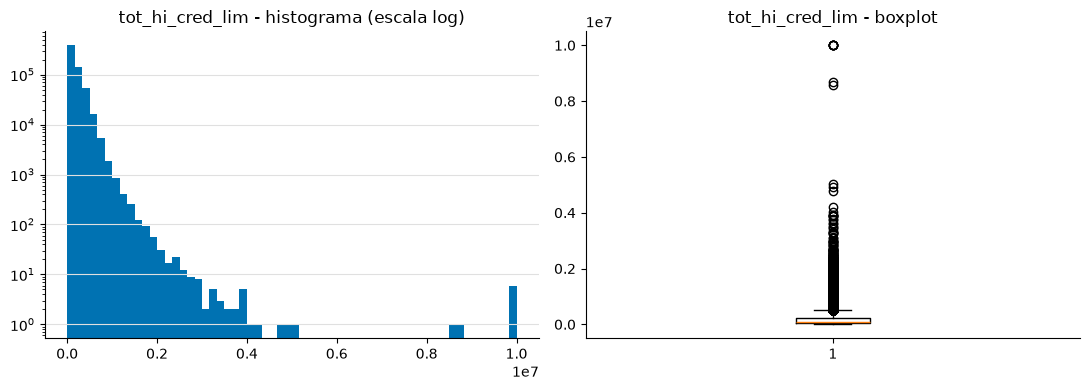

30 maiores valores:


,tot_hi_cred_lim,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
55811,9999999.0,NaN,NaN,mortgage,c,5125.0,50000.0,3.36,verified,2015-10-01,Charged Off
194923,9999999.0,CEO,10+ years,own,d,35000.0,400000.0,24.83,verified,2015-06-01,Fully Paid
210365,9999999.0,Food & Beverage Director,4 years,mortgage,a,10000.0,75000.0,15.02,not verified,2015-04-01,Fully Paid
330829,9999999.0,Executive,3 years,mortgage,a,26200.0,999999.0,13.30,verified,2014-10-01,Fully Paid
335669,9999999.0,owner,10+ years,mortgage,e,34000.0,80000.0,17.72,verified,2014-09-01,Fully Paid
572853,9999999.0,Jennison Associates,1 year,mortgage,a,28000.0,1000000.0,12.54,verified,2013-06-01,Fully Paid
160800,8700253.0,teacher,10+ years,mortgage,a,6000.0,93000.0,11.30,source verified,2015-07-01,Fully Paid
622976,8592561.0,VISIUM asset management,10+ years,mortgage,c,35000.0,5000000.0,2.36,verified,2012-12-01,Fully Paid
285603,5022617.0,Partner,10+ years,mortgage,c,35000.0,1100000.0,31.39,verified,2014-12-01,Fully Paid
620823,4932524.0,Standard Chartered Bank,2 years,mortgage,c,35000.0,800000.0,4.12,source verified,2013-01-01,Fully Paid


Zeros exatos: 11
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
tot_hi_cred_lim
17500.0    246
12500.0    241
15500.0    232
16500.0    226
13500.0    225
13800.0    223
Name: count, dtype: int64

===== avg_cur_bal =====
count    606015.000000
mean      12750.183611
std       15958.074897
min           0.000000
50%        6557.000000
75%       17649.000000
90%       31022.000000
95%       41563.000000
99%       71502.720000
99.9%    140200.566000
max      958084.000000
Name: avg_cur_bal, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 140170.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


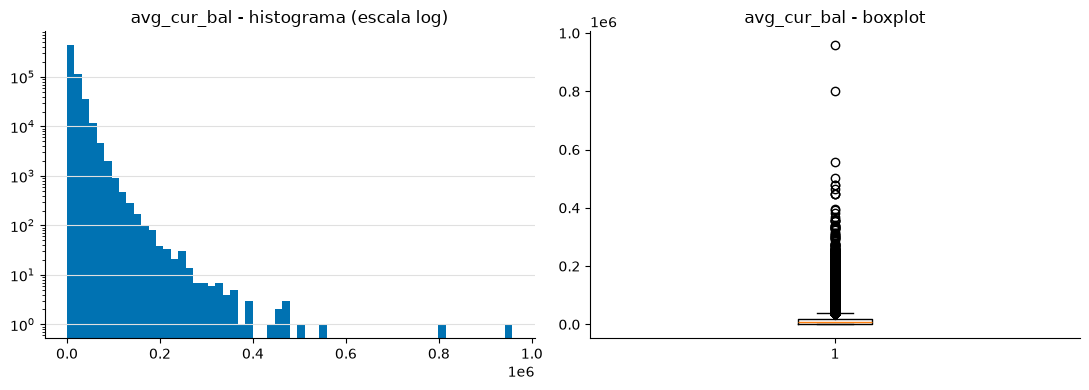

30 maiores valores:


,avg_cur_bal,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
608351,958084.0,The Sage Group,< 1 year,mortgage,b,16000.0,150000.0,13.17,source verified,2013-02-01,Fully Paid
622976,800008.0,VISIUM asset management,10+ years,mortgage,c,35000.0,5000000.0,2.36,verified,2012-12-01,Fully Paid
194923,555925.0,CEO,10+ years,own,d,35000.0,400000.0,24.83,verified,2015-06-01,Fully Paid
640833,502002.0,Highbridge Capital,5 years,mortgage,b,35000.0,1200000.0,0.35,source verified,2012-09-01,Fully Paid
69914,478909.0,Owner,10+ years,mortgage,c,35000.0,240000.0,2.15,verified,2015-10-01,Fully Paid
620823,477255.0,Standard Chartered Bank,2 years,mortgage,c,35000.0,800000.0,4.12,source verified,2013-01-01,Fully Paid
384115,463945.0,Partner,10+ years,mortgage,b,8000.0,265000.0,2.28,verified,2014-06-01,Fully Paid
334259,447433.0,landlord,10+ years,mortgage,b,6000.0,72604.0,1.50,source verified,2014-10-01,Fully Paid
285603,447378.0,Partner,10+ years,mortgage,c,35000.0,1100000.0,31.39,verified,2014-12-01,Fully Paid
350013,446720.0,ceo,< 1 year,mortgage,a,24000.0,200000.0,0.87,source verified,2014-08-01,Fully Paid


Zeros exatos: 93
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
avg_cur_bal
1971.0    109
2289.0     95
1843.0     95
2112.0     94
2587.0     93
1839.0     93
Name: count, dtype: int64

===== total_bal_ex_mort =====
count    6.262720e+05
mean     4.593092e+04
std      4.513258e+04
min      0.000000e+00
50%      3.429800e+04
75%      5.745925e+04
90%      9.161600e+04
95%      1.233029e+05
99%      2.226434e+05
99.9%    4.113645e+05
max      2.921551e+06
Name: total_bal_ex_mort, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 411285.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


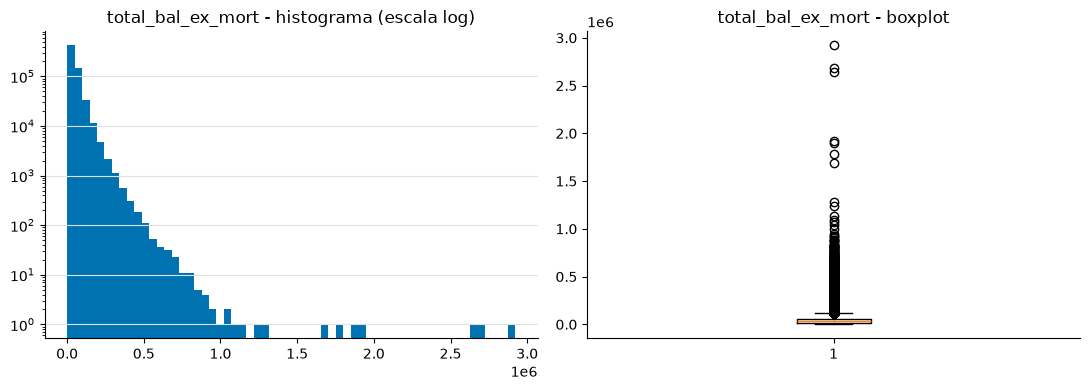

30 maiores valores:


,total_bal_ex_mort,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
194923,2921551.0,CEO,10+ years,own,d,35000.0,400000.0,24.83,verified,2015-06-01,Fully Paid
330829,2688920.0,Executive,3 years,mortgage,a,26200.0,999999.0,13.30,verified,2014-10-01,Fully Paid
572853,2644442.0,Jennison Associates,1 year,mortgage,a,28000.0,1000000.0,12.54,verified,2013-06-01,Fully Paid
621157,1924200.0,plastic surgery,10+ years,mortgage,b,35000.0,400000.0,33.48,verified,2013-01-01,Fully Paid
503422,1896461.0,NaN,10+ years,mortgage,c,35000.0,400000.0,32.80,verified,2013-11-01,Charged Off
361784,1783254.0,Managing Director,4 years,mortgage,a,28000.0,1600000.0,12.25,source verified,2014-07-01,Fully Paid
51215,1684313.0,Senior Vice President Trading,10+ years,rent,a,20000.0,1100000.0,18.64,source verified,2015-11-01,Fully Paid
542641,1276247.0,Adobe Systems,6 years,mortgage,d,35000.0,475000.0,22.35,verified,2013-08-01,Fully Paid
395190,1241779.0,President,10+ years,mortgage,c,31500.0,275000.0,9.84,verified,2014-05-01,Fully Paid
141777,1132745.0,owner,10+ years,mortgage,b,20000.0,1000000.0,14.44,source verified,2015-07-01,Fully Paid


Zeros exatos: 211
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
total_bal_ex_mort
19998.0    28
19217.0    26
27316.0    25
16219.0    24
12066.0    24
22396.0    24
Name: count, dtype: int64

===== tot_cur_bal =====
count    6.060260e+05
mean     1.308767e+05
std      1.521813e+05
min      0.000000e+00
50%      6.792400e+04
75%      1.949910e+05
90%      3.224170e+05
95%      4.149508e+05
99%      6.530798e+05
99.9%    1.204087e+06
max      8.000078e+06
Name: tot_cur_bal, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 1203991.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


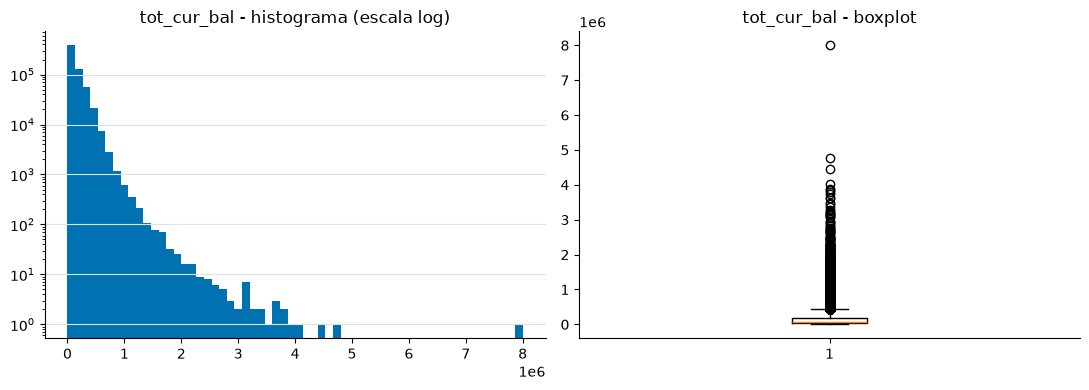

30 maiores valores:


,tot_cur_bal,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
622976,8000078.0,VISIUM asset management,10+ years,mortgage,c,35000.0,5000000.0,2.36,verified,2012-12-01,Fully Paid
620823,4772549.0,Standard Chartered Bank,2 years,mortgage,c,35000.0,800000.0,4.12,source verified,2013-01-01,Fully Paid
194923,4447397.0,CEO,10+ years,own,d,35000.0,400000.0,24.83,verified,2015-06-01,Fully Paid
285603,4026405.0,Partner,10+ years,mortgage,c,35000.0,1100000.0,31.39,verified,2014-12-01,Fully Paid
572853,3881449.0,Jennison Associates,1 year,mortgage,a,28000.0,1000000.0,12.54,verified,2013-06-01,Fully Paid
330829,3840795.0,Executive,3 years,mortgage,a,26200.0,999999.0,13.30,verified,2014-10-01,Fully Paid
297469,3796811.0,Vice President,10+ years,mortgage,d,24450.0,648000.0,11.31,verified,2014-11-01,Fully Paid
122625,3726495.0,Chief Medical Officer,2 years,mortgage,c,35000.0,650000.0,21.44,verified,2015-08-01,Fully Paid
284114,3610743.0,Principal,< 1 year,mortgage,c,18700.0,200000.0,21.28,not verified,2014-12-01,Fully Paid
32254,3608951.0,VP and International Tax Counsel,10+ years,mortgage,c,35000.0,700000.0,17.95,verified,2015-11-01,Fully Paid


Zeros exatos: 103
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
tot_cur_bal
19998.0    20
5537.0     19
27316.0    19
12066.0    18
22396.0    18
14511.0    18
Name: count, dtype: int64

===== total_il_high_credit_limit =====
count    6.060260e+05
mean     3.812707e+04
std      4.084781e+04
min      0.000000e+00
50%      2.833900e+04
75%      5.128600e+04
90%      8.310200e+04
95%      1.107140e+05
99%      1.936185e+05
99.9%    3.474581e+05
max      2.101913e+06
Name: total_il_high_credit_limit, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 347345.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


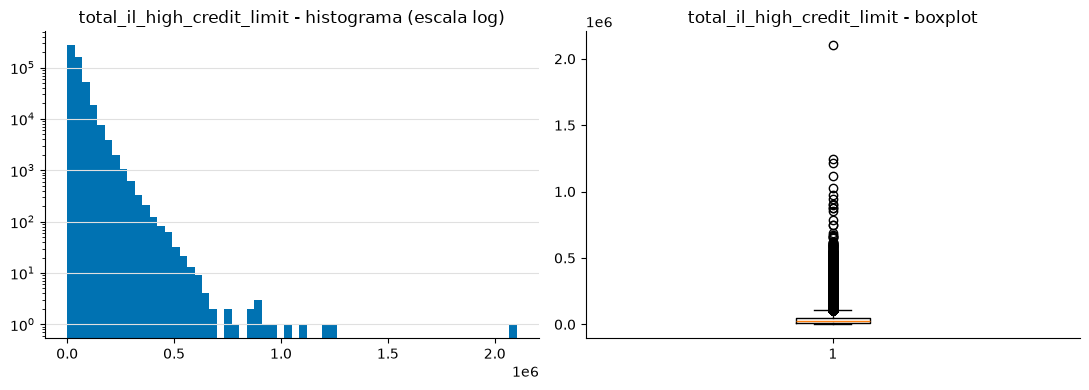

30 maiores valores:


,total_il_high_credit_limit,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
51215,2101913.0,Senior Vice President Trading,10+ years,rent,a,20000.0,1100000.0,18.64,source verified,2015-11-01,Fully Paid
361784,1241783.0,Managing Director,4 years,mortgage,a,28000.0,1600000.0,12.25,source verified,2014-07-01,Fully Paid
542641,1214546.0,Adobe Systems,6 years,mortgage,d,35000.0,475000.0,22.35,verified,2013-08-01,Fully Paid
141777,1119204.0,owner,10+ years,mortgage,b,20000.0,1000000.0,14.44,source verified,2015-07-01,Fully Paid
431878,1027358.0,NaN,10+ years,mortgage,a,21000.0,383000.0,33.45,verified,2014-02-01,Fully Paid
27624,975560.0,NaN,NaN,mortgage,c,25575.0,1473000.0,22.81,verified,2015-12-01,Fully Paid
143538,943608.0,Physician and President,10+ years,mortgage,d,30000.0,520000.0,27.37,verified,2015-07-01,Fully Paid
279267,905292.0,Owner,10+ years,mortgage,d,22000.0,250000.0,37.05,verified,2015-01-01,Fully Paid
643251,902504.0,"Citigroup, Inc",10+ years,mortgage,d,18000.0,840000.0,17.76,verified,2012-09-01,Fully Paid
314220,876963.0,General Manager,5 years,mortgage,a,14000.0,600000.0,15.41,verified,2014-10-01,Fully Paid


Zeros exatos: 87,580
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
total_il_high_credit_limit
10000.0    3037
15000.0    2237
5000.0     1988
20000.0    1736
25000.0    1330
12000.0    1304
Name: count, dtype: int64

===== revol_util =====
count    673175.000000
mean         54.207498
std          23.936340
min           0.000000
50%          55.000000
75%          72.800000
90%          86.200000
95%          92.100000
99%          98.200000
99.9%       102.500000
max         892.300000
Name: revol_util, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 102.4


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


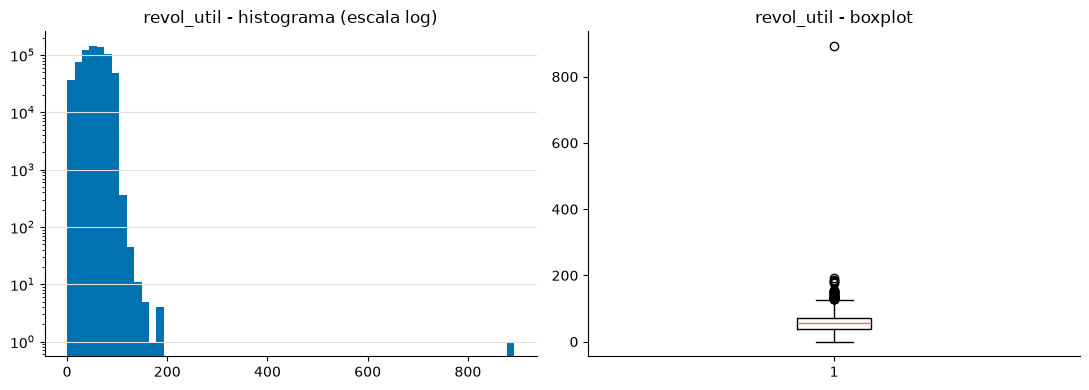

30 maiores valores:


,revol_util,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
402910,892.3,Budget Analyst,10+ years,rent,b,3500.0,45000.0,14.67,verified,2014-04-01,Fully Paid
138032,193.0,Financial Advisor,9 years,mortgage,d,35000.0,175000.0,5.18,source verified,2015-07-01,Fully Paid
278573,184.6,Founder,6 years,mortgage,c,28000.0,200000.0,15.61,source verified,2015-01-01,Fully Paid
73457,182.8,Branch Coordinator,10+ years,rent,c,12000.0,120000.0,16.25,source verified,2015-10-01,Charged Off
326989,180.3,NaN,NaN,rent,c,16000.0,95000.0,4.18,source verified,2014-10-01,Charged Off
343698,177.7,Director Omni Channel,10+ years,rent,d,15000.0,130000.0,11.00,verified,2014-08-01,Fully Paid
240520,155.3,Sr. Manager Consultant,1 year,rent,b,7000.0,145000.0,14.19,source verified,2015-03-01,Fully Paid
243432,153.7,Executive Secretary,8 years,rent,b,12000.0,52000.0,19.96,source verified,2015-02-01,Fully Paid
414680,153.0,HR Director,10+ years,rent,g,35000.0,165800.0,7.42,verified,2014-03-01,Fully Paid
419135,152.7,Fleet Manager,5 years,mortgage,c,19500.0,103000.0,12.99,source verified,2014-03-01,Fully Paid


Zeros exatos: 2,947
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
revol_util
53.0    1371
58.0    1362
62.0    1323
59.0    1321
57.0    1316
61.0    1316
Name: count, dtype: int64

===== total_bc_limit =====
count    626272.000000
mean      20256.784279
std       20585.521664
min           0.000000
50%       13800.000000
75%       26200.000000
90%       44600.000000
95%       60100.000000
99%       99300.000000
99.9%    163772.900000
max      760000.000000
Name: total_bc_limit, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 163700.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


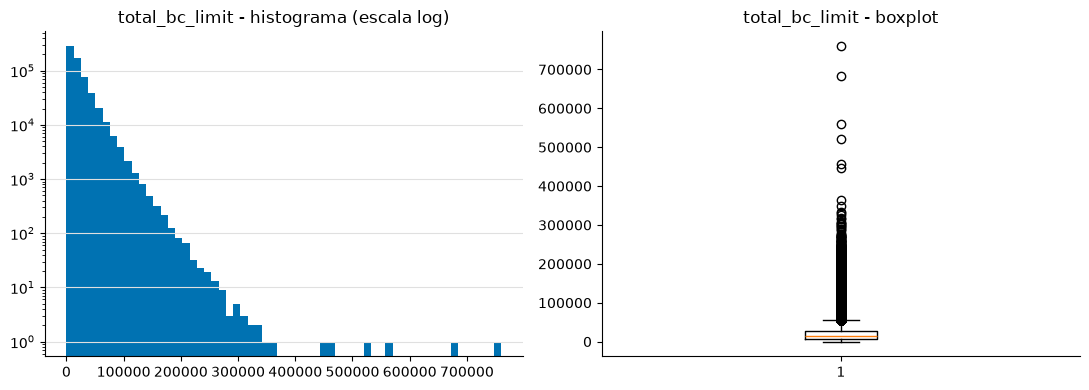

30 maiores valores:


,total_bc_limit,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
361784,760000.0,Managing Director,4 years,mortgage,a,28000.0,1600000.0,12.25,source verified,2014-07-01,Fully Paid
258694,684000.0,NaN,NaN,mortgage,a,25000.0,760000.0,4.27,verified,2015-02-01,Fully Paid
441418,560800.0,NaN,10+ years,own,e,35000.0,920000.0,8.65,verified,2014-01-01,Charged Off
643106,522210.0,Compassionate Oncology Medical Group,7 years,mortgage,a,10000.0,120000.0,13.13,source verified,2012-09-01,Fully Paid
316834,456200.0,County Administrator,5 years,rent,a,24000.0,173200.0,34.99,source verified,2014-10-01,Fully Paid
289785,447500.0,Vice President,1 year,mortgage,a,28000.0,350000.0,14.70,source verified,2014-11-01,Fully Paid
273650,363900.0,Member Manager,3 years,mortgage,a,20000.0,78000.0,25.93,source verified,2015-01-01,Fully Paid
281072,348000.0,Senior managing director,5 years,own,e,35000.0,750000.0,34.96,verified,2015-01-01,Fully Paid
213743,332200.0,Sales manager,10+ years,mortgage,a,20000.0,120000.0,17.74,source verified,2015-04-01,Fully Paid
196469,330500.0,Physician,7 years,mortgage,c,35000.0,285000.0,15.03,verified,2015-05-01,Fully Paid


Zeros exatos: 6,477
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
total_bc_limit
5000.0    5276
6000.0    4842
4000.0    4609
3000.0    4517
7000.0    4481
8000.0    4186
Name: count, dtype: int64

===== delinq_2yrs =====
count    673553.000000
mean          0.308231
std           0.854584
min           0.000000
50%           0.000000
75%           0.000000
90%           1.000000
95%           2.000000
99%           4.000000
99.9%         8.000000
max          30.000000
Name: delinq_2yrs, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 7.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


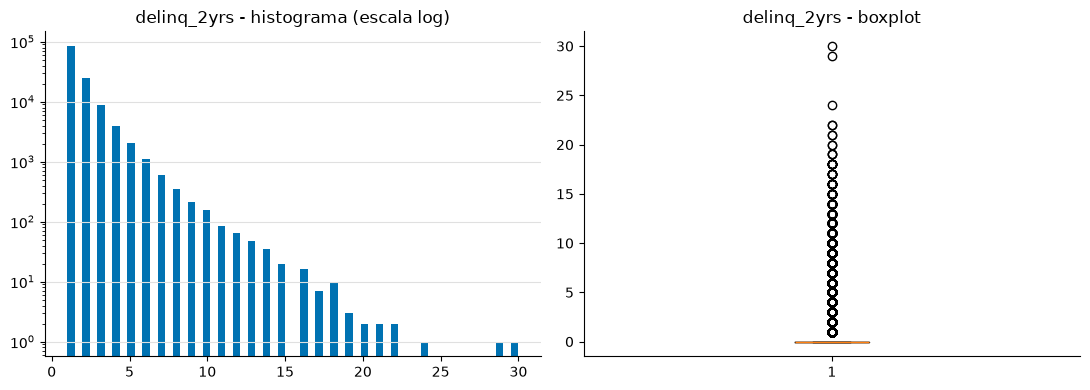

30 maiores valores:


,delinq_2yrs,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
39471,30.0,physician,< 1 year,rent,c,15000.0,140000.0,10.23,source verified,2015-11-01,Fully Paid
579057,29.0,Zimmer Gunsul Frasca,1 year,rent,c,2500.0,51500.0,10.16,not verified,2013-05-01,Fully Paid
601716,24.0,Sparrow Hospital,5 years,rent,b,24000.0,98000.0,18.16,source verified,2013-03-01,Fully Paid
300436,22.0,Research Analyst,2 years,rent,c,4000.0,50155.0,12.28,not verified,2014-11-01,Fully Paid
437411,22.0,service manager,10+ years,mortgage,c,10000.0,85000.0,18.52,not verified,2014-01-01,Fully Paid
290528,21.0,Patient Financial Counselor II,2 years,rent,c,3500.0,32646.0,26.36,not verified,2014-11-01,Fully Paid
328481,21.0,Assistant Professor,5 years,rent,b,7000.0,67260.0,14.90,not verified,2014-10-01,Fully Paid
145451,20.0,S/E Assurance leader,10+ years,mortgage,d,7425.0,60000.0,23.40,source verified,2015-07-01,Charged Off
242433,20.0,Service Technician,< 1 year,rent,b,12000.0,65000.0,12.89,source verified,2015-03-01,Charged Off
315862,19.0,Laboratory Support Services Supervisor,10+ years,mortgage,c,4000.0,65000.0,11.79,not verified,2014-10-01,Fully Paid


Zeros exatos: 546,700
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
delinq_2yrs
1.0    84523
2.0    24754
3.0     8903
4.0     3925
5.0     2038
6.0     1102
Name: count, dtype: int64

===== bc_open_to_buy =====
count    620150.000000
mean       8942.113760
std       14145.156456
min           0.000000
50%        3849.000000
75%       10513.000000
90%       23345.000000
95%       35353.550000
99%       69005.020000
99.9%    125718.659000
max      497445.000000
Name: bc_open_to_buy, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 125711.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


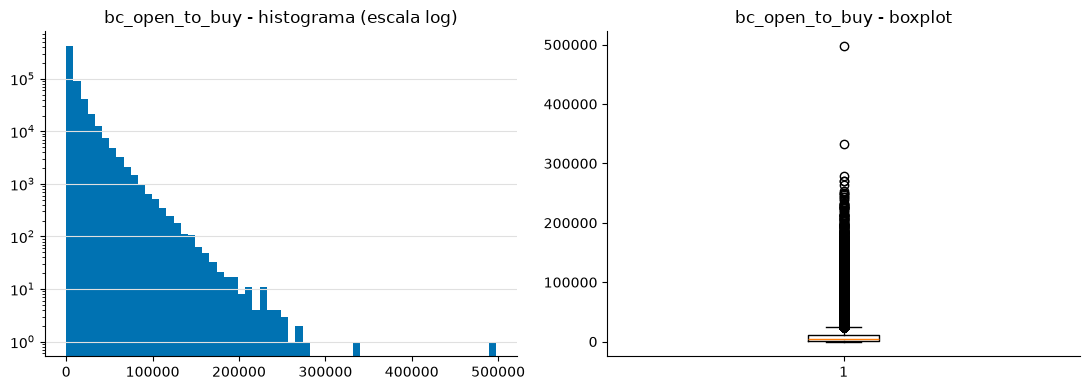

30 maiores valores:


,bc_open_to_buy,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
643106,497445.0,Compassionate Oncology Medical Group,7 years,mortgage,a,10000.0,120000.0,13.13,source verified,2012-09-01,Fully Paid
213743,332178.0,Sales manager,10+ years,mortgage,a,20000.0,120000.0,17.74,source verified,2015-04-01,Fully Paid
536784,278899.0,Cisco Systems,8 years,mortgage,a,16000.0,265000.0,8.45,verified,2013-09-01,Fully Paid
222199,271106.0,independent Distributor,2 years,own,b,32000.0,189000.0,4.62,source verified,2015-04-01,Fully Paid
557634,269756.0,Chevron,10+ years,own,a,26000.0,130000.0,16.22,verified,2013-07-01,Fully Paid
274344,264424.0,Attorney,3 years,mortgage,a,29000.0,114400.0,28.46,source verified,2015-01-01,Fully Paid
30758,253833.0,Police Detective,10+ years,own,a,12000.0,75000.0,20.32,not verified,2015-11-01,Fully Paid
308491,249625.0,Branch Manager,10+ years,mortgage,a,24000.0,75000.0,28.56,source verified,2014-10-01,Fully Paid
216414,249498.0,Executive Assistant,< 1 year,mortgage,a,24000.0,61000.0,11.82,source verified,2015-04-01,Fully Paid
544049,248279.0,Maxxam Enterprises,9 years,rent,a,19000.0,100000.0,2.26,not verified,2013-08-01,Fully Paid


Zeros exatos: 12,083
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
bc_open_to_buy
500.0     597
2000.0    581
1000.0    539
1500.0    519
2500.0    466
3000.0    458
Name: count, dtype: int64

===== mort_acc =====
count    626272.000000
mean          1.668293
std           2.067219
min           0.000000
50%           1.000000
75%           3.000000
90%           5.000000
95%           6.000000
99%           8.000000
99.9%        13.000000
max          47.000000
Name: mort_acc, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 12.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


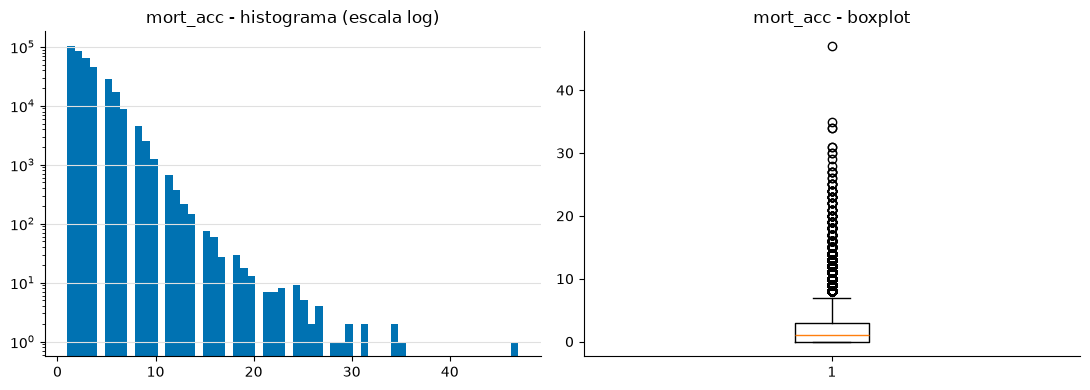

30 maiores valores:


,mort_acc,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
102356,47.0,Owner,10+ years,mortgage,d,35000.0,700000.0,6.39,source verified,2015-09-01,Fully Paid
43412,35.0,CEO,10+ years,mortgage,b,28000.0,250000.0,19.27,source verified,2015-11-01,Fully Paid
235574,34.0,Director of E-commerce,< 1 year,mortgage,c,24000.0,137000.0,12.10,source verified,2015-03-01,Fully Paid
347774,34.0,owner,10+ years,mortgage,d,24000.0,130000.0,3.18,source verified,2014-08-01,Fully Paid
360808,31.0,Member,< 1 year,mortgage,b,21000.0,200000.0,1.48,source verified,2014-07-01,Fully Paid
502268,31.0,Sales Rep,10+ years,mortgage,a,10000.0,170000.0,4.23,not verified,2013-11-01,Fully Paid
80449,30.0,escrow officer,10+ years,mortgage,a,12000.0,120000.0,9.74,not verified,2015-10-01,Fully Paid
541050,30.0,Dominink's,10+ years,rent,d,11000.0,50000.0,5.16,verified,2013-09-01,Fully Paid
598773,29.0,Commercial Door Company,10+ years,mortgage,b,6450.0,100000.0,8.96,source verified,2013-03-01,Fully Paid
265242,28.0,Owner,10+ years,mortgage,a,25000.0,287000.0,2.47,source verified,2015-01-01,Fully Paid


Zeros exatos: 265,645
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
mort_acc
1.0    102860
2.0     84074
3.0     63521
4.0     45591
5.0     28683
6.0     16966
Name: count, dtype: int64

===== num_accts_ever_120_pd =====
count    606026.000000
mean          0.483164
std           1.252625
min           0.000000
50%           0.000000
75%           0.000000
90%           2.000000
95%           3.000000
99%           6.000000
99.9%        11.000000
max          35.000000
Name: num_accts_ever_120_pd, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 10.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


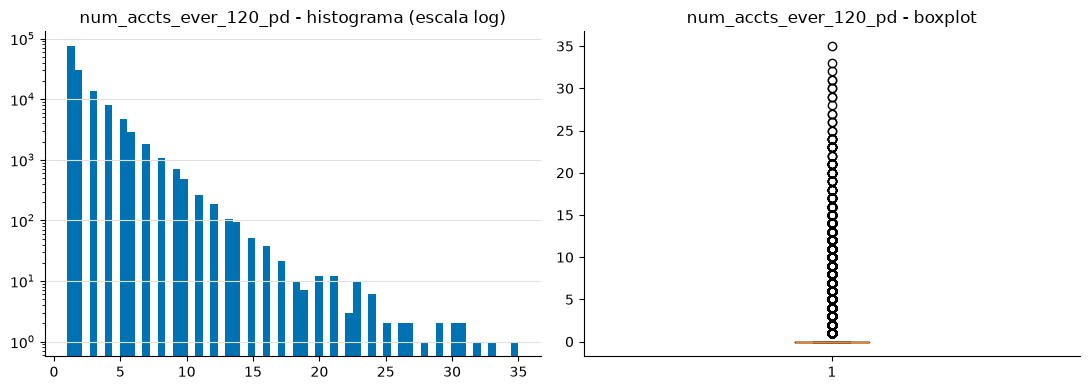

30 maiores valores:


,num_accts_ever_120_pd,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
252658,35.0,Drill Out Consultant,5 years,own,c,6400.0,75000.00,11.23,not verified,2015-02-01,Fully Paid
318353,33.0,System Analyst,4 years,rent,a,18000.0,60000.00,0.00,verified,2014-10-01,Fully Paid
11981,32.0,Research Analyst,3 years,rent,b,5600.0,50000.00,18.10,source verified,2015-12-01,Fully Paid
95908,31.0,Analyst,10+ years,own,b,8000.0,110000.00,18.96,source verified,2015-09-01,Fully Paid
184064,31.0,Site Supervisor,3 years,mortgage,d,4600.0,48000.00,23.63,not verified,2015-05-01,Fully Paid
39471,30.0,physician,< 1 year,rent,c,15000.0,140000.00,10.23,source verified,2015-11-01,Fully Paid
386689,30.0,Quality Tech/BMW Liaison,10+ years,mortgage,d,4825.0,60000.00,9.08,not verified,2014-05-01,Fully Paid
174031,29.0,Deputy Constable,10+ years,mortgage,c,8000.0,125000.00,10.86,source verified,2015-06-01,Fully Paid
579057,29.0,Zimmer Gunsul Frasca,1 year,rent,c,2500.0,51500.00,10.16,not verified,2013-05-01,Fully Paid
240435,28.0,DIRECTOR,8 years,rent,e,7075.0,80000.00,0.66,verified,2015-03-01,Fully Paid


Zeros exatos: 466,545
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
num_accts_ever_120_pd
1.0    75251
2.0    30198
3.0    13559
4.0     7918
5.0     4759
6.0     2903
Name: count, dtype: int64

===== mo_sin_rcnt_tl =====
count    606026.000000
mean          8.279935
std           9.304679
min           0.000000
50%           6.000000
75%          10.000000
90%          17.000000
95%          24.000000
99%          47.000000
99.9%        90.000000
max         263.000000
Name: mo_sin_rcnt_tl, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 89.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


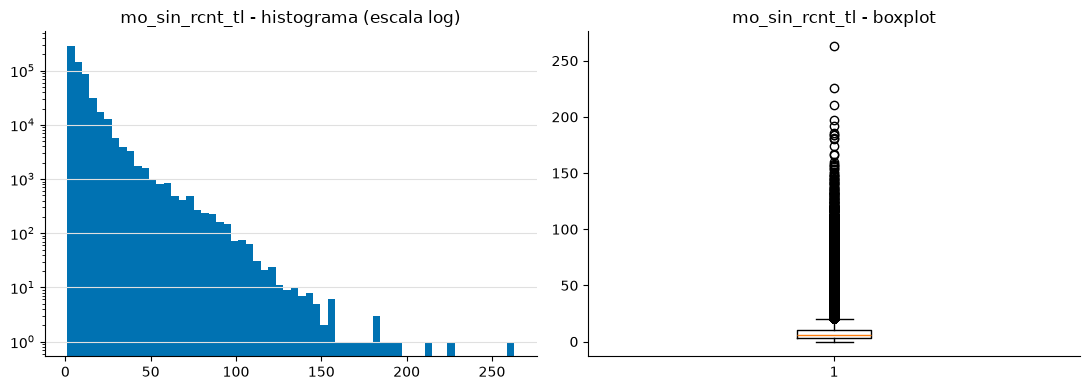

30 maiores valores:


,mo_sin_rcnt_tl,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
78670,263.0,Head Teller,10+ years,own,b,6000.0,42000.00,30.69,verified,2015-10-01,Fully Paid
396112,226.0,NaN,NaN,own,a,10000.0,32953.00,10.05,verified,2014-05-01,Fully Paid
500595,211.0,Executive Assistant,10+ years,mortgage,a,17000.0,65000.00,17.65,source verified,2013-11-01,Fully Paid
33099,197.0,NaN,NaN,own,d,2000.0,26448.00,34.81,verified,2015-12-01,Charged Off
10147,192.0,NaN,NaN,own,b,15000.0,39000.00,8.28,source verified,2015-12-01,Charged Off
191080,186.0,NaN,NaN,rent,c,1100.0,12480.00,20.48,verified,2015-05-01,Fully Paid
158668,184.0,Programme Budget Officer,< 1 year,rent,b,35000.0,124921.00,14.28,verified,2015-07-01,Fully Paid
255458,184.0,Box Office Associate,6 years,rent,c,2000.0,16000.00,19.13,verified,2015-02-01,Fully Paid
107458,181.0,NaN,NaN,own,a,5000.0,11000.00,34.28,not verified,2015-09-01,Fully Paid
393,180.0,Executive Assistant,1 year,rent,a,12600.0,73000.00,5.56,not verified,2015-12-01,Fully Paid


Zeros exatos: 9,860
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
mo_sin_rcnt_tl
2.0    65277
3.0    63057
4.0    55777
1.0    51288
5.0    48218
6.0    42766
Name: count, dtype: int64

===== max_bal_bc =====
count     14884.000000
mean       5494.782653
std        5215.952116
min           0.000000
50%        4075.500000
75%        7069.250000
90%       11763.900000
95%       15336.250000
99%       24191.250000
99.9%     37517.830000
max      127305.000000
Name: max_bal_bc, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 37402.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


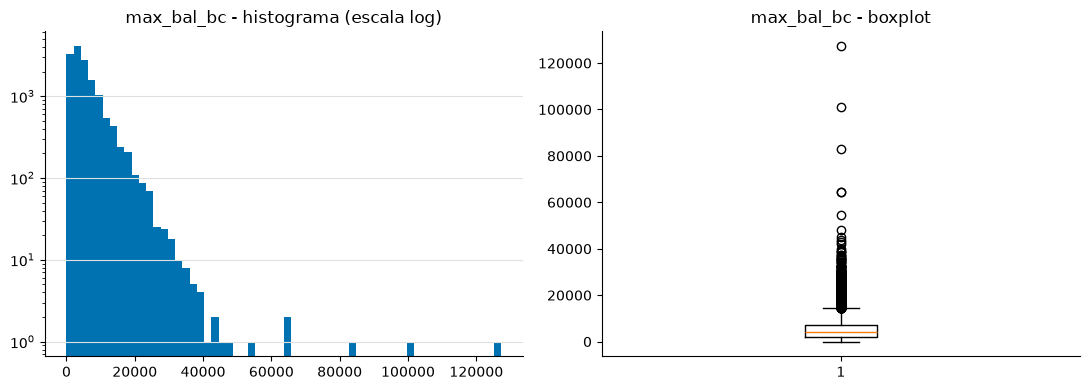

30 maiores valores:


,max_bal_bc,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
5393,127305.0,Executive Director,6 years,rent,c,16000.0,1000000.0,11.77,source verified,2015-12-01,Fully Paid
317,100973.0,Group Manager,1 year,mortgage,a,28000.0,160000.0,23.69,not verified,2015-12-01,Fully Paid
4994,83047.0,SVP,8 years,own,d,35000.0,400000.0,18.31,verified,2015-12-01,Fully Paid
2576,64490.0,Senior Financial Advisor,7 years,own,b,30000.0,145000.0,19.32,source verified,2015-12-01,Fully Paid
5388,64245.0,VP of Sales,10+ years,mortgage,a,28000.0,200000.0,30.05,source verified,2015-12-01,Fully Paid
3717,54331.0,Executive,10+ years,mortgage,b,35000.0,325000.0,16.10,source verified,2015-12-01,Fully Paid
8082,47999.0,Investment Advisor,10+ years,mortgage,c,21000.0,550000.0,16.06,source verified,2015-12-01,Fully Paid
4868,45119.0,Associate Advisor,< 1 year,rent,b,24000.0,100000.0,35.68,not verified,2015-12-01,Fully Paid
5503,43630.0,Associate General Counsel,2 years,mortgage,a,35000.0,200000.0,20.48,verified,2015-12-01,Fully Paid
4211,42732.0,"VP, Marketing",< 1 year,rent,c,35000.0,175000.0,18.36,source verified,2015-12-01,Charged Off


Zeros exatos: 310
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
max_bal_bc
2968.0    10
4900.0     9
2098.0     8
3958.0     8
1900.0     7
2265.0     7
Name: count, dtype: int64

===== acc_open_past_24mths =====
count    626272.000000
mean          4.338808
std           2.956847
min           0.000000
50%           4.000000
75%           6.000000
90%           8.000000
95%          10.000000
99%          14.000000
99.9%        20.000000
max          64.000000
Name: acc_open_past_24mths, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 19.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


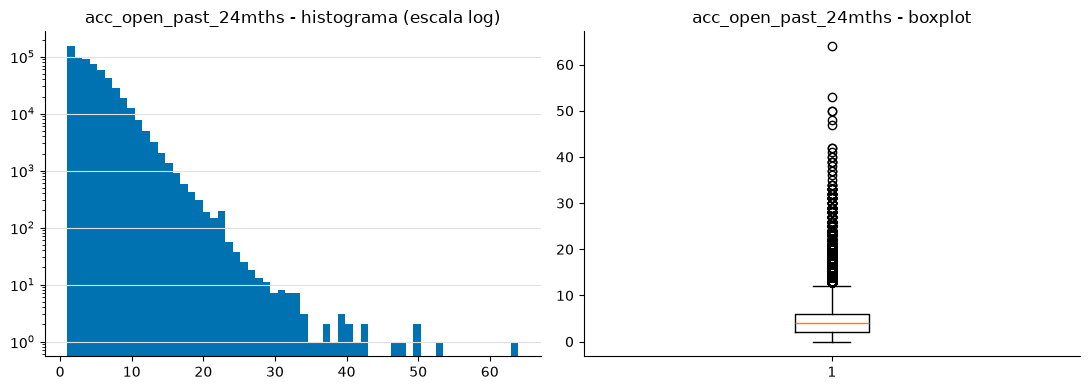

30 maiores valores:


,acc_open_past_24mths,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
16367,64.0,Armed guard,2 years,rent,c,20000.0,134000.0,15.71,source verified,2015-12-01,Charged Off
317048,53.0,Administrator,10+ years,rent,c,5600.0,45000.0,11.52,source verified,2014-10-01,Fully Paid
5015,50.0,Sales Manager,10+ years,rent,c,32000.0,142000.0,24.84,verified,2015-12-01,Charged Off
328647,50.0,Field Engineer,3 years,mortgage,c,5000.0,52000.0,29.02,verified,2014-10-01,Charged Off
121534,48.0,Medical Records,9 years,rent,c,14000.0,48000.0,25.78,verified,2015-08-01,Fully Paid
26464,47.0,Chief Deputy DA,10+ years,rent,c,3000.0,130000.0,12.36,verified,2015-11-01,Fully Paid
167837,42.0,Sr. Tax Manager,10+ years,mortgage,d,35000.0,146926.0,22.38,verified,2015-06-01,Fully Paid
316033,42.0,Physician Assistant,6 years,mortgage,b,2200.0,116000.0,11.24,verified,2014-10-01,Fully Paid
99345,41.0,LEAD Fabricator,10+ years,mortgage,e,16000.0,87000.0,24.86,verified,2015-09-01,Charged Off
6353,40.0,Sr. IP Core Operations Engineer,1 year,mortgage,e,30000.0,94000.0,22.66,verified,2015-12-01,Fully Paid


Zeros exatos: 29,432
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
acc_open_past_24mths
3.0    97161
4.0    90113
2.0    88866
5.0    75256
1.0    64515
6.0    57444
Name: count, dtype: int64

===== mo_sin_rcnt_rev_tl_op =====
count    606025.000000
mean         13.361163
std          16.516043
min           0.000000
50%           8.000000
75%          16.000000
90%          30.000000
95%          46.000000
99%          84.000000
99.9%       129.000000
max         372.000000
Name: mo_sin_rcnt_rev_tl_op, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 128.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


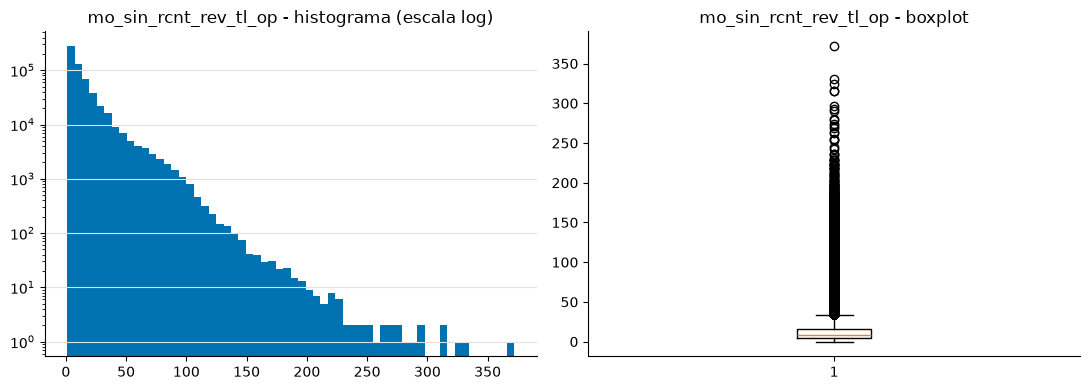

30 maiores valores:


,mo_sin_rcnt_rev_tl_op,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
303345,372.0,Agency Development Manager,< 1 year,rent,e,5000.0,28000.0,16.80,source verified,2014-11-01,Charged Off
408144,330.0,Senior Auditor,10+ years,rent,b,7000.0,55208.0,11.13,verified,2014-04-01,Fully Paid
167026,324.0,President,10+ years,mortgage,a,24800.0,78000.0,22.00,not verified,2015-06-01,Fully Paid
46127,315.0,probation officer,10+ years,mortgage,c,5600.0,62500.0,28.03,verified,2015-11-01,Fully Paid
330069,315.0,Manager,8 years,own,d,15000.0,51000.0,29.04,source verified,2014-10-01,Fully Paid
301556,297.0,Stores Specialist Sr,4 years,own,e,22000.0,50000.0,33.61,verified,2014-11-01,Charged Off
275314,293.0,Med Tech ER STAT Lab,10+ years,own,a,10000.0,60000.0,15.68,not verified,2015-01-01,Fully Paid
98066,290.0,NaN,NaN,rent,d,2000.0,20000.0,1.50,verified,2015-09-01,Charged Off
45168,280.0,Speciality Slaes,10+ years,rent,b,29000.0,127000.0,27.56,verified,2015-11-01,Fully Paid
57056,279.0,Mechanic,10+ years,rent,c,23900.0,52000.0,18.30,source verified,2015-10-01,Fully Paid


Zeros exatos: 9,513
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
mo_sin_rcnt_rev_tl_op
2.0    48072
3.0    46188
4.0    41940
1.0    39927
5.0    37415
6.0    33777
Name: count, dtype: int64

===== num_il_tl =====
count    606026.000000
mean          8.101359
std           7.132434
min           0.000000
50%           6.000000
75%          11.000000
90%          17.000000
95%          22.000000
99%          34.000000
99.9%        51.000000
max         150.000000
Name: num_il_tl, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 50.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


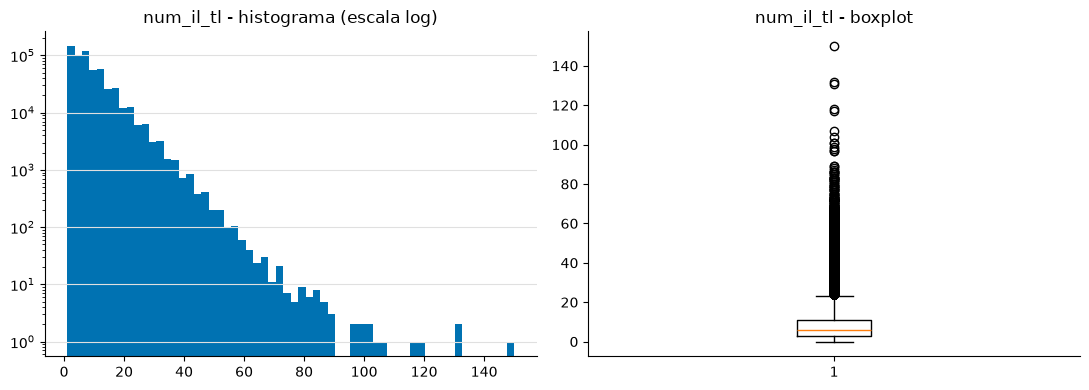

30 maiores valores:


,num_il_tl,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
296126,150.0,Correctional officer,10+ years,rent,d,12075.0,42000.0,21.43,verified,2014-11-01,Fully Paid
125180,132.0,Teacher,10+ years,mortgage,e,3825.0,65000.0,13.91,verified,2015-08-01,Fully Paid
267019,131.0,IT Manager,10+ years,mortgage,e,35000.0,185000.0,21.31,verified,2015-01-01,Fully Paid
103207,118.0,Driver,4 years,mortgage,d,12175.0,85000.0,30.13,verified,2015-09-01,Charged Off
76697,117.0,Sr Operator,3 years,rent,c,35000.0,160000.0,12.65,verified,2015-10-01,Charged Off
266293,107.0,driller,4 years,rent,e,7900.0,94000.0,10.01,verified,2015-01-01,Fully Paid
102943,104.0,Flight Attendant,10+ years,own,d,9600.0,58000.0,31.41,source verified,2015-09-01,Charged Off
65297,101.0,maintenance suppervisor,10+ years,own,f,12300.0,42000.0,15.06,verified,2015-10-01,Fully Paid
79898,101.0,School Counselor,10+ years,mortgage,c,9000.0,59928.0,9.83,source verified,2015-10-01,Fully Paid
26464,99.0,Chief Deputy DA,10+ years,rent,c,3000.0,130000.0,12.36,verified,2015-11-01,Fully Paid


Zeros exatos: 22,074
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
num_il_tl
3.0    54426
4.0    53323
2.0    50716
5.0    49976
6.0    44972
1.0    40459
Name: count, dtype: int64

===== total_bal_il =====
count     14884.000000
mean      33858.617912
std       42071.343062
min           0.000000
50%       22414.000000
75%       43761.000000
90%       75953.800000
95%      106563.550000
99%      199616.170000
99.9%    417016.144000
max      878459.000000
Name: total_bal_il, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 416989.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


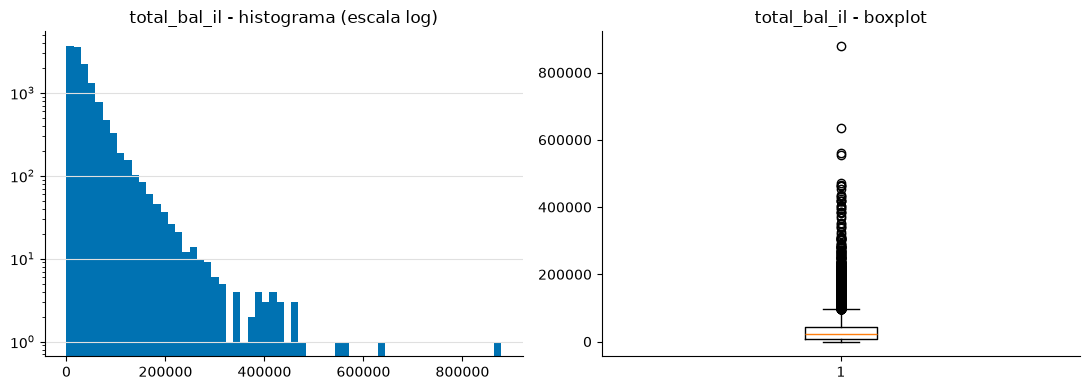

30 maiores valores:


,total_bal_il,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
1325,878459.0,Professor,10+ years,rent,a,1500.0,72000.0,12.15,not verified,2015-12-01,Fully Paid
6625,634217.0,Resident Physician,1 year,rent,b,6000.0,50000.0,38.54,not verified,2015-12-01,Charged Off
2212,561918.0,Physician,3 years,rent,b,20000.0,61097.0,27.14,not verified,2015-12-01,Fully Paid
6912,554184.0,DENTIST,10+ years,mortgage,d,30225.0,250000.0,29.49,source verified,2015-12-01,Charged Off
4564,471609.0,Manager,3 years,mortgage,d,7500.0,120000.0,16.82,verified,2015-12-01,Fully Paid
6652,466093.0,Student Recruiter,< 1 year,rent,c,5000.0,15700.0,33.99,verified,2015-12-01,Fully Paid
5309,462942.0,Dentist,< 1 year,mortgage,c,19150.0,188532.0,19.25,source verified,2015-12-01,Fully Paid
940,461516.0,Resident Physician,< 1 year,rent,d,4500.0,62275.0,3.17,verified,2015-12-01,Fully Paid
1281,452585.0,Teacher,2 years,rent,b,15000.0,100000.0,34.89,not verified,2015-12-01,Fully Paid
10265,435408.0,Publisher and Executive VIce President,1 year,mortgage,a,25000.0,240000.0,24.82,source verified,2015-12-01,Fully Paid


Zeros exatos: 1,738
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
total_bal_il
34624.0    3
11138.0    3
26748.0    3
30750.0    3
11159.0    3
25903.0    3
Name: count, dtype: int64

===== mths_since_recent_bc =====
count    620604.000000
mean         24.662830
std          30.777077
min           0.000000
50%          14.000000
75%          30.000000
90%          63.000000
95%          87.000000
99%         141.000000
99.9%       265.000000
max         616.000000
Name: mths_since_recent_bc, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 264.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


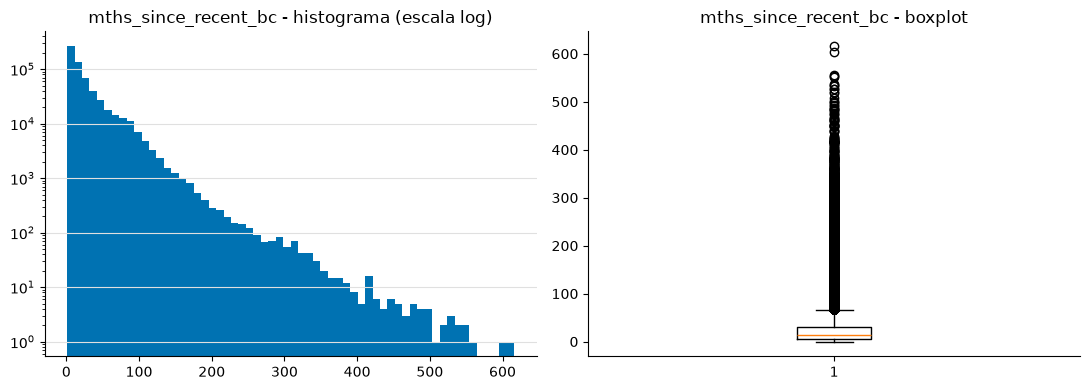

30 maiores valores:


,mths_since_recent_bc,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
349757,616.0,NaN,NaN,mortgage,a,7000.0,70000.0,5.28,verified,2014-08-01,Fully Paid
133984,604.0,Kitchen,2 years,rent,c,12225.0,36000.0,9.77,source verified,2015-08-01,Fully Paid
155725,555.0,Business Administrator,10+ years,mortgage,b,7425.0,42000.0,6.31,not verified,2015-07-01,Fully Paid
531412,554.0,San Jose Fire Department,10+ years,mortgage,d,14050.0,91200.0,0.33,not verified,2013-09-01,Fully Paid
165083,552.0,NaN,NaN,rent,b,6500.0,15024.0,21.88,verified,2015-06-01,Fully Paid
628396,538.0,Standard Bank & Trust,6 years,mortgage,b,2000.0,108000.0,19.02,not verified,2012-11-01,Charged Off
78781,534.0,Physician,3 years,rent,b,24000.0,75000.0,38.06,not verified,2015-10-01,Fully Paid
340685,533.0,NaN,NaN,rent,f,3000.0,12000.0,2.00,verified,2014-08-01,Fully Paid
228954,527.0,Physician,2 years,rent,a,16000.0,75000.0,18.89,not verified,2015-03-01,Fully Paid
611219,527.0,Alhambra Unified School District,10+ years,rent,d,10000.0,49200.0,27.48,not verified,2013-02-01,Charged Off


Zeros exatos: 3,929
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
mths_since_recent_bc
3.0    29754
2.0    29161
4.0    28351
5.0    26380
6.0    25030
7.0    23950
Name: count, dtype: int64

===== num_bc_sats =====
count    617712.000000
mean          4.652548
std           2.789389
min           0.000000
50%           4.000000
75%           6.000000
90%           8.000000
95%          10.000000
99%          14.000000
99.9%        21.000000
max          57.000000
Name: num_bc_sats, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 20.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


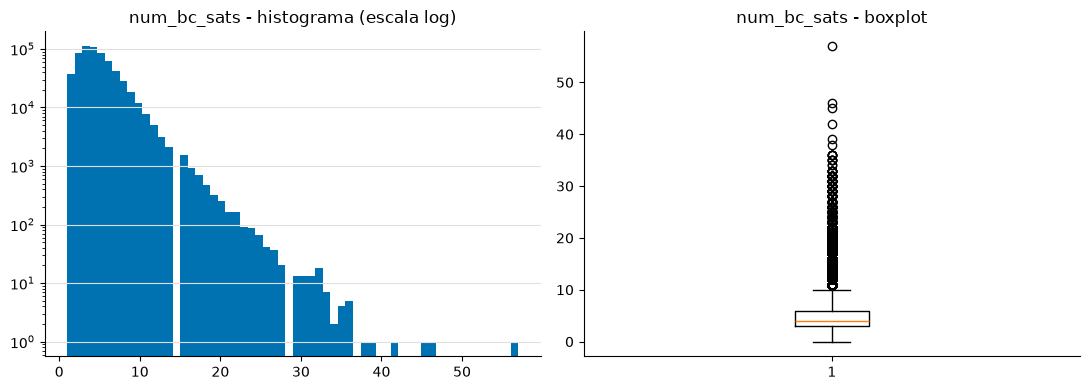

30 maiores valores:


,num_bc_sats,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
133551,57.0,pharmacy manager,10+ years,mortgage,e,35000.0,150000.0,28.34,verified,2015-07-01,Fully Paid
241357,46.0,manager,10+ years,mortgage,a,20000.0,85000.0,18.58,not verified,2015-03-01,Fully Paid
81961,45.0,Branch Manager,< 1 year,mortgage,c,35000.0,200000.0,36.55,verified,2015-10-01,Fully Paid
212726,42.0,NaN,NaN,mortgage,a,24000.0,300000.0,17.08,source verified,2015-04-01,Fully Paid
106944,39.0,Manager,1 year,rent,b,28000.0,98500.0,14.02,verified,2015-09-01,Charged Off
30758,38.0,Police Detective,10+ years,own,a,12000.0,75000.0,20.32,not verified,2015-11-01,Fully Paid
62836,36.0,Consultant,1 year,mortgage,c,32500.0,125000.0,37.79,verified,2015-10-01,Fully Paid
98316,36.0,Manager,10+ years,mortgage,a,1525.0,90000.0,22.00,not verified,2015-09-01,Fully Paid
132997,36.0,SQA Supervisor,10+ years,rent,d,28000.0,84563.0,28.21,verified,2015-08-01,Fully Paid
143531,36.0,Driector Of Operations,10+ years,own,b,24975.0,250000.0,17.52,verified,2015-07-01,Charged Off


Zeros exatos: 5,699
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
num_bc_sats
3.0    111784
4.0    106757
5.0     85429
2.0     85039
6.0     62184
7.0     42265
Name: count, dtype: int64

===== open_rv_24m =====
count    14884.000000
mean         2.978702
std          2.635207
min          0.000000
50%          2.000000
75%          4.000000
90%          6.000000
95%          8.000000
99%         11.000000
99.9%       21.000000
max         43.000000
Name: open_rv_24m, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 20.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


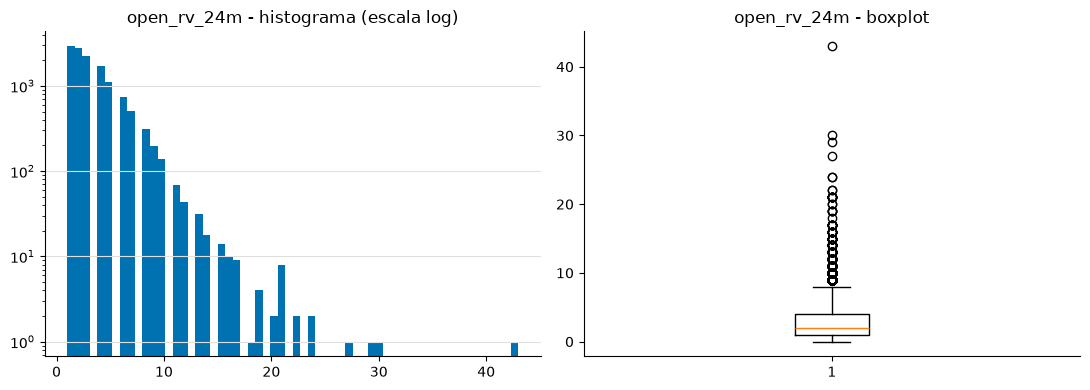

30 maiores valores:


,open_rv_24m,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
5015,43.0,Sales Manager,10+ years,rent,c,32000.0,142000.0,24.84,verified,2015-12-01,Charged Off
6353,30.0,Sr. IP Core Operations Engineer,1 year,mortgage,e,30000.0,94000.0,22.66,verified,2015-12-01,Fully Paid
1634,29.0,vent operator,10+ years,mortgage,b,12000.0,53000.0,11.77,verified,2015-12-01,Fully Paid
1712,27.0,meat management,10+ years,rent,b,12000.0,86000.0,13.37,verified,2015-12-01,Charged Off
195,24.0,Teacher,10+ years,own,c,35000.0,121000.0,9.23,source verified,2015-12-01,Fully Paid
11146,24.0,Furnace trch,10+ years,mortgage,b,6000.0,80000.0,17.18,source verified,2015-12-01,Fully Paid
3323,22.0,service agent,10+ years,mortgage,b,5000.0,42500.0,14.85,verified,2015-12-01,Fully Paid
3390,22.0,NaN,NaN,rent,c,10000.0,25200.0,23.47,verified,2015-12-01,Charged Off
3735,21.0,Truck driver,10+ years,mortgage,d,12000.0,101550.0,20.01,verified,2015-12-01,Charged Off
5542,21.0,Underwriter,4 years,rent,c,6000.0,65000.0,21.38,verified,2015-12-01,Fully Paid


Zeros exatos: 1,990
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
open_rv_24m
1.0    2928
2.0    2752
3.0    2256
4.0    1725
5.0    1120
6.0     739
Name: count, dtype: int64

===== num_tl_op_past_12m =====
count    606026.000000
mean          2.024390
std           1.714677
min           0.000000
50%           2.000000
75%           3.000000
90%           4.000000
95%           5.000000
99%           8.000000
99.9%        12.000000
max          30.000000
Name: num_tl_op_past_12m, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 11.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


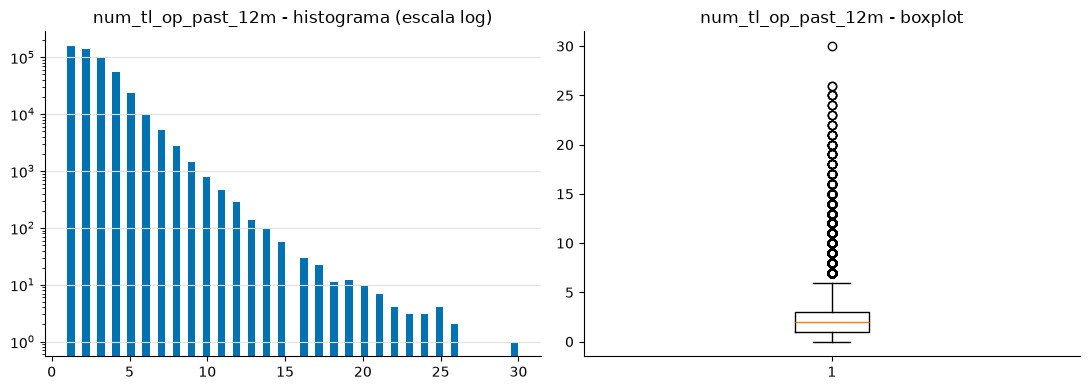

30 maiores valores:


,num_tl_op_past_12m,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
16367,30.0,Armed guard,2 years,rent,c,20000.0,134000.0,15.71,source verified,2015-12-01,Charged Off
161002,26.0,frozen/dairy associate,9 years,mortgage,d,5600.0,29000.0,29.55,verified,2015-07-01,Fully Paid
316033,26.0,Physician Assistant,6 years,mortgage,b,2200.0,116000.0,11.24,verified,2014-10-01,Fully Paid
5015,25.0,Sales Manager,10+ years,rent,c,32000.0,142000.0,24.84,verified,2015-12-01,Charged Off
26464,25.0,Chief Deputy DA,10+ years,rent,c,3000.0,130000.0,12.36,verified,2015-11-01,Fully Paid
225129,25.0,NaN,NaN,rent,e,5000.0,34000.0,12.28,source verified,2015-04-01,Fully Paid
625939,25.0,Church & Co,4 years,rent,d,12000.0,110000.0,18.51,source verified,2012-12-01,Charged Off
99591,24.0,manager,6 years,mortgage,b,10000.0,90000.0,11.76,source verified,2015-09-01,Fully Paid
277189,24.0,Managing Director,2 years,mortgage,e,15000.0,45000.0,31.65,verified,2015-01-01,Fully Paid
623908,24.0,Silverado High School,10+ years,rent,d,2050.0,95000.0,24.13,verified,2012-12-01,Charged Off


Zeros exatos: 109,811
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
num_tl_op_past_12m
1.0    157517
2.0    140260
3.0     97946
4.0     54899
5.0     24041
6.0     10250
Name: count, dtype: int64

===== bc_util =====
count    619739.000000
mean         63.162156
std          27.136183
min           0.000000
50%          67.200000
75%          86.800000
90%          95.900000
95%          98.300000
99%         101.000000
99.9%       109.800000
max         339.600000
Name: bc_util, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 109.7


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


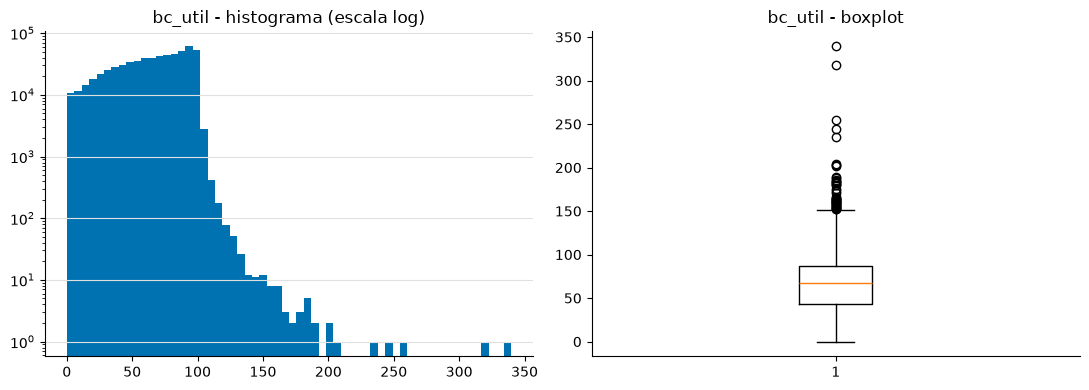

30 maiores valores:


,bc_util,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
505978,339.6,Eligibility Worker 2,10+ years,rent,d,10000.0,44000.0,6.57,source verified,2013-11-01,Fully Paid
268610,318.2,Administration,10+ years,mortgage,c,15000.0,66000.0,12.64,verified,2015-01-01,Fully Paid
342210,255.2,NaN,NaN,rent,c,10000.0,37000.0,17.97,verified,2014-08-01,Charged Off
235710,243.8,billing manager,10+ years,own,d,12000.0,50000.0,20.07,verified,2015-03-01,Charged Off
52865,235.3,account receivable,10+ years,own,d,12000.0,50000.0,33.05,verified,2015-11-01,Charged Off
272465,204.6,Quality Inspector,< 1 year,rent,c,6000.0,52000.0,21.12,source verified,2015-01-01,Charged Off
343698,202.9,Director Omni Channel,10+ years,rent,d,15000.0,130000.0,11.00,verified,2014-08-01,Fully Paid
138032,202.0,Financial Advisor,9 years,mortgage,d,35000.0,175000.0,5.18,source verified,2015-07-01,Fully Paid
348254,188.8,VP/Local Area Manager,9 years,own,c,21000.0,100000.0,29.17,source verified,2014-08-01,Fully Paid
660854,187.9,WAL MART,10+ years,mortgage,d,8000.0,35000.0,20.88,verified,2012-05-01,Charged Off


Zeros exatos: 5,856
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
bc_util
98.0    1779
97.0    1635
96.0    1628
95.0    1578
99.0    1527
94.0    1492
Name: count, dtype: int64

===== num_actv_rev_tl =====
count    606026.000000
mean          5.683835
std           3.172600
min           0.000000
50%           5.000000
75%           7.000000
90%          10.000000
95%          12.000000
99%          16.000000
99.9%        23.000000
max          52.000000
Name: num_actv_rev_tl, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 22.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


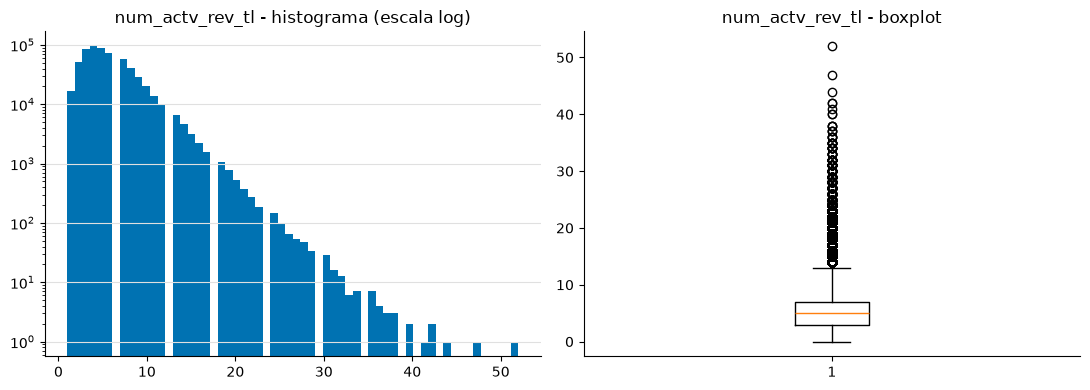

30 maiores valores:


,num_actv_rev_tl,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
167837,52.0,Sr. Tax Manager,10+ years,mortgage,d,35000.0,146926.0,22.38,verified,2015-06-01,Fully Paid
163055,47.0,Sr Process Technician,6 years,rent,d,24475.0,75000.0,27.22,verified,2015-06-01,Charged Off
133551,44.0,pharmacy manager,10+ years,mortgage,e,35000.0,150000.0,28.34,verified,2015-07-01,Fully Paid
16367,42.0,Armed guard,2 years,rent,c,20000.0,134000.0,15.71,source verified,2015-12-01,Charged Off
110002,42.0,Operations Manager,3 years,rent,c,18675.0,90000.0,32.92,verified,2015-08-01,Fully Paid
229697,41.0,Office manager,3 years,rent,b,10500.0,85000.0,25.12,source verified,2015-03-01,Fully Paid
117467,40.0,OWNER,7 years,mortgage,b,4325.0,70000.0,32.02,source verified,2015-08-01,Fully Paid
167982,40.0,Senior Lecturer,8 years,rent,e,35000.0,113000.0,34.64,verified,2015-06-01,Charged Off
58028,38.0,Operations Manager,10+ years,mortgage,d,35000.0,185000.0,25.25,verified,2015-10-01,Charged Off
209307,38.0,Sr Lead Engineer,8 years,own,d,14000.0,110000.0,33.21,verified,2015-04-01,Fully Paid


Zeros exatos: 1,664
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
num_actv_rev_tl
4.0    95567
5.0    89431
3.0    84125
6.0    73905
7.0    56837
2.0    51252
Name: count, dtype: int64

===== open_acc =====
count    673553.000000
mean         11.253028
std           5.184953
min           0.000000
50%          10.000000
75%          14.000000
90%          18.000000
95%          21.000000
99%          27.000000
99.9%        38.000000
max          84.000000
Name: open_acc, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 37.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


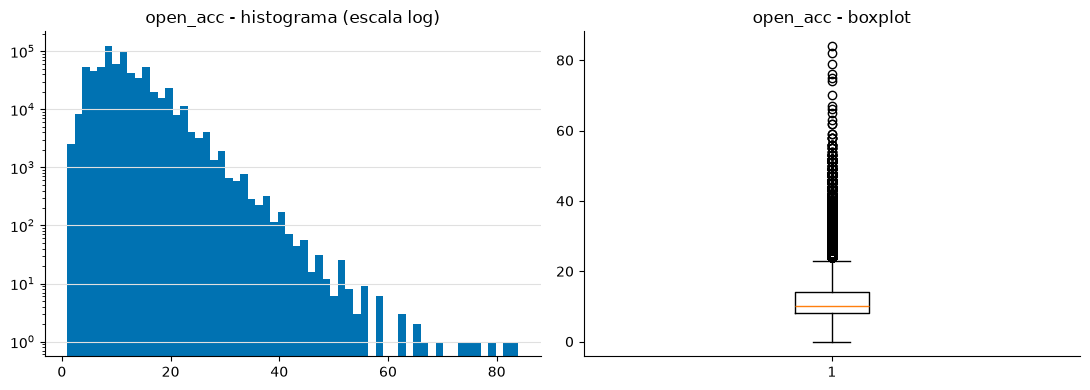

30 maiores valores:


,open_acc,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
317048,84.0,Administrator,10+ years,rent,c,5600.0,45000.0,11.52,source verified,2014-10-01,Fully Paid
110119,82.0,Counselor,10+ years,own,b,12000.0,72000.0,26.39,not verified,2015-08-01,Fully Paid
256855,79.0,Counselor,10+ years,mortgage,b,9000.0,70000.0,24.44,not verified,2015-02-01,Fully Paid
299643,76.0,Nurses,5 years,mortgage,d,20000.0,120000.0,21.53,source verified,2014-11-01,Charged Off
319410,75.0,Engineering Tech,5 years,mortgage,b,6000.0,67800.0,29.34,not verified,2014-10-01,Charged Off
270771,74.0,STAFF ACCOUNTANT,8 years,mortgage,c,12500.0,92081.0,32.71,verified,2015-01-01,Fully Paid
99591,70.0,manager,6 years,mortgage,b,10000.0,90000.0,11.76,source verified,2015-09-01,Fully Paid
16367,67.0,Armed guard,2 years,rent,c,20000.0,134000.0,15.71,source verified,2015-12-01,Charged Off
78579,66.0,Teacher,10+ years,rent,b,16000.0,60000.0,31.08,source verified,2015-10-01,Fully Paid
13158,65.0,OWNER,7 years,own,a,15000.0,100000.0,20.16,source verified,2015-12-01,Fully Paid


Zeros exatos: 6
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
open_acc
9.0     62460
8.0     60208
10.0    59756
11.0    54559
7.0     54199
12.0    48303
Name: count, dtype: int64

===== num_op_rev_tl =====
count    606026.000000
mean          8.169725
std           4.330478
min           0.000000
50%           7.000000
75%          10.000000
90%          14.000000
95%          16.000000
99%          22.000000
99.9%        31.000000
max          67.000000
Name: num_op_rev_tl, dtype: float64
Ultimo valor plausivel (maior valor abaixo do p99.9): 30.0


C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\3784591626.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(s, vert=True)


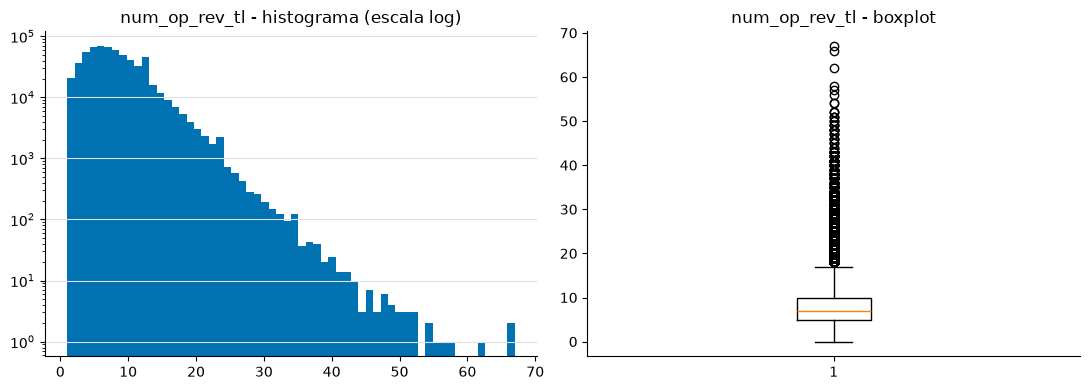

30 maiores valores:


,num_op_rev_tl,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status
99591,67.0,manager,6 years,mortgage,b,10000.0,90000.0,11.76,source verified,2015-09-01,Fully Paid
16367,66.0,Armed guard,2 years,rent,c,20000.0,134000.0,15.71,source verified,2015-12-01,Charged Off
299643,62.0,Nurses,5 years,mortgage,d,20000.0,120000.0,21.53,source verified,2014-11-01,Charged Off
553707,58.0,Palm Beach County Sheriff's Office,10+ years,mortgage,c,30000.0,80000.0,23.65,verified,2013-08-01,Fully Paid
379416,57.0,assembly line labor,6 years,rent,d,6000.0,45000.0,21.79,verified,2014-06-01,Fully Paid
317048,56.0,Administrator,10+ years,rent,c,5600.0,45000.0,11.52,source verified,2014-10-01,Fully Paid
121534,54.0,Medical Records,9 years,rent,c,14000.0,48000.0,25.78,verified,2015-08-01,Fully Paid
143531,54.0,Driector Of Operations,10+ years,own,b,24975.0,250000.0,17.52,verified,2015-07-01,Charged Off
167837,52.0,Sr. Tax Manager,10+ years,mortgage,d,35000.0,146926.0,22.38,verified,2015-06-01,Fully Paid
316033,52.0,Physician Assistant,6 years,mortgage,b,2200.0,116000.0,11.24,verified,2014-10-01,Fully Paid


Zeros exatos: 169
Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):
num_op_rev_tl
6.0    68961
5.0    65601
7.0    65568
8.0    58619
4.0    55184
9.0    49631
Name: count, dtype: int64



In [18]:
context_cols = ['emp_title', 'emp_length', 'home_ownership', 'grade', 'loan_amnt', 'annual_inc',
                'dti', 'verification_status', 'issue_d', 'loan_status']

def outlier_report(col):
    s = pop_df[col].dropna()
    print(f'===== {col} =====')
    desc = s.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
    print(desc)
    p999 = s.quantile(0.999)
    abaixo_p999 = s.loc[s < p999]
    ultimo_plausivel = abaixo_p999.max() if len(abaixo_p999) else np.nan
    print(f'Ultimo valor plausivel (maior valor abaixo do p99.9): {ultimo_plausivel}')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    pos = s[s > 0]
    if len(pos) > 0:
        axes[0].hist(pos, bins=60, color='#0072B2')
        axes[0].set_yscale('log')
    axes[0].set_title(f'{col} - histograma (escala log)')
    axes[0].grid(axis='y', color='#e0e0e0', linewidth=0.8)
    axes[1].boxplot(s, vert=True)
    axes[1].set_title(f'{col} - boxplot')
    for ax in axes:
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

    top30 = pop_df.nlargest(30, col)[[col] + context_cols]
    print('30 maiores valores:')
    display(top30)

    n_zeros = int((pop_df[col] == 0).sum())
    print(f'Zeros exatos: {n_zeros:,}')
    top_repeated = pop_df.loc[pop_df[col] != 0, col].value_counts().head(6)
    print('Valores nao-zero mais frequentes (possiveis sentinelas de preenchimento automatico):')
    print(top_repeated)
    print()

for col in outlier_bench_cols:
    outlier_report(col)


### dti: todos os casos > 100 e < 0

In [19]:
dti_context_cols = context_cols + ['term']
dti_extreme = pop_df.loc[(pop_df['dti'] > 100) | (pop_df['dti'] < 0), ['dti'] + dti_context_cols]
print(f'Casos dti > 100 ou dti < 0 na populacao: {len(dti_extreme)}')
dti_extreme


Casos dti > 100 ou dti < 0 na populacao: 5


,dti,emp_title,emp_length,home_ownership,grade,loan_amnt,annual_inc,dti,verification_status,issue_d,loan_status,term
6094,999.00,NaN,NaN,mortgage,d,6550.0,1770.0,999.00,not verified,2015-12-01,Fully Paid,36 months
7408,137.40,NaN,NaN,mortgage,d,15000.0,20000.0,137.40,source verified,2015-12-01,Fully Paid,36 months
37878,120.66,NaN,NaN,mortgage,d,15000.0,8700.0,120.66,source verified,2015-12-01,Fully Paid,36 months
50008,672.52,NaN,NaN,rent,e,12000.0,1200.0,672.52,verified,2015-11-01,Fully Paid,36 months
66098,104.00,Instructional Aide,5 years,mortgage,c,5000.0,12000.0,104.00,verified,2015-10-01,Fully Paid,36 months


### Cruzamento annual_inc x verification_status

In [20]:
print('Describe de annual_inc por verification_status:')
display(pop_df.groupby('verification_status')['annual_inc'].describe())

top100_income = pop_df.nlargest(100, 'annual_inc')
pct_not_verified = (top100_income['verification_status'].str.lower() == 'not verified').mean() * 100
print(f'% dos 100 maiores annual_inc que sao "Not Verified": {pct_not_verified:.1f}%')


Describe de annual_inc por verification_status:


,count,mean,std,min,25%,50%,75%,max
verification_status,,,,,,,,
not verified,218269.0,64648.404824,40996.507547,0.0,42000.0,58000.0,80000.0,7000000.0
source verified,231941.0,78659.555897,84830.494404,4000.0,45000.0,65000.0,92500.0,9000000.0
verified,223343.0,75485.833069,59604.736011,1200.0,45000.0,64000.0,91000.0,7500000.0


% dos 100 maiores annual_inc que sao "Not Verified": 11.0%


## Secao 6 - Consistencia logica de datas (derivada por codigo)

Regras: (1) toda coluna datetime da familia B deve ser >= issue_d; (2) earliest_cr_line
(e, por analogia, sec_app_earliest_cr_line) deve ser < issue_d. Apenas reportar, sem corrigir.

In [21]:
rule1_cols = ['last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'hardship_start_date',
              'hardship_end_date', 'payment_plan_start_date', 'debt_settlement_flag_date', 'settlement_date']
rule2_cols = ['earliest_cr_line', 'sec_app_earliest_cr_line']

date_check_results = []
for c in rule1_cols:
    both = pop_df[c].notna() & pop_df['issue_d'].notna()
    violation = both & (pop_df[c] < pop_df['issue_d'])
    n_viol = int(violation.sum())
    pct = n_viol / len(pop_df) * 100
    date_check_results.append((c, 'coluna B >= issue_d', n_viol, pct, violation))

for c in rule2_cols:
    both = pop_df[c].notna() & pop_df['issue_d'].notna()
    violation = both & (pop_df[c] >= pop_df['issue_d'])
    n_viol = int(violation.sum())
    pct = n_viol / len(pop_df) * 100
    date_check_results.append((c, 'earliest_cr_line < issue_d', n_viol, pct, violation))

for c, rule, n_viol, pct, violation in date_check_results:
    print(f'--- {c} | regra: {rule} ---')
    print(f'Violacoes: {n_viol:,} ({pct:.4f}% da populacao)')
    if n_viol > 0:
        display(pop_df.loc[violation, ['id', 'issue_d', c]].head(3))
    print()


--- last_pymnt_d | regra: coluna B >= issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- next_pymnt_d | regra: coluna B >= issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- last_credit_pull_d | regra: coluna B >= issue_d ---
Violacoes: 115 (0.0171% da populacao)


,id,issue_d,last_credit_pull_d
20327,65986108,2015-12-01,2015-11-01
24509,66180401,2015-12-01,2015-11-01
24521,65865922,2015-12-01,2015-11-01



--- hardship_start_date | regra: coluna B >= issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- hardship_end_date | regra: coluna B >= issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- payment_plan_start_date | regra: coluna B >= issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- debt_settlement_flag_date | regra: coluna B >= issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- settlement_date | regra: coluna B >= issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- earliest_cr_line | regra: earliest_cr_line < issue_d ---
Violacoes: 0 (0.0000% da populacao)

--- sec_app_earliest_cr_line | regra: earliest_cr_line < issue_d ---
Violacoes: 0 (0.0000% da populacao)



## Resumo final

In [22]:
print('SECAO 1 - classificacao de colunas:')
print(f'  A={len(family_A)}  B={len(family_B)}  C={len(family_C)}  D={len(family_D)}  E={len(family_E)}  REVISAR={len(family_REVISAR)}')
print(f'  Colunas REVISAR: {family_REVISAR}')
print()
print('SECAO 2 - AUC univariada calculada para', len(auc_df), 'colunas numericas.')
print()
print('SECAO 3 - colunas com pelo menos 1 nulo:', len(null_diag_df))
print()
print('SECAO 4 - limpezas mecanicas aplicadas em memoria (datas, percent/monetario, term/emp_length, categoricas strip/lower).')
print(f'  Duplicatas por id: {dup_by_id} | linhas em duplicata por proxy: {n_dup_rows}')
print()
print('SECAO 5 - bancada de outliers:', outlier_bench_cols)
print()
print('SECAO 6 - regras de consistencia de datas verificadas:', [r[0] for r in date_check_results])


SECAO 1 - classificacao de colunas:
  A=3  B=37  C=99  D=4  E=5  REVISAR=3
  Colunas REVISAR: ['funded_amnt', 'funded_amnt_inv', 'verification_status_joint']

SECAO 2 - AUC univariada calculada para 113 colunas numericas.

SECAO 3 - colunas com pelo menos 1 nulo: 103

SECAO 4 - limpezas mecanicas aplicadas em memoria (datas, percent/monetario, term/emp_length, categoricas strip/lower).
  Duplicatas por id: 0 | linhas em duplicata por proxy: 501

SECAO 5 - bancada de outliers: ['tot_coll_amt', 'tax_liens', 'total_rev_hi_lim', 'pub_rec', 'annual_inc', 'revol_bal', 'dti', 'num_tl_90g_dpd_24m', 'tot_hi_cred_lim', 'avg_cur_bal', 'total_bal_ex_mort', 'tot_cur_bal', 'total_il_high_credit_limit', 'revol_util', 'total_bc_limit', 'delinq_2yrs', 'bc_open_to_buy', 'mort_acc', 'num_accts_ever_120_pd', 'mo_sin_rcnt_tl', 'max_bal_bc', 'acc_open_past_24mths', 'mo_sin_rcnt_rev_tl_op', 'num_il_tl', 'total_bal_il', 'mths_since_recent_bc', 'num_bc_sats', 'open_rv_24m', 'num_tl_op_past_12m', 'bc_util', 'nu

## Investigacao de outliers multivariados e mecanismo de nulos

Somente leitura, dentro da populacao ja definida. Nenhuma remocao, nenhuma imputacao.

### Parte 1 - Outliers que se repetem entre colunas

Colunas: `bc_open_to_buy`, `revol_util`, `total_il_high_credit_limit`, `tot_cur_bal`,
`tot_coll_amt`, `total_rev_hi_lim`, `dti`, `annual_inc`. Marca "extremo" toda linha acima do
percentil 99,99 da coluna. Para `dti`, que ja mostrou valores negativos implausiveis, tambem
marca abaixo do percentil 0,01 (as demais sao valores monetarios/taxas naturalmente limitados
em zero, entao so faz sentido olhar a cauda superior).

In [23]:
extreme_cols = ['bc_open_to_buy', 'revol_util', 'total_il_high_credit_limit', 'tot_cur_bal',
                'tot_coll_amt', 'total_rev_hi_lim', 'dti', 'annual_inc']

thresholds = {}
extreme_flags = pd.DataFrame(index=pop_df.index)

for c in extreme_cols:
    upper = pop_df[c].quantile(0.9999)
    if c == 'dti':
        lower = pop_df[c].quantile(0.0001)
        flag = (pop_df[c] > upper) | (pop_df[c] < lower)
        thresholds[c] = {'p99.99_superior': upper, 'p0.01_inferior': lower}
    else:
        flag = pop_df[c] > upper
        thresholds[c] = {'p99.99_superior': upper, 'p0.01_inferior': np.nan}
    flag = flag.fillna(False)
    extreme_flags[c] = flag
    print(f'{c}: threshold superior (p99.99) = {upper}'
          + (f' | threshold inferior (p0.01) = {lower}' if c == 'dti' else '')
          + f' | linhas marcadas = {int(flag.sum())}')

thresholds_df = pd.DataFrame(thresholds).T
thresholds_df


bc_open_to_buy: threshold superior (p99.99) = 193194.179200029 | linhas marcadas = 63
revol_util: threshold superior (p99.99) = 118.80478000001749 | linhas marcadas = 68
total_il_high_credit_limit: threshold superior (p99.99) = 534834.0199999437 | linhas marcadas = 61
tot_cur_bal: threshold superior (p99.99) = 2201314.5599995106 | linhas marcadas = 61
tot_coll_amt: threshold superior (p99.99) = 63752.65749999788 | linhas marcadas = 61
total_rev_hi_lim: threshold superior (p99.99) = 646833.4999999031 | linhas marcadas = 61
dti: threshold superior (p99.99) = 39.97 | threshold inferior (p0.01) = 0.0 | linhas marcadas = 66
annual_inc: threshold superior (p99.99) = 1300000.0 | linhas marcadas = 66


,p99.99_superior,p0.01_inferior
bc_open_to_buy,1.931942e+05,NaN
revol_util,1.188048e+02,NaN
total_il_high_credit_limit,5.348340e+05,NaN
tot_cur_bal,2.201315e+06,NaN
tot_coll_amt,6.375266e+04,NaN
total_rev_hi_lim,6.468335e+05,NaN
dti,3.997000e+01,0.0
annual_inc,1.300000e+06,NaN


#### n_extremos: quantas dessas 8 colunas cada linha e extrema

In [24]:
pop_df['n_extremos'] = extreme_flags.sum(axis=1)

dist_n_extremos = pop_df['n_extremos'].value_counts().sort_index()
print('Distribuicao de n_extremos:')
dist_n_extremos


Distribuicao de n_extremos:


n_extremos
0    673083
1       440
2        24
3         5
4         1
Name: count, dtype: int64

#### Linhas com n_extremos >= 2 -> docs/outliers_multivariados.csv

In [25]:
export_cols = ['id'] + extreme_cols + ['n_extremos', 'emp_title', 'emp_length', 'home_ownership',
               'verification_status', 'grade', 'loan_amnt', 'issue_d', 'loan_status']

multi_extreme = pop_df.loc[pop_df['n_extremos'] >= 2, export_cols].sort_values('n_extremos', ascending=False)
multi_extreme.to_csv('../docs/outliers_multivariados.csv', index=False)
print(f'Linhas exportadas (n_extremos >= 2): {len(multi_extreme)}')

if len(multi_extreme) <= 40:
    display(multi_extreme)
else:
    display(multi_extreme.head(40))
    print(f'... mostrando as primeiras 40 de {len(multi_extreme)} (ordenadas por n_extremos decrescente).')


Linhas exportadas (n_extremos >= 2): 30


,id,bc_open_to_buy,revol_util,total_il_high_credit_limit,tot_cur_bal,tot_coll_amt,total_rev_hi_lim,dti,annual_inc,n_extremos,emp_title,emp_length,home_ownership,verification_status,grade,loan_amnt,issue_d,loan_status
361784,21200242,18652.0,66.3,1241783.0,3258254.0,0.0,867000.0,12.25,1600000.0,4,Managing Director,4 years,mortgage,source verified,a,28000.0,2014-07-01,Fully Paid
27624,65875440,14492.0,97.4,975560.0,3078704.0,0.0,501500.0,22.81,1473000.0,3,NaN,NaN,mortgage,verified,c,25575.0,2015-12-01,Fully Paid
96468,59211112,1231.0,98.8,12856.0,2809127.0,0.0,798500.0,4.53,1500000.0,3,Strategic Advisor & Consultant,1 year,mortgage,source verified,c,35000.0,2015-09-01,Fully Paid
622976,2377118,0.0,0.0,70492.0,8000078.0,0.0,988000.0,2.36,5000000.0,3,VISIUM asset management,10+ years,mortgage,verified,c,35000.0,2012-12-01,Fully Paid
297260,35013239,30730.0,86.3,873501.0,3189813.0,0.0,500500.0,21.29,1350000.0,3,lawyer-partner,10+ years,mortgage,verified,b,35000.0,2014-11-01,Fully Paid
88149,60932893,200466.0,27.0,348030.0,3182645.0,0.0,747000.0,10.18,1053595.0,3,0wner,10+ years,mortgage,source verified,a,35000.0,2015-10-01,Fully Paid
65997,62844314,46993.0,44.7,66811.0,2271242.0,0.0,168400.0,2.02,3000000.0,2,CTO,4 years,own,source verified,b,35000.0,2015-10-01,Fully Paid
37985,65504642,2938.0,89.7,81200.0,2482331.0,0.0,678400.0,8.06,1096000.0,2,Managing Director,5 years,own,verified,c,29400.0,2015-11-01,Fully Paid
69003,62216863,38892.0,28.9,71304.0,2245161.0,0.0,304700.0,3.08,1500000.0,2,President,5 years,mortgage,verified,a,35000.0,2015-10-01,Fully Paid
91520,60506967,74556.0,38.7,39990.0,2651565.0,0.0,915545.0,10.81,920000.0,2,managing Director,5 years,rent,source verified,a,21600.0,2015-09-01,Fully Paid


#### Linhas com n_extremos == 1: contagem por coluna

In [26]:
single_extreme_mask = pop_df['n_extremos'] == 1
single_extreme_counts = extreme_flags.loc[single_extreme_mask].sum(axis=0).sort_values(ascending=False)
print(f'Linhas com n_extremos == 1: {int(single_extreme_mask.sum())}')
single_extreme_counts


Linhas com n_extremos == 1: 440


revol_util                    68
dti                           66
tot_coll_amt                  61
bc_open_to_buy                61
total_il_high_credit_limit    56
annual_inc                    55
total_rev_hi_lim              40
tot_cur_bal                   33
dtype: int64

### Parte 2 - Mecanismo do bloco de nulos de 10,0255%

Item 6 usa percentuais dentro da populacao (para achar o bloco). Itens 7 e 8 recalculam o
%nulo por ano de issue_d no **arquivo inteiro** (2.260.701 linhas), nao so na populacao, para
enxergar o padrao temporal completo (a populacao corta as safras de 2016-2018, justamente onde
esses atributos passaram a existir).

In [27]:
null_pct_pop = pop_df.isnull().mean() * 100

block_10 = null_pct_pop[(null_pct_pop >= 10.02) & (null_pct_pop <= 10.03)].sort_values(ascending=False)
print('Colunas com %nulo entre 10.02% e 10.03% na populacao:')
print(block_10)

ref_mask = pop_df['tot_cur_bal'].isna()
overlap_rows = []
for c in block_10.index:
    col_mask = pop_df[c].isna()
    pct_of_ref = (col_mask & ref_mask).sum() / ref_mask.sum() * 100
    pct_of_col = (col_mask & ref_mask).sum() / col_mask.sum() * 100 if col_mask.sum() > 0 else np.nan
    overlap_rows.append({'coluna': c, '%nulo': round(null_pct_pop[c], 4),
                          'n_nulos': int(col_mask.sum()),
                          '%_dos_nulos_de_tot_cur_bal_tambem_nulos_aqui': round(pct_of_ref, 2),
                          '%_dos_nulos_desta_coluna_tambem_nulos_em_tot_cur_bal': round(pct_of_col, 2)})

overlap_df = pd.DataFrame(overlap_rows).sort_values('%nulo', ascending=False)
overlap_df


Colunas com %nulo entre 10.02% e 10.03% na populacao:
avg_cur_bal                   10.027125
num_rev_accts                 10.025640
mo_sin_rcnt_rev_tl_op         10.025640
mo_sin_old_rev_tl_op          10.025640
total_rev_hi_lim              10.025492
tot_cur_bal                   10.025492
tot_coll_amt                  10.025492
mo_sin_rcnt_tl                10.025492
num_actv_bc_tl                10.025492
num_actv_rev_tl               10.025492
num_bc_tl                     10.025492
num_accts_ever_120_pd         10.025492
num_il_tl                     10.025492
num_op_rev_tl                 10.025492
num_rev_tl_bal_gt_0           10.025492
num_tl_30dpd                  10.025492
num_tl_90g_dpd_24m            10.025492
num_tl_op_past_12m            10.025492
tot_hi_cred_lim               10.025492
total_il_high_credit_limit    10.025492
dtype: float64


,coluna,%nulo,n_nulos,%_dos_nulos_de_tot_cur_bal_tambem_nulos_aqui,%_dos_nulos_desta_coluna_tambem_nulos_em_tot_cur_bal
0,avg_cur_bal,10.0271,67538,100.0,99.98
1,num_rev_accts,10.0256,67528,100.0,100.00
2,mo_sin_rcnt_rev_tl_op,10.0256,67528,100.0,100.00
3,mo_sin_old_rev_tl_op,10.0256,67528,100.0,100.00
4,total_rev_hi_lim,10.0255,67527,100.0,100.00
5,tot_cur_bal,10.0255,67527,100.0,100.00
6,tot_coll_amt,10.0255,67527,100.0,100.00
7,mo_sin_rcnt_tl,10.0255,67527,100.0,100.00
8,num_actv_bc_tl,10.0255,67527,100.0,100.00
9,num_actv_rev_tl,10.0255,67527,100.0,100.00


#### Identificacao dos outros dois blocos citados (97,79% e 7,0196%), tambem por %nulo na populacao

In [28]:
block_97 = null_pct_pop[(null_pct_pop >= 97.70) & (null_pct_pop <= 97.90)].sort_values(ascending=False)
print('Colunas com %nulo ~97.79% na populacao ("open_acc_6m e afins"):')
print(block_97)
print()

block_7 = null_pct_pop[(null_pct_pop >= 6.95) & (null_pct_pop <= 7.10)].sort_values(ascending=False)
print('Colunas com %nulo ~7.02% na populacao (acc_open_past_24mths / mort_acc / total_bal_ex_mort e afins):')
print(block_7)


Colunas com %nulo ~97.79% na populacao ("open_acc_6m e afins"):
mths_since_rcnt_il    97.859263
open_acc_6m           97.790226
open_act_il           97.790226
open_il_12m           97.790226
open_il_24m           97.790226
total_bal_il          97.790226
open_rv_12m           97.790226
open_rv_24m           97.790226
max_bal_bc            97.790226
all_util              97.790226
inq_fi                97.790226
total_cu_tl           97.790226
inq_last_12m          97.790226
dtype: float64

Colunas com %nulo ~7.02% na populacao (acc_open_past_24mths / mort_acc / total_bal_ex_mort e afins):
acc_open_past_24mths    7.019641
mort_acc                7.019641
total_bal_ex_mort       7.019641
total_bc_limit          7.019641
dtype: float64


#### %nulo por ano de issue_d no arquivo inteiro

Um unico passe pelo arquivo inteiro (chunks de 50.000 linhas) cobrindo: `tot_cur_bal`
(item 7), o bloco ~97,79% (item 8) e o bloco ~7,02% (item 8), mais as 5 colunas
`mths_since_*` (item 9), todas juntas para eficiencia.

In [29]:
mths_since_cols_9 = ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_recent_bc_dlq',
                      'mths_since_recent_revol_delinq', 'mths_since_last_major_derog']

year_track_cols = ['tot_cur_bal'] + list(block_97.index) + list(block_7.index) + mths_since_cols_9
year_track_cols = list(dict.fromkeys(year_track_cols))
usecols = ['issue_d'] + year_track_cols

null_counts_by_year = {}
total_counts_by_year = {}

for chunk in pd.read_csv(RAW_PATH, usecols=usecols, chunksize=CHUNK_SIZE, low_memory=False):
    years = pd.to_datetime(chunk['issue_d'], format='%b-%Y', errors='coerce').dt.year
    for y, grp in chunk.groupby(years):
        if pd.isna(y):
            continue
        y = int(y)
        if y not in total_counts_by_year:
            total_counts_by_year[y] = 0
            null_counts_by_year[y] = pd.Series(0, index=year_track_cols, dtype='int64')
        total_counts_by_year[y] += len(grp)
        null_counts_by_year[y] = null_counts_by_year[y].add(grp[year_track_cols].isnull().sum(), fill_value=0)

years_sorted = sorted(total_counts_by_year.keys())
null_pct_by_year = pd.DataFrame({y: (null_counts_by_year[y] / total_counts_by_year[y] * 100).round(2) for y in years_sorted}).T
null_pct_by_year.index.name = 'ano_emissao'
print(f'Colunas rastreadas: {len(year_track_cols)}')
null_pct_by_year


Colunas rastreadas: 23


,tot_cur_bal,mths_since_rcnt_il,open_acc_6m,open_act_il,open_il_12m,open_il_24m,total_bal_il,open_rv_12m,open_rv_24m,max_bal_bc,all_util,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,mort_acc,total_bal_ex_mort,total_bc_limit,mths_since_last_delinq,mths_since_last_record,mths_since_recent_bc_dlq,mths_since_recent_revol_delinq,mths_since_last_major_derog
ano_emissao,,,,,,,,,,,,,,,,,,,,,,,
2007,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,6.47,6.97,100.00,100.00,100.00
2008,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,38.07,60.64,100.00,100.00,100.00
2009,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,66.96,95.21,100.00,100.00,100.00
2010,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,64.28,94.00,100.00,100.00,100.00
2011,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,66.21,94.74,100.00,100.00,100.00
2012,51.98,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,14.04,14.04,14.04,14.04,58.84,97.24,87.43,73.92,89.91
2013,0.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.00,0.00,0.00,0.00,56.50,88.13,77.72,69.94,79.87
2014,0.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.00,0.00,0.00,0.00,49.18,82.38,73.57,64.03,71.79
2015,0.00,95.06,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,0.00,0.00,0.00,0.00,48.44,82.33,74.21,63.97,70.85


##### tot_cur_bal - %nulo por ano (item 7)

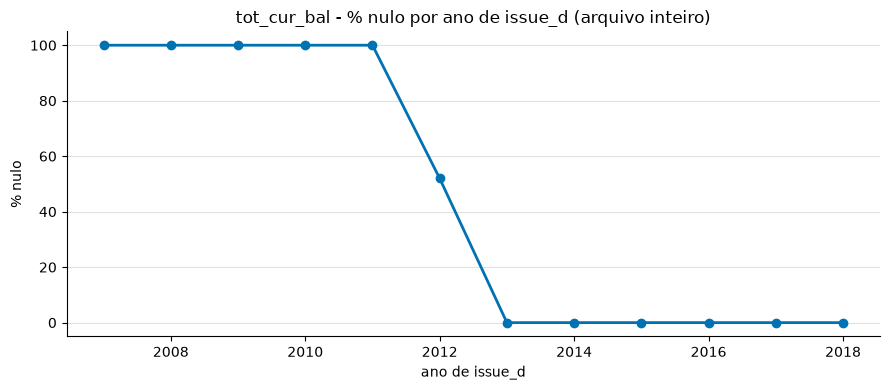

,tot_cur_bal
ano_emissao,
2007,100.00
2008,100.00
2009,100.00
2010,100.00
2011,100.00
2012,51.98
2013,0.00
2014,0.00
2015,0.00


In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(null_pct_by_year.index, null_pct_by_year['tot_cur_bal'], marker='o', color='#0072B2', linewidth=2)
ax.set_xlabel('ano de issue_d')
ax.set_ylabel('% nulo')
ax.set_title('tot_cur_bal - % nulo por ano de issue_d (arquivo inteiro)')
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

null_pct_by_year[['tot_cur_bal']]


##### Bloco ~97,79% (open_acc_6m e afins) - %nulo por ano (item 8)

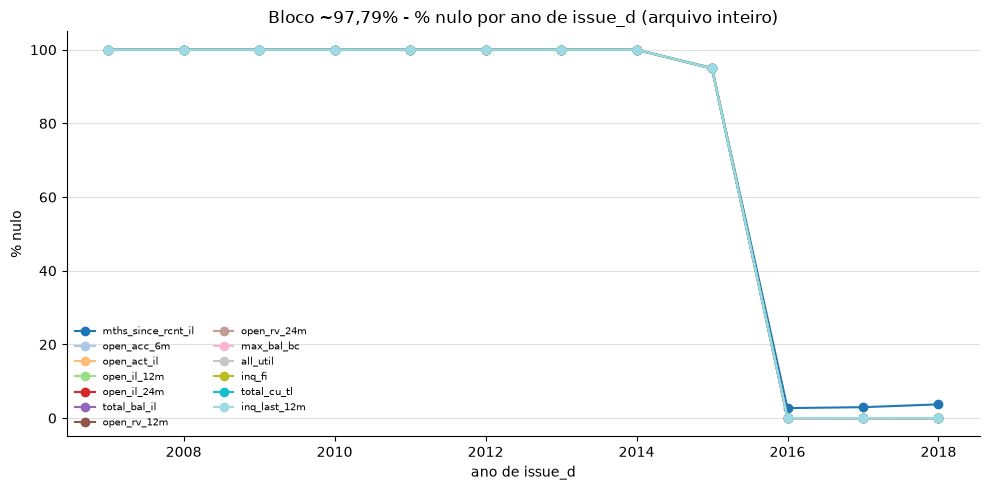

,mths_since_rcnt_il,open_acc_6m,open_act_il,open_il_12m,open_il_24m,total_bal_il,open_rv_12m,open_rv_24m,max_bal_bc,all_util,inq_fi,total_cu_tl,inq_last_12m
ano_emissao,,,,,,,,,,,,,
2007,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2008,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2009,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2010,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2011,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2012,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2013,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2014,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2015,95.06,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92


In [31]:
cols_97 = list(block_97.index)
colors_97 = plt.cm.tab20(np.linspace(0, 1, len(cols_97)))

fig, ax = plt.subplots(figsize=(10, 5))
for c, col in zip(cols_97, colors_97):
    ax.plot(null_pct_by_year.index, null_pct_by_year[c], marker='o', linewidth=1.5, color=col, label=c)
ax.set_xlabel('ano de issue_d')
ax.set_ylabel('% nulo')
ax.set_title('Bloco ~97,79% - % nulo por ano de issue_d (arquivo inteiro)')
ax.legend(fontsize=7, ncol=2, frameon=False, loc='lower left')
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

null_pct_by_year[cols_97]


##### Bloco ~7,02% (acc_open_past_24mths / mort_acc / total_bal_ex_mort e afins) - %nulo por ano (item 8)

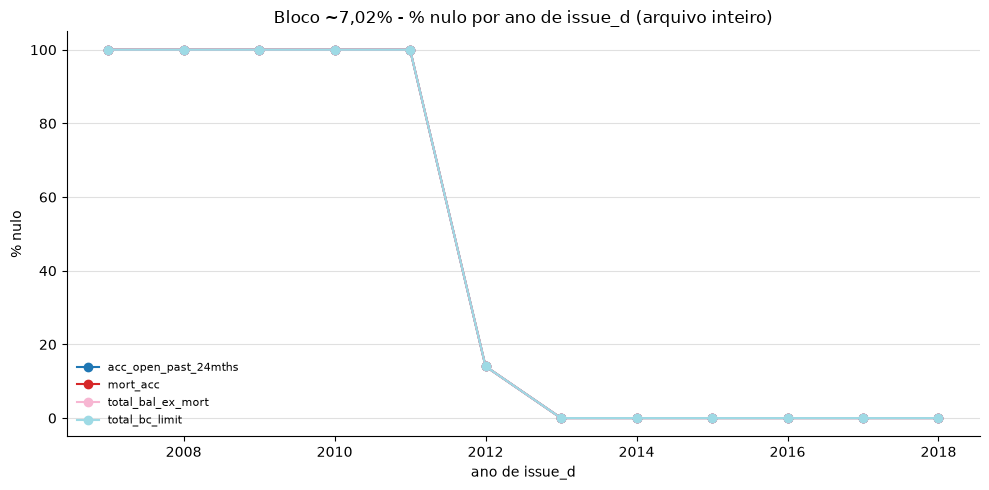

,acc_open_past_24mths,mort_acc,total_bal_ex_mort,total_bc_limit
ano_emissao,,,,
2007,100.00,100.00,100.00,100.00
2008,100.00,100.00,100.00,100.00
2009,100.00,100.00,100.00,100.00
2010,100.00,100.00,100.00,100.00
2011,100.00,100.00,100.00,100.00
2012,14.04,14.04,14.04,14.04
2013,0.00,0.00,0.00,0.00
2014,0.00,0.00,0.00,0.00
2015,0.00,0.00,0.00,0.00


In [32]:
cols_7 = list(block_7.index)
colors_7 = plt.cm.tab20(np.linspace(0, 1, len(cols_7)))

fig, ax = plt.subplots(figsize=(10, 5))
for c, col in zip(cols_7, colors_7):
    ax.plot(null_pct_by_year.index, null_pct_by_year[c], marker='o', linewidth=1.5, color=col, label=c)
ax.set_xlabel('ano de issue_d')
ax.set_ylabel('% nulo')
ax.set_title('Bloco ~7,02% - % nulo por ano de issue_d (arquivo inteiro)')
ax.legend(fontsize=8, ncol=1, frameon=False, loc='lower left')
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

null_pct_by_year[cols_7]


#### Colunas mths_since_* (item 9): %nulo, taxa de default nulo vs. preenchido, e %nulo por ano

`mths_since_last_delinq`, `mths_since_last_record`, `mths_since_recent_bc_dlq`,
`mths_since_recent_revol_delinq`, `mths_since_last_major_derog`. A comparacao %nulo-por-ano
(arquivo inteiro, ja calculada acima) ajuda a separar "nunca teve o evento" (nulo estavel ao
longo de todas as safras) de "coluna nao coletada na epoca" (nulo cai a partir de certo ano).

In [33]:
rows9 = []
for c in mths_since_cols_9:
    pct_null = round(pop_df[c].isnull().mean() * 100, 4)
    is_null_mask = pop_df[c].isnull()
    taxa_null = pop_df.loc[is_null_mask, 'target'].mean() * 100
    taxa_preenchido = pop_df.loc[~is_null_mask, 'target'].mean() * 100
    diff = taxa_null - taxa_preenchido
    rows9.append({'nome': c, '%nulo_populacao': pct_null, 'default_nulo_%': round(taxa_null, 2),
                  'default_preenchido_%': round(taxa_preenchido, 2), 'diferenca_pp': round(diff, 2)})

mths_since_diag_df = pd.DataFrame(rows9)
mths_since_diag_df


,nome,%nulo_populacao,default_nulo_%,default_preenchido_%,diferenca_pp
0,mths_since_last_delinq,51.7655,14.41,15.25,-0.83
1,mths_since_last_record,84.5785,14.46,16.78,-2.32
2,mths_since_recent_bc_dlq,77.0700,14.63,15.45,-0.82
3,mths_since_recent_revol_delinq,67.7555,14.63,15.20,-0.57
4,mths_since_last_major_derog,75.4238,14.40,16.10,-1.70


In [34]:
null_pct_by_year[mths_since_cols_9]


,mths_since_last_delinq,mths_since_last_record,mths_since_recent_bc_dlq,mths_since_recent_revol_delinq,mths_since_last_major_derog
ano_emissao,,,,,
2007,6.47,6.97,100.00,100.00,100.00
2008,38.07,60.64,100.00,100.00,100.00
2009,66.96,95.21,100.00,100.00,100.00
2010,64.28,94.00,100.00,100.00,100.00
2011,66.21,94.74,100.00,100.00,100.00
2012,58.84,97.24,87.43,73.92,89.91
2013,56.50,88.13,77.72,69.94,79.87
2014,49.18,82.38,73.57,64.03,71.79
2015,48.44,82.33,74.21,63.97,70.85


## Auditoria da linha n_extremos=4

Somente leitura, dentro da populacao ja definida. Nenhuma remocao, nenhum tratamento.

### 1. A linha completa (151 colunas originais, transposta)

In [35]:
target_mask = pop_df['n_extremos'] == 4
target_id = pop_df.loc[target_mask, 'id'].iloc[0]
print(f'id da linha n_extremos=4: {target_id}')

target_row_full = pop_df.loc[target_mask, columns].T
target_row_full.columns = ['valor']
target_row_full


id da linha n_extremos=4: 21200242


,valor
id,21200242
member_id,NaN
loan_amnt,28000.0
funded_amnt,28000.0
funded_amnt_inv,28000.0
term,36 months
int_rate,7.69
installment,873.42
grade,a
sub_grade,a4


### 2. Razoes de plausibilidade para essa linha

- divida mensal implicita = (dti / 100) * (annual_inc / 12)
- installment como % da renda mensal
- tot_cur_bal / annual_inc
- revol_bal / total_rev_hi_lim (utilizacao real) vs. revol_util reportado
- tot_coll_amt / annual_inc
- loan_amnt como % da renda anual

In [36]:
def build_ratio_frame(df):
    r = pd.DataFrame({
        'renda_mensal': df['annual_inc'] / 12,
        'divida_mensal_implicita_dti': (df['dti'] / 100) * (df['annual_inc'] / 12),
        'installment_pct_renda_mensal': df['installment'] / (df['annual_inc'] / 12) * 100,
        'tot_cur_bal_sobre_annual_inc': df['tot_cur_bal'] / df['annual_inc'],
        'revol_util_calculado_%': df['revol_bal'] / df['total_rev_hi_lim'] * 100,
        'revol_util_reportado_%': df['revol_util'],
        'tot_coll_amt_sobre_annual_inc': df['tot_coll_amt'] / df['annual_inc'],
        'loan_amnt_pct_annual_inc': df['loan_amnt'] / df['annual_inc'] * 100,
    }, index=df.index)
    return r.replace([np.inf, -np.inf], np.nan)

target_row_df = pop_df.loc[target_mask]
ratios_target = build_ratio_frame(target_row_df).iloc[0]

print(f"Divida mensal implicita (dti): \$ {ratios_target['divida_mensal_implicita_dti']:,.2f}")
print(f"Renda mensal (annual_inc/12):  \$ {ratios_target['renda_mensal']:,.2f}")
print(f"Divida mensal implicita / renda mensal = {ratios_target['divida_mensal_implicita_dti'] / ratios_target['renda_mensal'] * 100:.2f}% "
      f"(deve bater com o dti reportado: {target_row_df['dti'].iloc[0]}%)")
print()
ratios_target


Divida mensal implicita (dti): \$ 16,333.33
Renda mensal (annual_inc/12):  \$ 133,333.33
Divida mensal implicita / renda mensal = 12.25% (deve bater com o dti reportado: 12.25%)



<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\2871060363.py:17: SyntaxWarning: invalid escape sequence '\$'
  print(f"Divida mensal implicita (dti): \$ {ratios_target['divida_mensal_implicita_dti']:,.2f}")
C:\Users\Avell\AppData\Local\Temp\ipykernel_30828\2871060363.py:18: SyntaxWarning: invalid escape sequence '\$'
  print(f"Renda mensal (annual_inc/12):  \$ {ratios_target['renda_mensal']:,.2f}")


renda_mensal                     133333.333333
divida_mensal_implicita_dti       16333.333333
installment_pct_renda_mensal          0.655065
tot_cur_bal_sobre_annual_inc          2.036409
revol_util_calculado_%               96.949020
revol_util_reportado_%               66.300000
tot_coll_amt_sobre_annual_inc         0.000000
loan_amnt_pct_annual_inc              1.750000
Name: 361784, dtype: float64

### 3. Mesmo calculo para os outros 29 pares (n_extremos >= 2) do docs/outliers_multivariados.csv

In [37]:
# O CSV exportado nao tem installment/revol_bal (necessarios aqui); usamos pop_df filtrado
# pelos mesmos ids do arquivo, que e a fonte identica dos dados.
peer_ids = multi_extreme.loc[multi_extreme['id'] != target_id, 'id']
print(f'Numero de pares (deve ser 29): {len(peer_ids)}')

peers_df = pop_df.loc[pop_df['id'].isin(peer_ids)]
ratios_peers = build_ratio_frame(peers_df)
ratios_peers_median = ratios_peers.median()
ratios_peers_median


Numero de pares (deve ser 29): 29


renda_mensal                     83333.250000
divida_mensal_implicita_dti       8276.666667
installment_pct_renda_mensal         1.082625
tot_cur_bal_sobre_annual_inc         3.020748
revol_util_calculado_%              86.594676
revol_util_reportado_%              44.700000
tot_coll_amt_sobre_annual_inc        0.000000
loan_amnt_pct_annual_inc             2.800000
dtype: float64

### 4. Mesmo calculo para a populacao inteira (mediana de referencia)

In [38]:
ratios_pop = build_ratio_frame(pop_df)
ratios_pop_median = ratios_pop.median()
ratios_pop_median


renda_mensal                     5083.333333
divida_mensal_implicita_dti       855.000000
installment_pct_renda_mensal        7.246500
tot_cur_bal_sobre_annual_inc        1.110354
revol_util_calculado_%             55.308611
revol_util_reportado_%             55.000000
tot_coll_amt_sobre_annual_inc       0.000000
loan_amnt_pct_annual_inc           18.750000
dtype: float64

### 5. Comparacao lado a lado e sinalizacao de divergencia > 3x em relacao aos pares

In [39]:
comparison = pd.DataFrame({
    'linha_n_extremos_4': ratios_target,
    'mediana_29_pares': ratios_peers_median,
    'mediana_populacao': ratios_pop_median,
})

comparison['razao_vs_pares'] = comparison['linha_n_extremos_4'] / comparison['mediana_29_pares']

def divergence_factor(x):
    if pd.isna(x) or x == 0:
        return np.nan
    return max(abs(x), 1 / abs(x))

comparison['fator_divergencia_vs_pares'] = comparison['razao_vs_pares'].apply(divergence_factor)
comparison['diverge_mais_de_3x_dos_pares'] = comparison['fator_divergencia_vs_pares'] > 3

comparison


,linha_n_extremos_4,mediana_29_pares,mediana_populacao,razao_vs_pares,fator_divergencia_vs_pares,diverge_mais_de_3x_dos_pares
renda_mensal,133333.333333,83333.250000,5083.333333,1.600002,1.600002,False
divida_mensal_implicita_dti,16333.333333,8276.666667,855.000000,1.973419,1.973419,False
installment_pct_renda_mensal,0.655065,1.082625,7.246500,0.605071,1.652699,False
tot_cur_bal_sobre_annual_inc,2.036409,3.020748,1.110354,0.674141,1.483370,False
revol_util_calculado_%,96.949020,86.594676,55.308611,1.119573,1.119573,False
revol_util_reportado_%,66.300000,44.700000,55.000000,1.483221,1.483221,False
tot_coll_amt_sobre_annual_inc,0.000000,0.000000,0.000000,NaN,NaN,False
loan_amnt_pct_annual_inc,1.750000,2.800000,18.750000,0.625000,1.600000,False


## Resolucao das colunas REVISAR

Somente leitura, dentro da populacao ja definida. Nenhuma remocao, nenhum tratamento.

### 1. funded_amnt vs loan_amnt

In [40]:
pct_equal_famnt_lamnt = (pop_df['funded_amnt'] == pop_df['loan_amnt']).mean() * 100
print(f'% linhas onde funded_amnt == loan_amnt: {pct_equal_famnt_lamnt:.4f}%')

diff_loan_funded = pop_df['loan_amnt'] - pop_df['funded_amnt']
print()
print('Describe da diferenca (loan_amnt - funded_amnt):')
diff_loan_funded.describe()


% linhas onde funded_amnt == loan_amnt: 99.7148%

Describe da diferenca (loan_amnt - funded_amnt):


count    673553.000000
mean         16.808328
std         364.550001
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       21150.000000
dtype: float64

In [41]:
if pct_equal_famnt_lamnt < 100:
    diff_abs_sorted = diff_loan_funded.abs().sort_values(ascending=False)
    top10_idx = diff_abs_sorted.head(10).index
    top10_diff = pop_df.loc[top10_idx, ['id', 'loan_amnt', 'funded_amnt', 'issue_d', 'ano_emissao']].copy()
    top10_diff['diferenca_loan_menos_funded'] = diff_loan_funded.loc[top10_idx]
    print('10 maiores diferencas |loan_amnt - funded_amnt|:')
    display(top10_diff)
else:
    print('Nenhuma divergencia encontrada (funded_amnt == loan_amnt em 100% da populacao).')


10 maiores diferencas |loan_amnt - funded_amnt|:


,id,loan_amnt,funded_amnt,issue_d,ano_emissao,diferenca_loan_menos_funded
673520,1067125,30000.0,8850.0,2012-01-01,2012,21150.0
482559,394329,25000.0,3975.0,2009-05-01,2009,21025.0
673491,1031765,25000.0,4400.0,2012-01-01,2012,20600.0
484396,313139,25000.0,4575.0,2008-04-01,2008,20425.0
484529,312516,25000.0,5200.0,2008-04-01,2008,19800.0
469089,613815,24000.0,4500.0,2010-11-01,2010,19500.0
485276,137042,25000.0,5650.0,2007-10-01,2007,19350.0
483673,366567,24500.0,5575.0,2008-12-01,2008,18925.0
484562,306768,23000.0,4325.0,2008-04-01,2008,18675.0
673363,1073330,35000.0,16850.0,2012-01-01,2012,18150.0


In [42]:
eq_famnt_lamnt = pop_df['funded_amnt'] == pop_df['loan_amnt']
pct_equal_by_year = (eq_famnt_lamnt.groupby(pop_df['ano_emissao']).mean() * 100).round(4)
print('% de linhas com funded_amnt == loan_amnt, por ano de issue_d:')
pct_equal_by_year


% de linhas com funded_amnt == loan_amnt, por ano de issue_d:


ano_emissao
2007     97.2112
2008     85.4033
2009     99.4063
2010     91.5569
2011     97.1502
2012     99.8913
2013     99.9948
2014    100.0000
2015    100.0000
dtype: float64

### 2. funded_amnt_inv vs funded_amnt e vs loan_amnt

In [43]:
pct_equal_inv_famnt = (pop_df['funded_amnt_inv'] == pop_df['funded_amnt']).mean() * 100
print(f'% linhas onde funded_amnt_inv == funded_amnt: {pct_equal_inv_famnt:.4f}%')

ratio_inv = pop_df['funded_amnt_inv'] / pop_df['funded_amnt']
print()
print('Describe da razao funded_amnt_inv / funded_amnt:')
ratio_inv.describe()


% linhas onde funded_amnt_inv == funded_amnt: 88.7029%

Describe da razao funded_amnt_inv / funded_amnt:


count    673553.000000
mean          0.996649
std           0.040566
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
dtype: float64

In [44]:
ratio_mean_by_year = ratio_inv.groupby(pop_df['ano_emissao']).mean().round(6)
ratio_eq1_pct_by_year = ((ratio_inv == 1.0).groupby(pop_df['ano_emissao']).mean() * 100).round(4)
ratio_by_year_df = pd.DataFrame({'razao_media_inv_sobre_funded': ratio_mean_by_year,
                                   '%_linhas_com_razao_igual_a_1': ratio_eq1_pct_by_year})
print('Razao funded_amnt_inv/funded_amnt agregada por ano de issue_d:')
ratio_by_year_df


Razao funded_amnt_inv/funded_amnt agregada por ano de issue_d:


,razao_media_inv_sobre_funded,%_linhas_com_razao_igual_a_1
ano_emissao,,
2007,0.235248,0.3984
2008,0.419652,1.9206
2009,0.913185,22.5403
2010,0.978655,39.7105
2011,0.991262,65.5034
2012,0.998417,81.9327
2013,0.999486,85.2912
2014,0.999683,93.5597
2015,0.999618,94.2518


In [45]:
corr_inv_loan = pop_df['funded_amnt_inv'].corr(pop_df['loan_amnt'], method='pearson')
print(f'Correlacao de Pearson entre funded_amnt_inv e loan_amnt: {corr_inv_loan:.6f}')


Correlacao de Pearson entre funded_amnt_inv e loan_amnt: 0.996648


In [46]:
auc_rows_revisar = []
for c in ['funded_amnt', 'funded_amnt_inv', 'loan_amnt']:
    s = pop_df[[c, 'target']].dropna()
    auc = roc_auc_score(s['target'], s[c])
    auc_rows_revisar.append({'coluna': c, 'familia': family_map.get(c, '?'), 'n_validos': len(s),
                              'auc': round(auc, 4), 'auc_max_dir': round(max(auc, 1 - auc), 4)})

auc_revisar_df = pd.DataFrame(auc_rows_revisar)
print('AUC univariada - funded_amnt, funded_amnt_inv, loan_amnt (lado a lado):')
auc_revisar_df


AUC univariada - funded_amnt, funded_amnt_inv, loan_amnt (lado a lado):


,coluna,familia,n_validos,auc,auc_max_dir
0,funded_amnt,REVISAR,673553,0.5049,0.5049
1,funded_amnt_inv,REVISAR,673553,0.5041,0.5041
2,loan_amnt,E,673553,0.5050,0.5050


### 3. verification_status_joint

In [47]:
vc_joint = pop_df['verification_status_joint'].value_counts(dropna=False)
print('value_counts de verification_status_joint (dropna=False):')
print(vc_joint)
print()

n_non_null_joint = int(pop_df['verification_status_joint'].notna().sum())
print(f'Linhas nao-nulas de verification_status_joint na populacao: {n_non_null_joint} de {len(pop_df):,}')


value_counts de verification_status_joint (dropna=False):
verification_status_joint
NaN             673314
Not Verified       239
Name: count, dtype: int64

Linhas nao-nulas de verification_status_joint na populacao: 239 de 673,553


In [48]:
crosstab_joint = pd.crosstab(pop_df['application_type'], pop_df['verification_status_joint'], dropna=False)
print('Cruzamento application_type x verification_status_joint:')
crosstab_joint


Cruzamento application_type x verification_status_joint:


verification_status_joint,Not Verified,NaN
application_type,,
individual,0,673314
joint app,239,0


### 4. Log reconstruido de nascimento de colunas (arquivo inteiro)

Para as 151 colunas originais, no arquivo inteiro (2.260.701 linhas, nao so a populacao): mes
exato de `issue_d` em que a coluna tem o primeiro valor nao-nulo, e %nulo no ano de nascimento
e no ultimo ano em que ha algum dado. Um unico passe pelo arquivo agrupando por mes (a
granularidade anual e derivada dos mesmos contadores, sem precisar de um segundo passe).

In [49]:
null_counts_by_month = {}
total_counts_by_month = {}

for chunk in pd.read_csv(RAW_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    months = pd.to_datetime(chunk['issue_d'], format='%b-%Y', errors='coerce')
    for m, grp in chunk.groupby(months):
        if pd.isna(m):
            continue
        if m not in total_counts_by_month:
            total_counts_by_month[m] = 0
            null_counts_by_month[m] = pd.Series(0, index=columns, dtype='int64')
        total_counts_by_month[m] += len(grp)
        null_counts_by_month[m] = null_counts_by_month[m].add(grp[columns].isnull().sum(), fill_value=0)

month_index = sorted(total_counts_by_month.keys())
null_pct_by_month = pd.DataFrame({m: (null_counts_by_month[m] / total_counts_by_month[m] * 100) for m in month_index}).T
null_pct_by_month.index.name = 'mes_emissao'
print(f'Meses cobertos: {len(month_index)} ({month_index[0].strftime("%Y-%m")} a {month_index[-1].strftime("%Y-%m")})')


Meses cobertos: 139 (2007-06 a 2018-12)


In [50]:
total_by_year_derived = {}
null_by_year_derived = {}
for m in month_index:
    y = m.year
    if y not in total_by_year_derived:
        total_by_year_derived[y] = 0
        null_by_year_derived[y] = pd.Series(0, index=columns, dtype='int64')
    total_by_year_derived[y] += total_counts_by_month[m]
    null_by_year_derived[y] = null_by_year_derived[y].add(null_counts_by_month[m], fill_value=0)

null_pct_by_year_derived = pd.DataFrame({y: (null_by_year_derived[y] / total_by_year_derived[y] * 100) for y in sorted(total_by_year_derived)}).T
null_pct_by_year_derived.index.name = 'ano_emissao'

birth_rows = []
for c in columns:
    has_data = null_pct_by_month[c] < 100
    months_with_data = null_pct_by_month.index[has_data]
    if len(months_with_data) == 0:
        first_month = pd.NaT
        last_month = pd.NaT
        first_year = np.nan
        last_year = np.nan
        pct_null_first_year = np.nan
        pct_null_last_year = np.nan
    else:
        first_month = months_with_data.min()
        last_month = months_with_data.max()
        first_year = first_month.year
        last_year = last_month.year
        pct_null_first_year = round(null_pct_by_year_derived.loc[first_year, c], 2)
        pct_null_last_year = round(null_pct_by_year_derived.loc[last_year, c], 2)
    birth_rows.append({
        'coluna': c,
        'primeiro_mes_com_dado': first_month,
        'ultimo_mes_com_dado': last_month,
        'ano_nascimento': first_year,
        '%nulo_no_ano_nascimento': pct_null_first_year,
        'ano_ultimo_dado': last_year,
        '%nulo_no_ultimo_ano': pct_null_last_year,
    })

birth_log_df = pd.DataFrame(birth_rows).sort_values('primeiro_mes_com_dado', na_position='last').reset_index(drop=True)
birth_log_df.to_csv('../docs/column_birth_log.csv', index=False)
print(f'Salvo em docs/column_birth_log.csv - {len(birth_log_df)} colunas.')
birth_log_df


Salvo em docs/column_birth_log.csv - 151 colunas.


,coluna,primeiro_mes_com_dado,ultimo_mes_com_dado,ano_nascimento,%nulo_no_ano_nascimento,ano_ultimo_dado,%nulo_no_ultimo_ano
0,id,2007-06-01,2018-12-01,2007.0,0.00,2018.0,0.00
1,delinq_amnt,2007-06-01,2018-12-01,2007.0,4.81,2018.0,0.00
2,revol_bal,2007-06-01,2018-12-01,2007.0,0.00,2018.0,0.00
3,revol_util,2007-06-01,2018-12-01,2007.0,5.31,2018.0,0.12
4,total_acc,2007-06-01,2018-12-01,2007.0,4.81,2018.0,0.00
5,initial_list_status,2007-06-01,2018-12-01,2007.0,0.00,2018.0,0.00
6,out_prncp,2007-06-01,2018-12-01,2007.0,0.00,2018.0,0.00
7,out_prncp_inv,2007-06-01,2018-12-01,2007.0,0.00,2018.0,0.00
8,total_pymnt,2007-06-01,2018-12-01,2007.0,0.00,2018.0,0.00
9,total_pymnt_inv,2007-06-01,2018-12-01,2007.0,0.00,2018.0,0.00


## Categorias raras - evidencia para decisao de corte

Somente leitura, dentro da populacao ja definida. Nenhuma consolidacao, nenhuma remocao.
IC 95% pelo erro padrao binomial: p +/- 1.96 * sqrt(p*(1-p)/n). Categorias com menos de
0,5% da populacao sao marcadas com "*".

In [51]:
def category_default_table(col):
    grp = pop_df.groupby(col, dropna=False)['target'].agg(contagem='count', taxa_default='mean')
    grp['%_populacao'] = grp['contagem'] / len(pop_df) * 100

    p = grp['taxa_default']
    n = grp['contagem']
    se = np.sqrt(p * (1 - p) / n)
    grp['ic95_inferior'] = (p - 1.96 * se).clip(lower=0)
    grp['ic95_superior'] = (p + 1.96 * se).clip(upper=1)
    grp['largura_ic95'] = grp['ic95_superior'] - grp['ic95_inferior']

    grp = grp.sort_values('contagem', ascending=False)
    grp['categoria_rara'] = np.where(grp['%_populacao'] < 0.5, '*', '')

    out = pd.DataFrame({
        'contagem': grp['contagem'],
        '%_populacao': grp['%_populacao'].round(2),
        'taxa_default_%': (grp['taxa_default'] * 100).round(2),
        'ic95_inferior_%': (grp['ic95_inferior'] * 100).round(2),
        'ic95_superior_%': (grp['ic95_superior'] * 100).round(2),
        'largura_ic95_pp': (grp['largura_ic95'] * 100).round(2),
        'categoria_rara': grp['categoria_rara'],
    })

    pop_default_rate = pop_df['target'].mean() * 100
    ref_row = pd.DataFrame([{
        'contagem': len(pop_df), '%_populacao': 100.0, 'taxa_default_%': round(pop_default_rate, 2),
        'ic95_inferior_%': np.nan, 'ic95_superior_%': np.nan, 'largura_ic95_pp': np.nan,
        'categoria_rara': '',
    }], index=['[POPULACAO INTEIRA - referencia]'])

    n_raras = (grp['categoria_rara'] == '*').sum()
    print(f'{col}: {len(grp)} categorias | {n_raras} marcadas como raras (< 0.5% da populacao)')

    return pd.concat([out, ref_row])


### home_ownership

In [52]:
category_default_table('home_ownership')

home_ownership: 6 categorias | 3 marcadas como raras (< 0.5% da populacao)


,contagem,%_populacao,taxa_default_%,ic95_inferior_%,ic95_superior_%,largura_ic95_pp,categoria_rara
mortgage,320799,47.63,12.62,12.51,12.73,0.23,
rent,285755,42.43,17.12,16.98,17.26,0.28,
own,66808,9.92,15.49,15.21,15.76,0.55,
other,144,0.02,18.75,12.37,25.13,12.75,*
none,45,0.01,15.56,4.97,26.15,21.18,*
any,2,0.00,0.00,0.00,0.00,0.00,*
[POPULACAO INTEIRA - referencia],673553,100.00,14.81,NaN,NaN,NaN,


### purpose

In [53]:
category_default_table('purpose')

purpose: 14 categorias | 4 marcadas como raras (< 0.5% da populacao)


,contagem,%_populacao,taxa_default_%,ic95_inferior_%,ic95_superior_%,largura_ic95_pp,categoria_rara
debt_consolidation,385926,57.30,15.62,15.51,15.74,0.23,
credit_card,159056,23.61,12.24,12.08,12.40,0.32,
home_improvement,39095,5.80,13.09,12.76,13.43,0.67,
other,36375,5.40,16.95,16.57,17.34,0.77,
major_purchase,14076,2.09,13.11,12.56,13.67,1.12,
small_business,8635,1.28,24.40,23.49,25.31,1.81,
car,7786,1.16,11.84,11.12,12.56,1.44,
medical,7245,1.08,17.28,16.41,18.15,1.74,
moving,4815,0.71,19.23,18.12,20.34,2.23,
vacation,4426,0.66,15.91,14.83,16.98,2.15,


### addr_state

In [54]:
category_default_table('addr_state')

addr_state: 51 categorias | 16 marcadas como raras (< 0.5% da populacao)


,contagem,%_populacao,taxa_default_%,ic95_inferior_%,ic95_superior_%,largura_ic95_pp,categoria_rara
ca,103564,15.38,14.96,14.74,15.18,0.43,
ny,57539,8.54,16.13,15.83,16.43,0.60,
tx,54209,8.05,14.14,13.85,14.43,0.59,
fl,47255,7.02,16.35,16.01,16.68,0.67,
il,27148,4.03,12.93,12.53,13.32,0.80,
nj,25172,3.74,15.61,15.16,16.06,0.90,
pa,22874,3.40,14.85,14.39,15.31,0.92,
ga,21825,3.24,13.28,12.83,13.73,0.90,
oh,21539,3.20,15.40,14.92,15.89,0.96,
va,19359,2.87,14.67,14.17,15.16,1.00,


### application_type

In [55]:
category_default_table('application_type')

application_type: 2 categorias | 1 marcadas como raras (< 0.5% da populacao)


,contagem,%_populacao,taxa_default_%,ic95_inferior_%,ic95_superior_%,largura_ic95_pp,categoria_rara
individual,673314,99.96,14.81,14.73,14.90,0.17,
joint app,239,0.04,17.99,13.12,22.86,9.74,*
[POPULACAO INTEIRA - referencia],673553,100.00,14.81,NaN,NaN,NaN,


### initial_list_status

In [56]:
category_default_table('initial_list_status')

initial_list_status: 2 categorias | 0 marcadas como raras (< 0.5% da populacao)


,contagem,%_populacao,taxa_default_%,ic95_inferior_%,ic95_superior_%,largura_ic95_pp,categoria_rara
f,390095,57.92,15.80,15.69,15.92,0.23,
w,283458,42.08,13.46,13.33,13.58,0.25,
[POPULACAO INTEIRA - referencia],673553,100.00,14.81,NaN,NaN,NaN,


### emp_length (ja parseada -> emp_length_anos)

In [57]:
category_default_table('emp_length_anos')

emp_length_anos: 12 categorias | 0 marcadas como raras (< 0.5% da populacao)


,contagem,%_populacao,taxa_default_%,ic95_inferior_%,ic95_superior_%,largura_ic95_pp,categoria_rara
10.0,210887,31.31,13.71,13.57,13.86,0.29,
2.0,61087,9.07,14.54,14.26,14.82,0.56,
0.0,54946,8.16,15.20,14.90,15.50,0.60,
3.0,54265,8.06,14.63,14.33,14.93,0.59,
1.0,44484,6.60,15.02,14.69,15.35,0.66,
5.0,43588,6.47,14.77,14.43,15.10,0.67,
4.0,40705,6.04,14.70,14.36,15.05,0.69,
NaN,37571,5.58,20.84,20.43,21.25,0.82,
7.0,34087,5.06,14.82,14.44,15.20,0.75,
6.0,33532,4.98,14.93,14.54,15.31,0.76,


### verification_status

In [58]:
category_default_table('verification_status')

verification_status: 3 categorias | 0 marcadas como raras (< 0.5% da populacao)


,contagem,%_populacao,taxa_default_%,ic95_inferior_%,ic95_superior_%,largura_ic95_pp,categoria_rara
source verified,231941,34.44,14.88,14.74,15.03,0.29,
verified,223343,33.16,17.75,17.59,17.91,0.32,
not verified,218269,32.41,11.74,11.60,11.87,0.27,
[POPULACAO INTEIRA - referencia],673553,100.00,14.81,NaN,NaN,NaN,


### Graficos: taxa de default por categoria, com IC 95% (home_ownership e purpose)

Ordenado por taxa de default. As categorias raras ficam visualmente identificaveis pela
barra de erro larga.

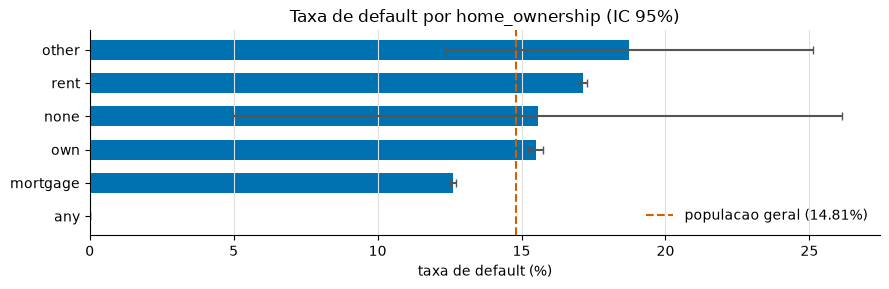

In [59]:
def plot_default_rate_with_ci(col, title):
    grp = pop_df.groupby(col, dropna=False)['target'].agg(contagem='count', taxa_default='mean')
    p = grp['taxa_default']
    n = grp['contagem']
    se = np.sqrt(p * (1 - p) / n)
    grp['ic95_inferior'] = (p - 1.96 * se).clip(lower=0)
    grp['ic95_superior'] = (p + 1.96 * se).clip(upper=1)
    grp = grp.sort_values('taxa_default', ascending=True)

    yerr_lower = (grp['taxa_default'] - grp['ic95_inferior']) * 100
    yerr_upper = (grp['ic95_superior'] - grp['taxa_default']) * 100

    labels = [str(v) for v in grp.index]

    fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(grp))))
    ax.barh(labels, grp['taxa_default'] * 100, xerr=[yerr_lower, yerr_upper],
            color='#0072B2', ecolor='#555555', capsize=3, height=0.6)
    ax.axvline(pop_df['target'].mean() * 100, color='#D55E00', linestyle='--', linewidth=1.5,
               label='populacao geral (14.81%)')
    ax.set_xlabel('taxa de default (%)')
    ax.set_title(title)
    ax.legend(frameon=False, loc='lower right')
    ax.grid(axis='x', color='#e0e0e0', linewidth=0.8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_default_rate_with_ci('home_ownership', 'Taxa de default por home_ownership (IC 95%)')


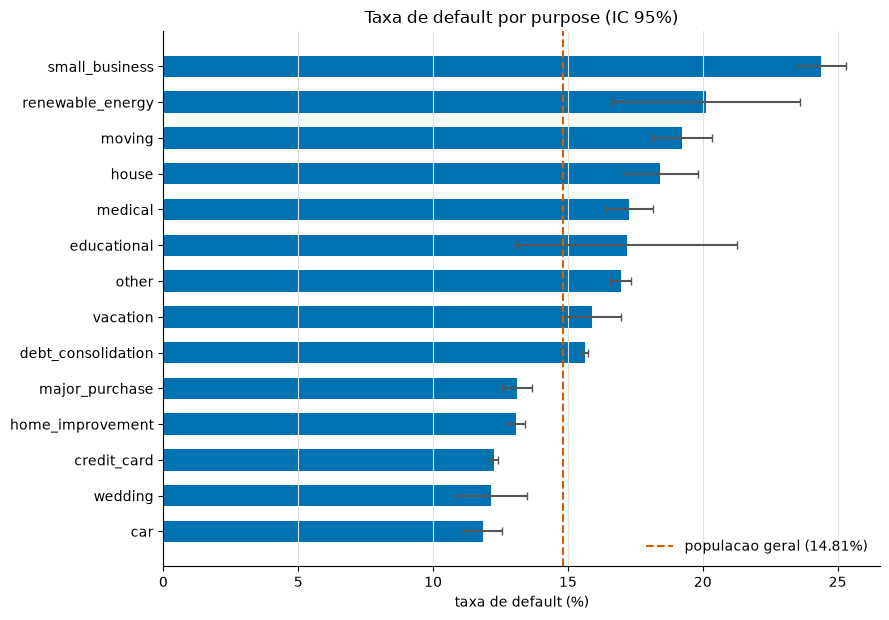

In [60]:
plot_default_rate_with_ci('purpose', 'Taxa de default por purpose (IC 95%)')
